In [ ]:
# Import necessary libraries

%pip install pandas scikit-learn matplotlib seaborn
%pip install openpyxl
%pip install --upgrade pip
%pip install plotly ipywidgets pandas
%pip install streamlit plotly pandas
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
%pip install openpyxl
%pip install plotly
%pip install ipywidgets
%pip install dash
%pip install dash-bootstrap-components
%pip install dash-core-components
%pip install dash-html-components
%pip install dash-renderer
%pip install dash-table
%pip install scipy pykrige
%pip install python-pptx pandas matplotlib seaborn openpyxl
%pip install pymc arviz
%pip install python-pptx

import pymc as pm
import arviz as az
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px
import ipywidgets as widgets
import dash_bootstrap_components as dbc
import dash


from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from scipy.spatial import distance
from pykrige.ok import OrdinaryKriging
from pykrige.ok import OrdinaryKriging
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from dash import dcc
from dash import html
from ipywidgets import HBox, Output, interactive_output
from IPython.display import display
from IPython.display import HTML
from ipywidgets import HBox, VBox, Output
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, BayesianRidge
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.text import PP_ALIGN
from pptx.dml.color import RGBColor

warnings.filterwarnings('ignore')
# Set random seed for reproducibility
RANDOM_SEED = 42
# Set the style of seaborn
sns.set(style="whitegrid")
# Set the figure size for all plots
plt.figure(figsize=(10, 6))
# Set the default color palette for seaborn
sns.set_palette("deep")
# Set the default font size for all plots
plt.rcParams['font.size'] = 12
# Set the default figure size for all plots
plt.rcParams['figure.figsize'] = (10, 6)
# Set the default figure dpi for all plots
plt.rcParams['figure.dpi'] = 100
# Set the default figure face color for all plots
plt.rcParams['figure.facecolor'] = 'white'

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


Note: you may need to restart the kernel to use updated packages.


In [ ]:
# --------- Dados estruturados para os 19 subníveis ---------
dados = {
    "Subniveis": ["8E", "8D", "8C", "8B", "8A", "7B", "7A", "6B", "6A", "5A",
                  "4B", "4A", "3A", "2B", "2A", "1D", "1C", "1B", "1A"],
    "Espessura": [3.5, 5.5, 5.5, 3.0, 4.5, 4.5, 6.5, 7.5, 8.0, 8.0,
                  7.0, 5.5, 6.5, 6.5, 5.5, 6.0, 4.0, 1.5, 2.5],
    "N. AMOSTRAS": [7, 9, 8, 17, 20, 3, 13, 15, 4, 11,
                    52, 25, 14, 25, 8, 14, 7, 10, 8],
    "MOA-NF": [29, 27, 62, 54, 70, 64, 71, 78, 74, 62,
               75, 89, 84, 89, 79, 72, 71, 68, 69],
    "OP-AL": [4, 10, 3, 7, 3, 1, 2, 4, 3, 4,
              2, 1, 0, 1, 0, 1, 2, 2, 3],
    "OP-EQUI": [2, 3, 1, 4, 1, 0, 0, 1, 0, 0,
                0, 0, 0, 0, 0, 0, 0, 1, 0],
    "2010": [6, 12, 12, 5, 9, 92, 30, 15, 18, 51,
             125, 75, 57, 44, 20, 20, 6, 0, 0],
    "2010.1": [10, 25, 25, 8, 18, 100, 71, 50, 54, 166,
               150, 91, 113, 52, 40, 64, 45, 10, 0],
    "Fe2O3": [None, None, None, None, None, None, 7.06, None, 6.66, 6.41,
              None, 5.23, 7.41, 5.99, 6.89, 5.78, 5.25, 5.52, 4.94],
    "U/Th": [None, None, None, None, None, None, 2.06, None, 1.98, 1.82,
             None, 1.81, 1.66, 1.35, 1.28, 1.11, 1.17, 1.51, 1.48],
    "Al2O3": [None, None, None, None, None, None, 14.13, None, 14.31, 13.69,
              None, 14.10, 13.62, 15.01, 14.65, 13.95, 14.89, 13.38, 13.12],
    "TiO2": [None, None, None, None, None, None, 0.57, None, 0.55, 0.59,
             None, 0.61, 0.60, 0.61, 0.61, 0.62, 0.64, 0.61, 0.63],
    "MOA": [None, None, None, None, None, None, 327, None, 286, 248,
            None, 258, 289, 286, 338, 321, 266, 251, 190],
    "TS": [None, None, None, None, None, None, 1.49, None, 1.96, 2.73,
           None, 4.54, 1.71, 1.24, 1.72, 3.98, 3.67, 1.73, 2.62],
    "TOC": [None, None, None, None, None, None, 11.93, None, 12.11, 11.70,
            None, 12.01, 13.05, 8.79, 7.69, 5.73, 7.42, 12.41, 12.97],
    "TN": [None, None, None, None, None, None, 0.43, None, 0.46, 0.44,
           None, 0.43, 0.54, 0.32, 0.29, 0.18, 0.26, 0.52, 0.54]
}
# Create a DataFrame from the dictionary
df = pd.DataFrame(dados)
# Display the first few rows of the DataFrame
df.head()
# Display the DataFrame information
df.info()
# Display the DataFrame statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Subniveis    19 non-null     object 
 1   Espessura    19 non-null     float64
 2   N. AMOSTRAS  19 non-null     int64  
 3   MOA-NF       19 non-null     int64  
 4   OP-AL        19 non-null     int64  
 5   OP-EQUI      19 non-null     int64  
 6   2010         19 non-null     int64  
 7   2010.1       19 non-null     int64  
 8   Fe2O3        11 non-null     float64
 9   U/Th         11 non-null     float64
 10  Al2O3        11 non-null     float64
 11  TiO2         11 non-null     float64
 12  MOA          11 non-null     float64
 13  TS           11 non-null     float64
 14  TOC          11 non-null     float64
 15  TN           11 non-null     float64
dtypes: float64(9), int64(6), object(1)
memory usage: 2.5+ KB


,Espessura,N. AMOSTRAS,MOA-NF,OP-AL,OP-EQUI,2010,2010.1,Fe2O3,U/Th,Al2O3,TiO2,MOA,TS,TOC,TN
count,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000
mean,5.342105,14.210526,67.736842,2.789474,0.684211,31.421053,57.473684,6.103636,1.566364,14.077273,0.603636,278.181818,2.490000,10.528182,0.400909
std,1.841291,11.078402,16.612720,2.417045,1.157230,34.525861,47.763734,0.833502,0.324354,0.607768,0.025796,42.444831,1.118562,2.601141,0.121281
min,1.500000,3.000000,27.000000,0.000000,0.000000,0.000000,0.000000,4.940000,1.110000,13.120000,0.550000,190.000000,1.240000,5.730000,0.180000
25%,4.250000,8.000000,63.000000,1.000000,0.000000,7.500000,21.500000,5.385000,1.315000,13.655000,0.595000,254.500000,1.715000,8.240000,0.305000
50%,5.500000,11.000000,71.000000,2.000000,0.000000,18.000000,50.000000,5.990000,1.510000,14.100000,0.610000,286.000000,1.960000,11.930000,0.430000
75%,6.500000,16.000000,76.500000,3.500000,1.000000,47.500000,81.000000,6.775000,1.815000,14.480000,0.615000,305.000000,3.200000,12.260000,0.490000
max,8.000000,52.000000,89.000000,10.000000,4.000000,125.000000,166.000000,7.410000,2.060000,15.010000,0.640000,338.000000,4.540000,13.050000,0.540000


<Figure size 1000x600 with 0 Axes>

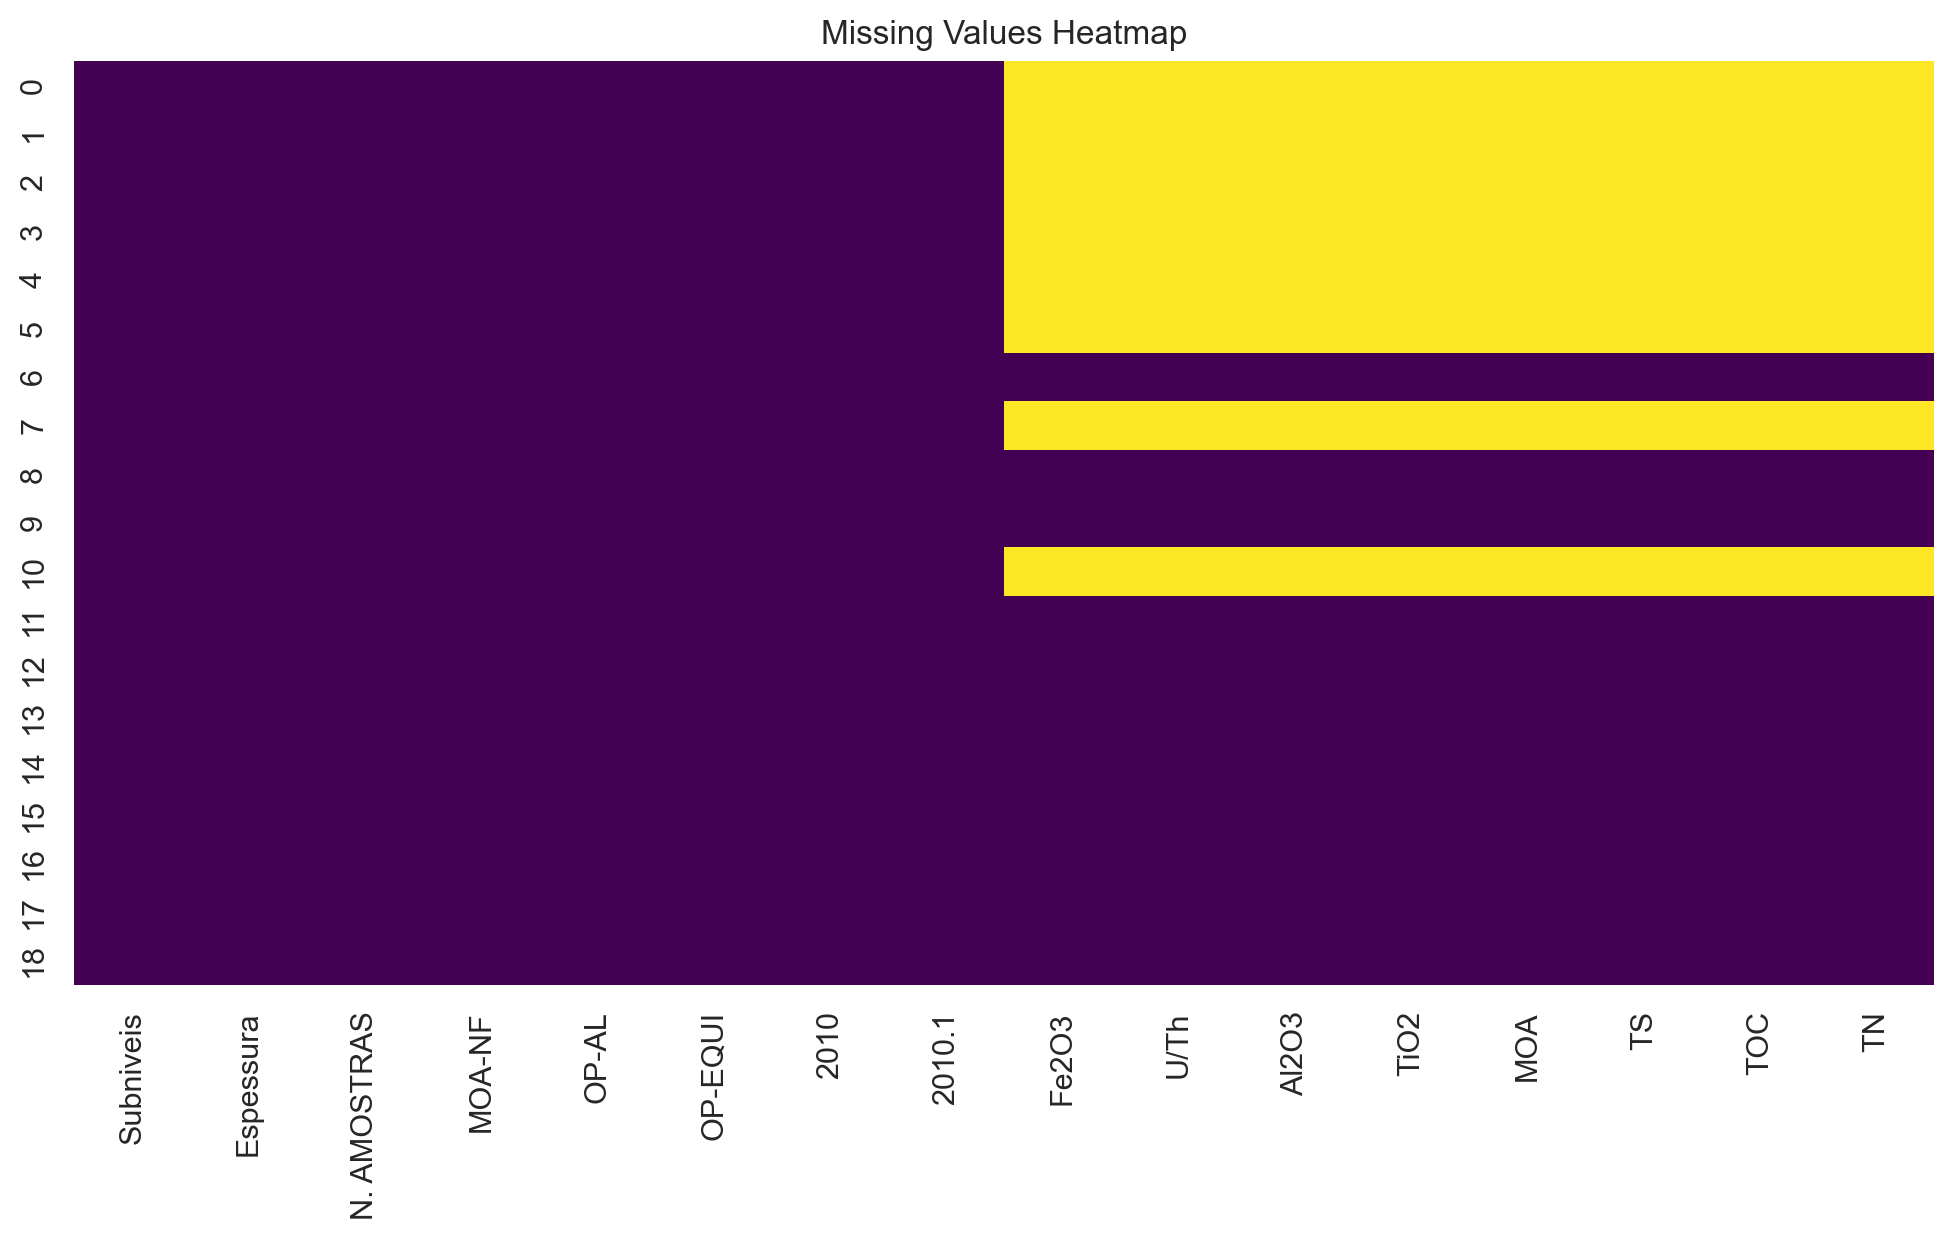

In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
# Display the missing values
missing_values[missing_values > 0]
# Visualize the missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [ ]:
# 2. Separar parte vermelha (treinamento) e azul (predição)
dados_completos = df.dropna(subset=["Fe2O3", "U/Th", "Al2O3", "TiO2", "MOA", "TS", "TOC", "TN"])
dados_faltantes = df[df[["Fe2O3", "U/Th", "Al2O3", "TiO2", "MOA", "TS", "TOC", "TN"]].isnull().any(axis=1)]

# 3. Selecionar colunas preditoras (X) e alvos (y)
colunas_X = ["Espessura", "N. AMOSTRAS", "MOA-NF", "OP-AL", "OP-EQUI", "2010", "2010.1"]
colunas_y = ["Fe2O3", "U/Th", "Al2O3", "TiO2", "MOA", "TS", "TOC", "TN"]

X_train = dados_completos[colunas_X]
y_train = dados_completos[colunas_y]

X_pred = dados_faltantes[colunas_X]

# 4. Tratar possíveis NaNs nos dados de entrada
imputer = SimpleImputer(strategy='max' if X_train.isnull().any().any() else 'constant', fill_value=0 if X_train.isnull().any().any() else None)
X_train_imputed = imputer.fit_transform(X_train)

if not X_pred.empty:
	X_pred_imputed = imputer.transform(X_pred)

	# 5. Modelo preditivo multivariado
	model = RandomForestRegressor(n_estimators=1000, random_state=RANDOM_SEED, n_jobs=-1)
	# 5.1. Padronizar os dados de treino
	scaler = StandardScaler()
	X_train_imputed = scaler.fit_transform(X_train_imputed)
	X_pred_imputed = scaler.transform(X_pred_imputed)
	# 5.2. Treinar o modelo
	model.fit(X_train_imputed, y_train)

	# 6. Prever os valores ausentes
	y_pred = model.predict(X_pred_imputed)

	# 7. Inserir valores previstos no dataframe original
	df.loc[dados_faltantes.index, colunas_y] = y_pred
	# 7.1. Criar coluna 'Fonte' marcando origem dos dados

df["Fonte"] = "Original"
df.loc[dados_faltantes.index, "Fonte"] = "Predito"

# 8. Exportar resultado final
print(df.loc[:, ["Subniveis", "Fe2O3", "U/Th", "Al2O3", "TiO2", "MOA", "TS", "TOC", "TN"]])

df.to_excel("resultado_completo_com_fonte.xlsx", index=False)

   Subniveis    Fe2O3     U/Th     Al2O3     TiO2      MOA       TS       TOC  \
0         8E  5.52473  1.44640  13.85335  0.61893  246.691  2.57538  10.83805   
1         8D  5.80069  1.53160  13.80055  0.60983  257.189  2.40277  11.08608   
2         8C  5.73301  1.47735  13.96611  0.61433  258.410  2.59612  10.51065   
3         8B  5.66826  1.52707  13.64471  0.61184  248.444  2.36564  11.44720   
4         8A  5.61347  1.45985  13.90486  0.61666  256.811  2.64500  10.58281   
5         7B  5.75831  1.56456  14.00376  0.61097  259.175  3.01296  10.69983   
6         7A  7.06000  2.06000  14.13000  0.57000  327.000  1.49000  11.93000   
7         6B  6.45290  1.66461  14.28981  0.58346  294.653  2.12944  10.36972   
8         6A  6.66000  1.98000  14.31000  0.55000  286.000  1.96000  12.11000   
9         5A  6.41000  1.82000  13.69000  0.59000  248.000  2.73000  11.70000   
10        4B  6.37647  1.69953  14.12441  0.59584  287.076  2.48203  11.18347   
11        4A  5.23000  1.810

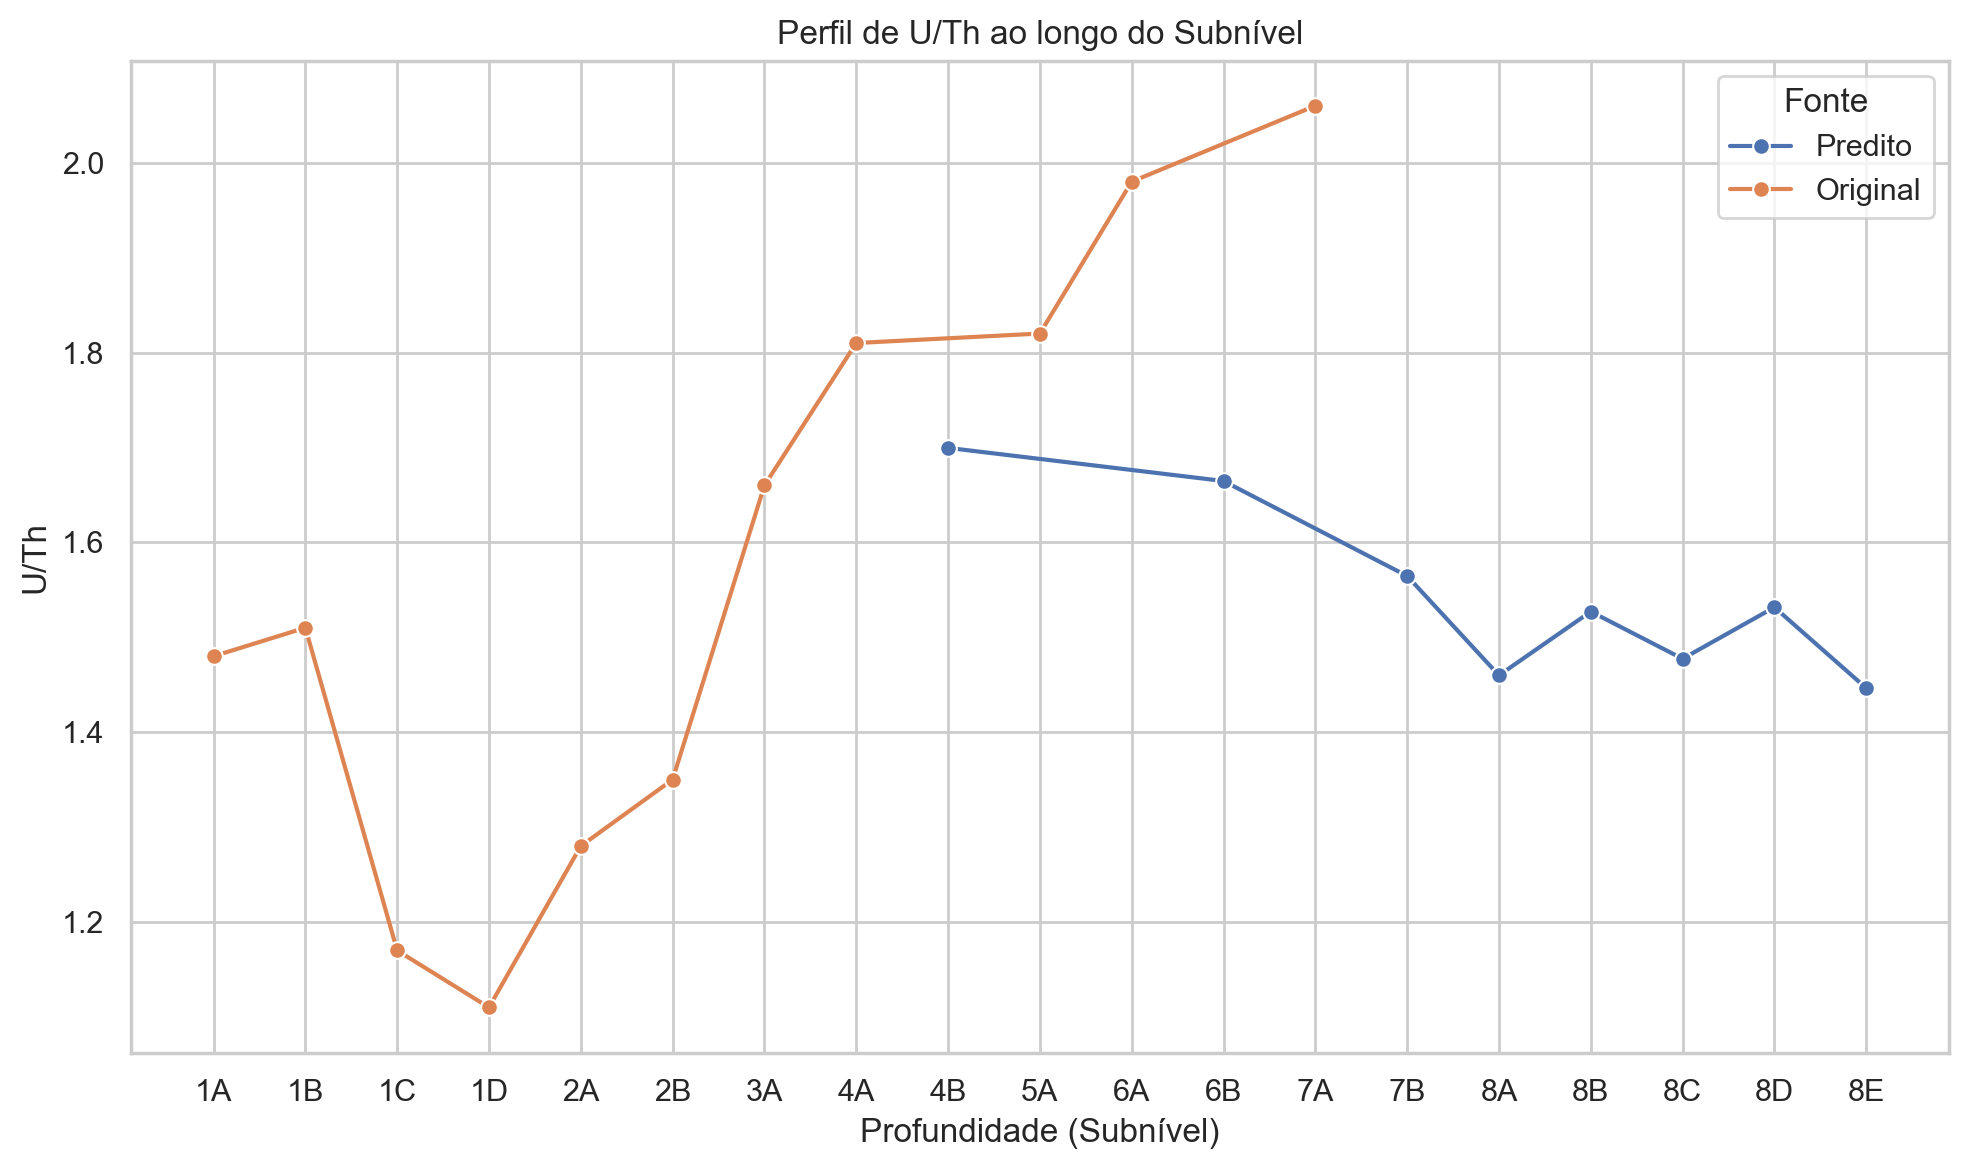

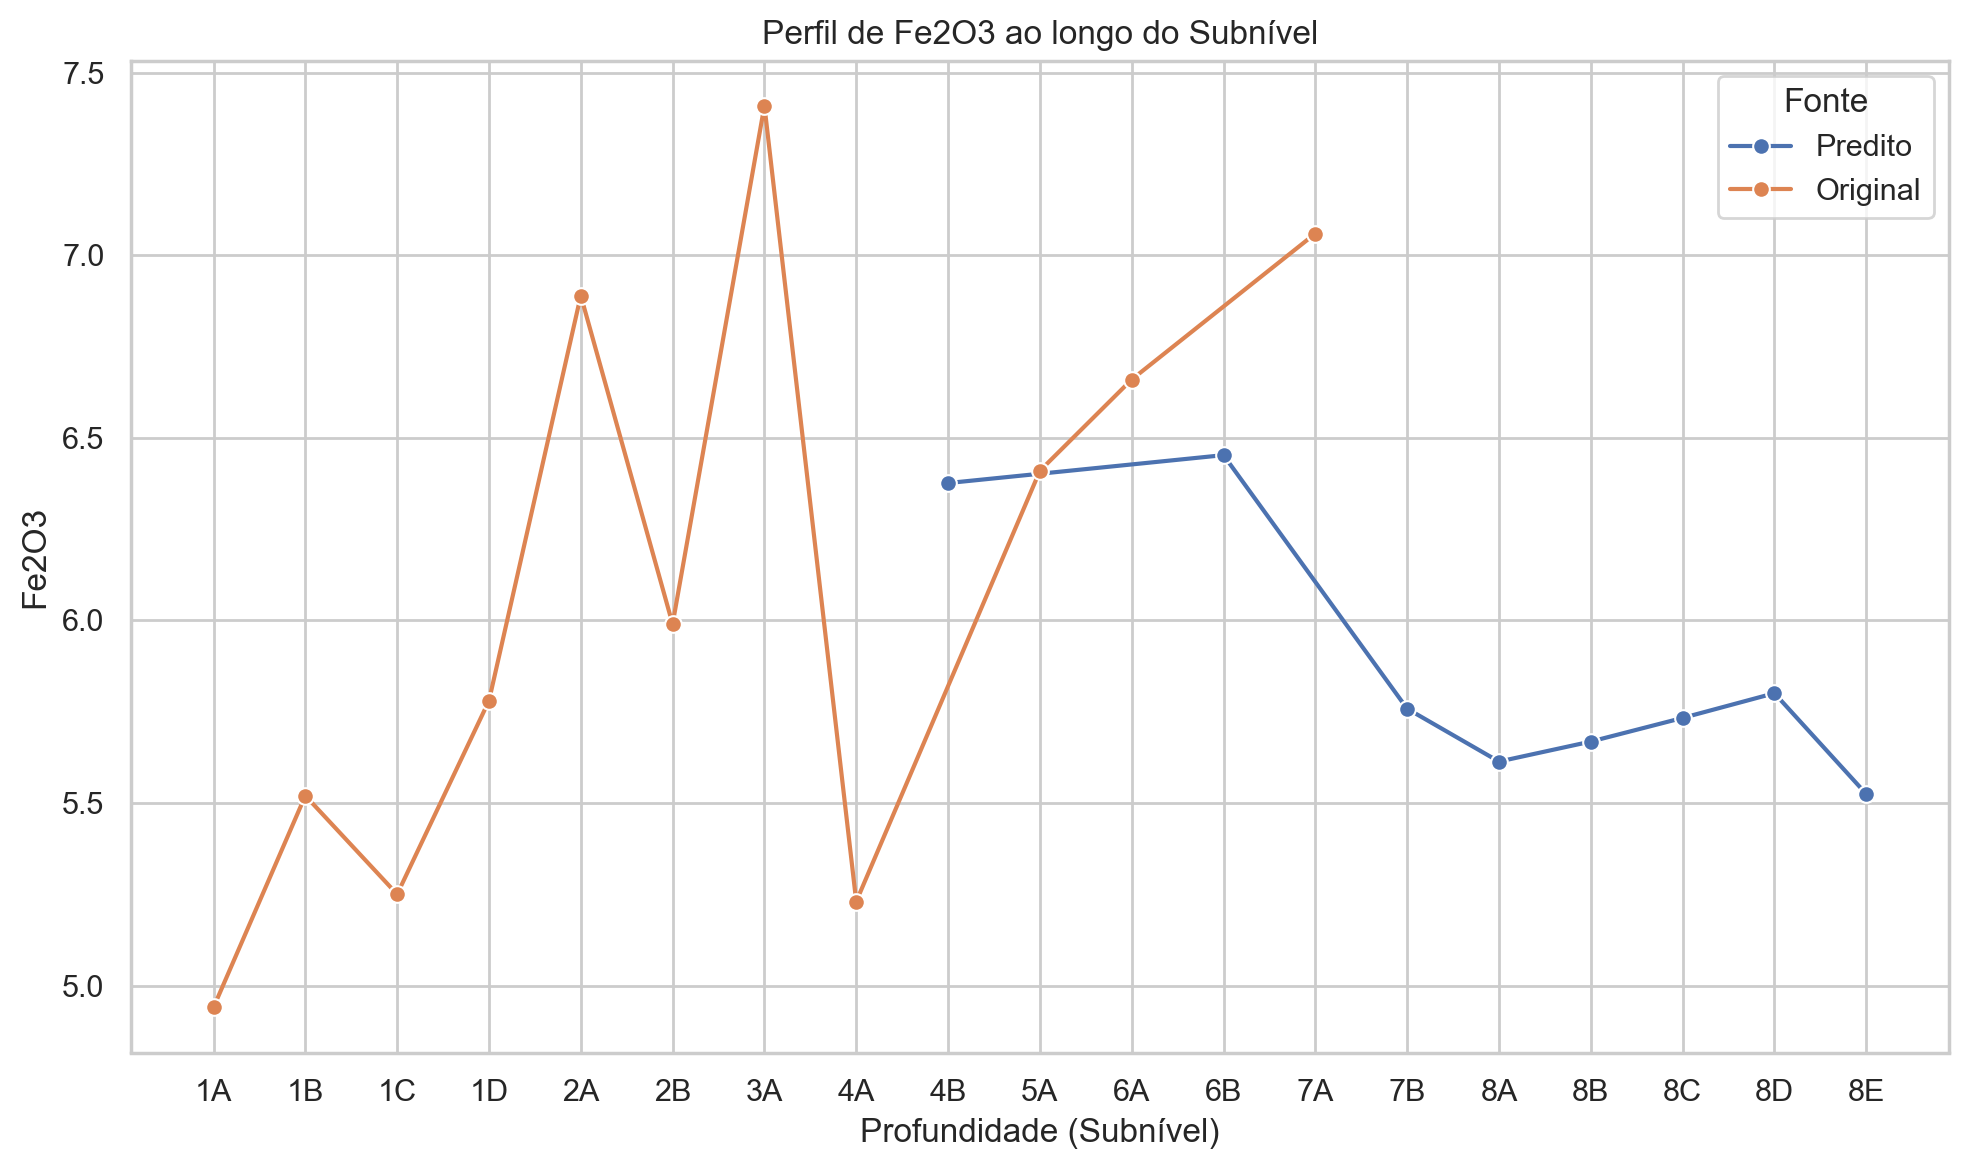

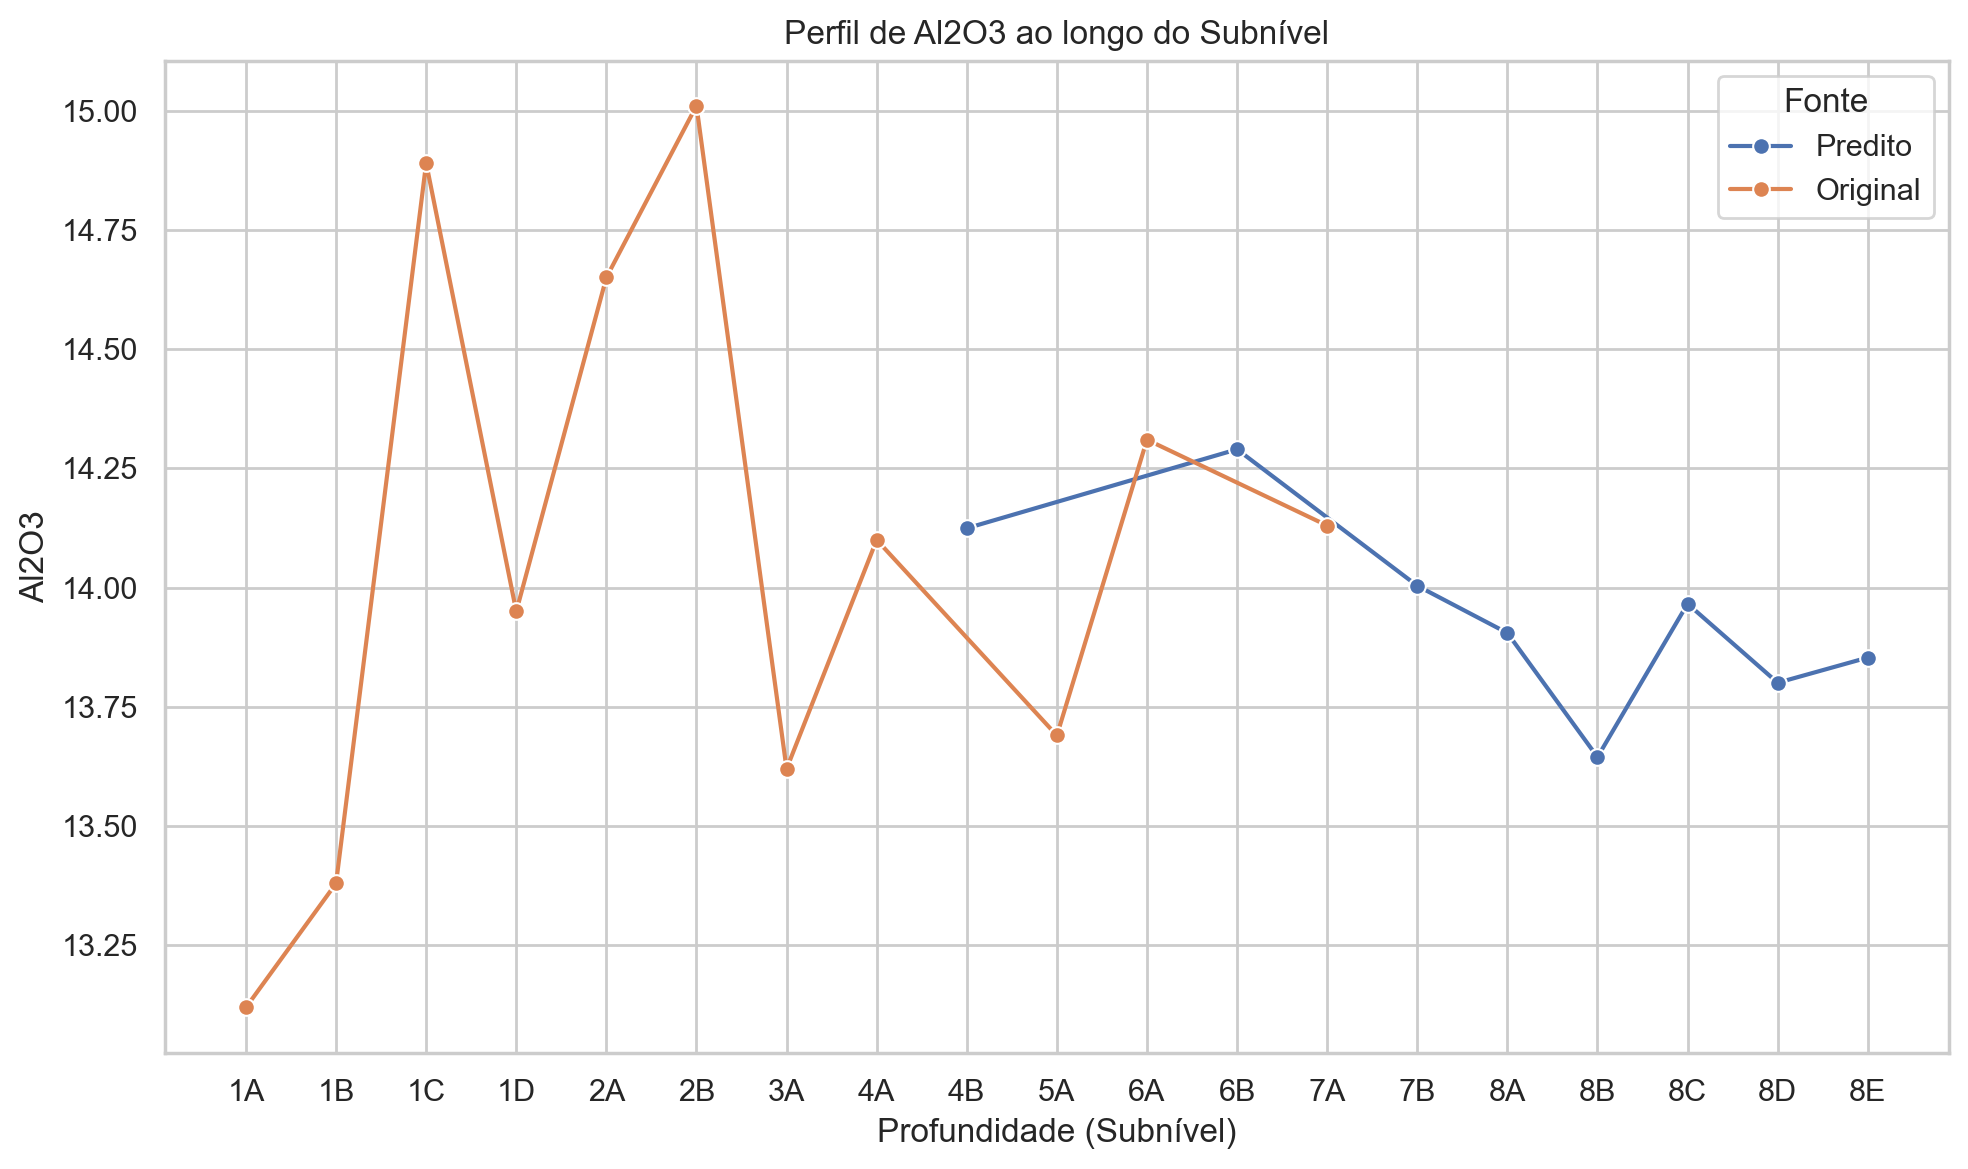

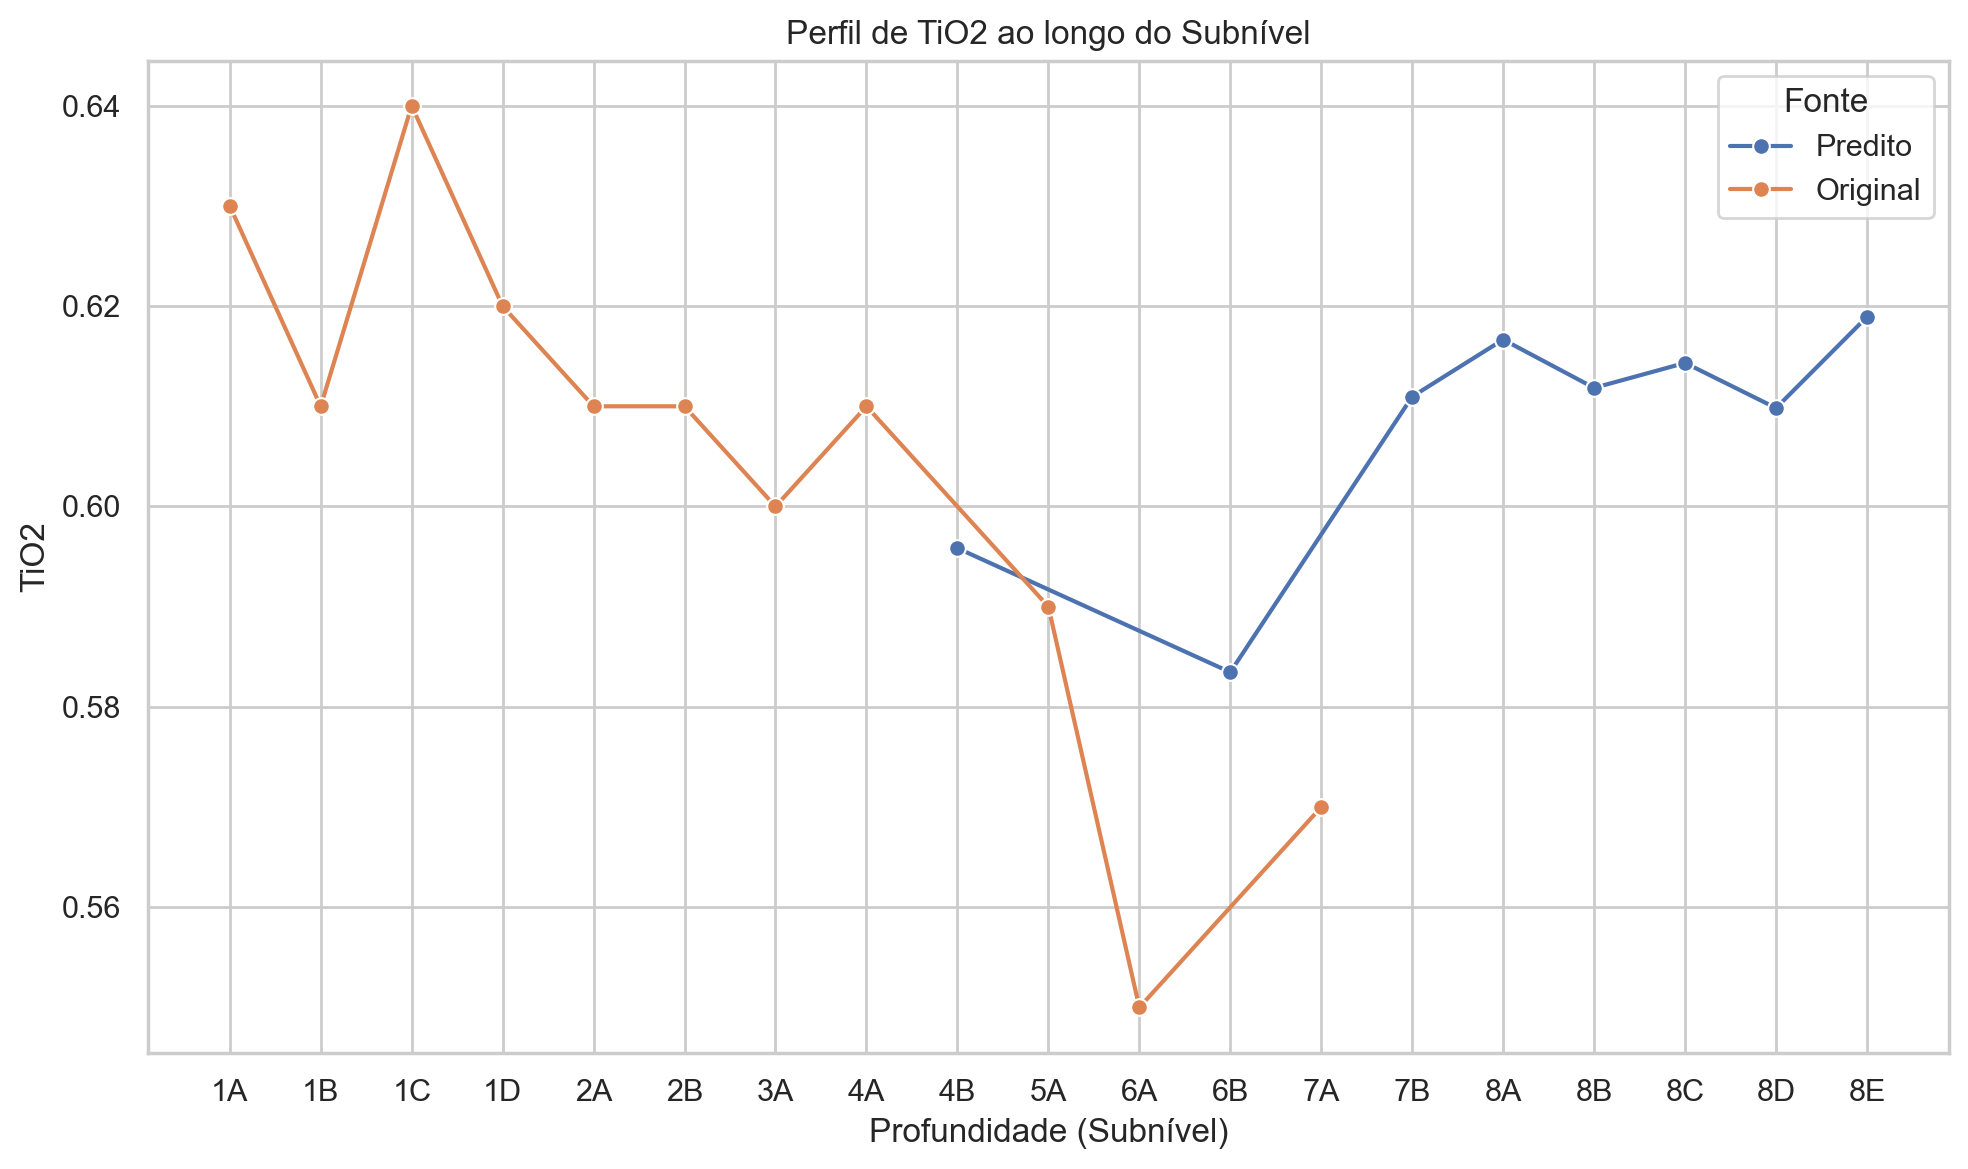

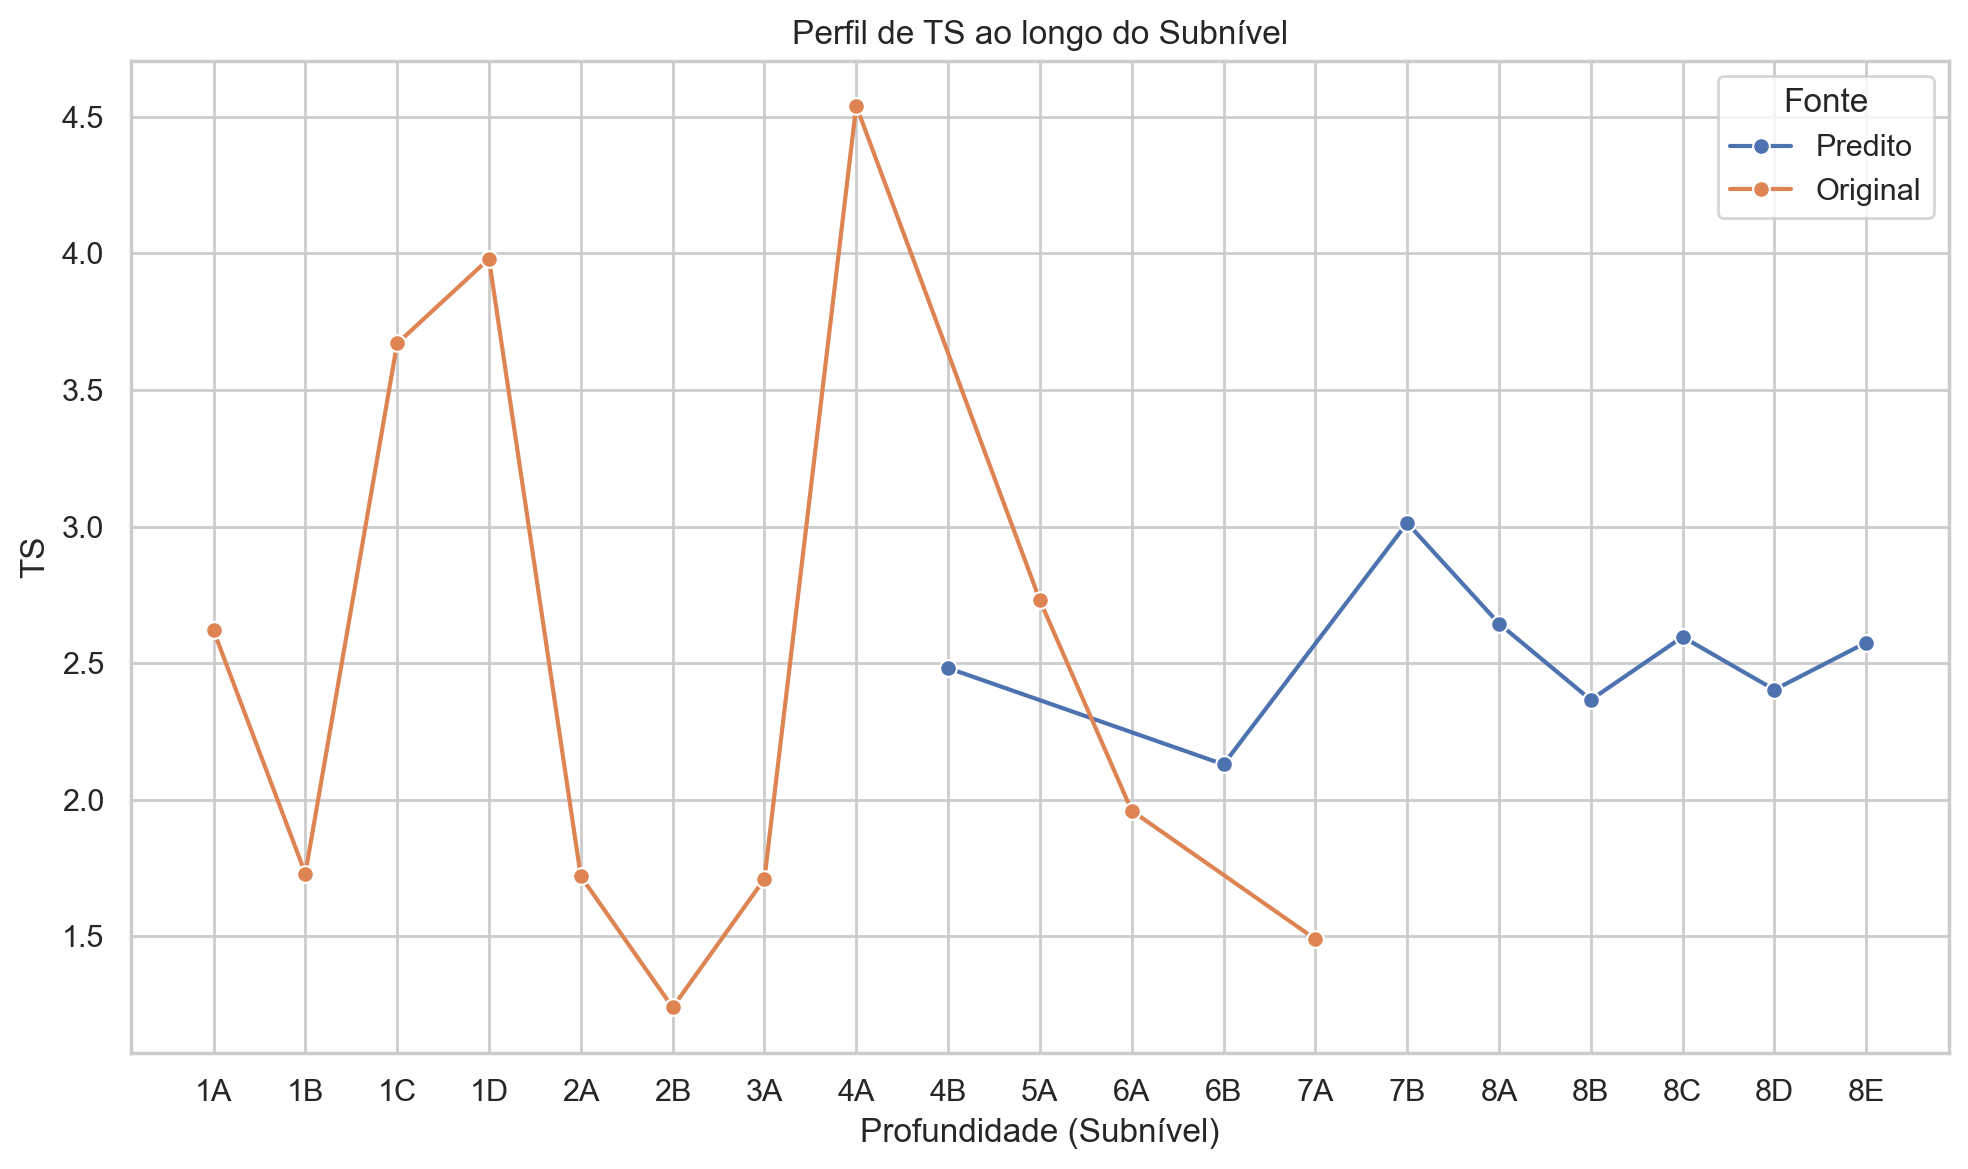

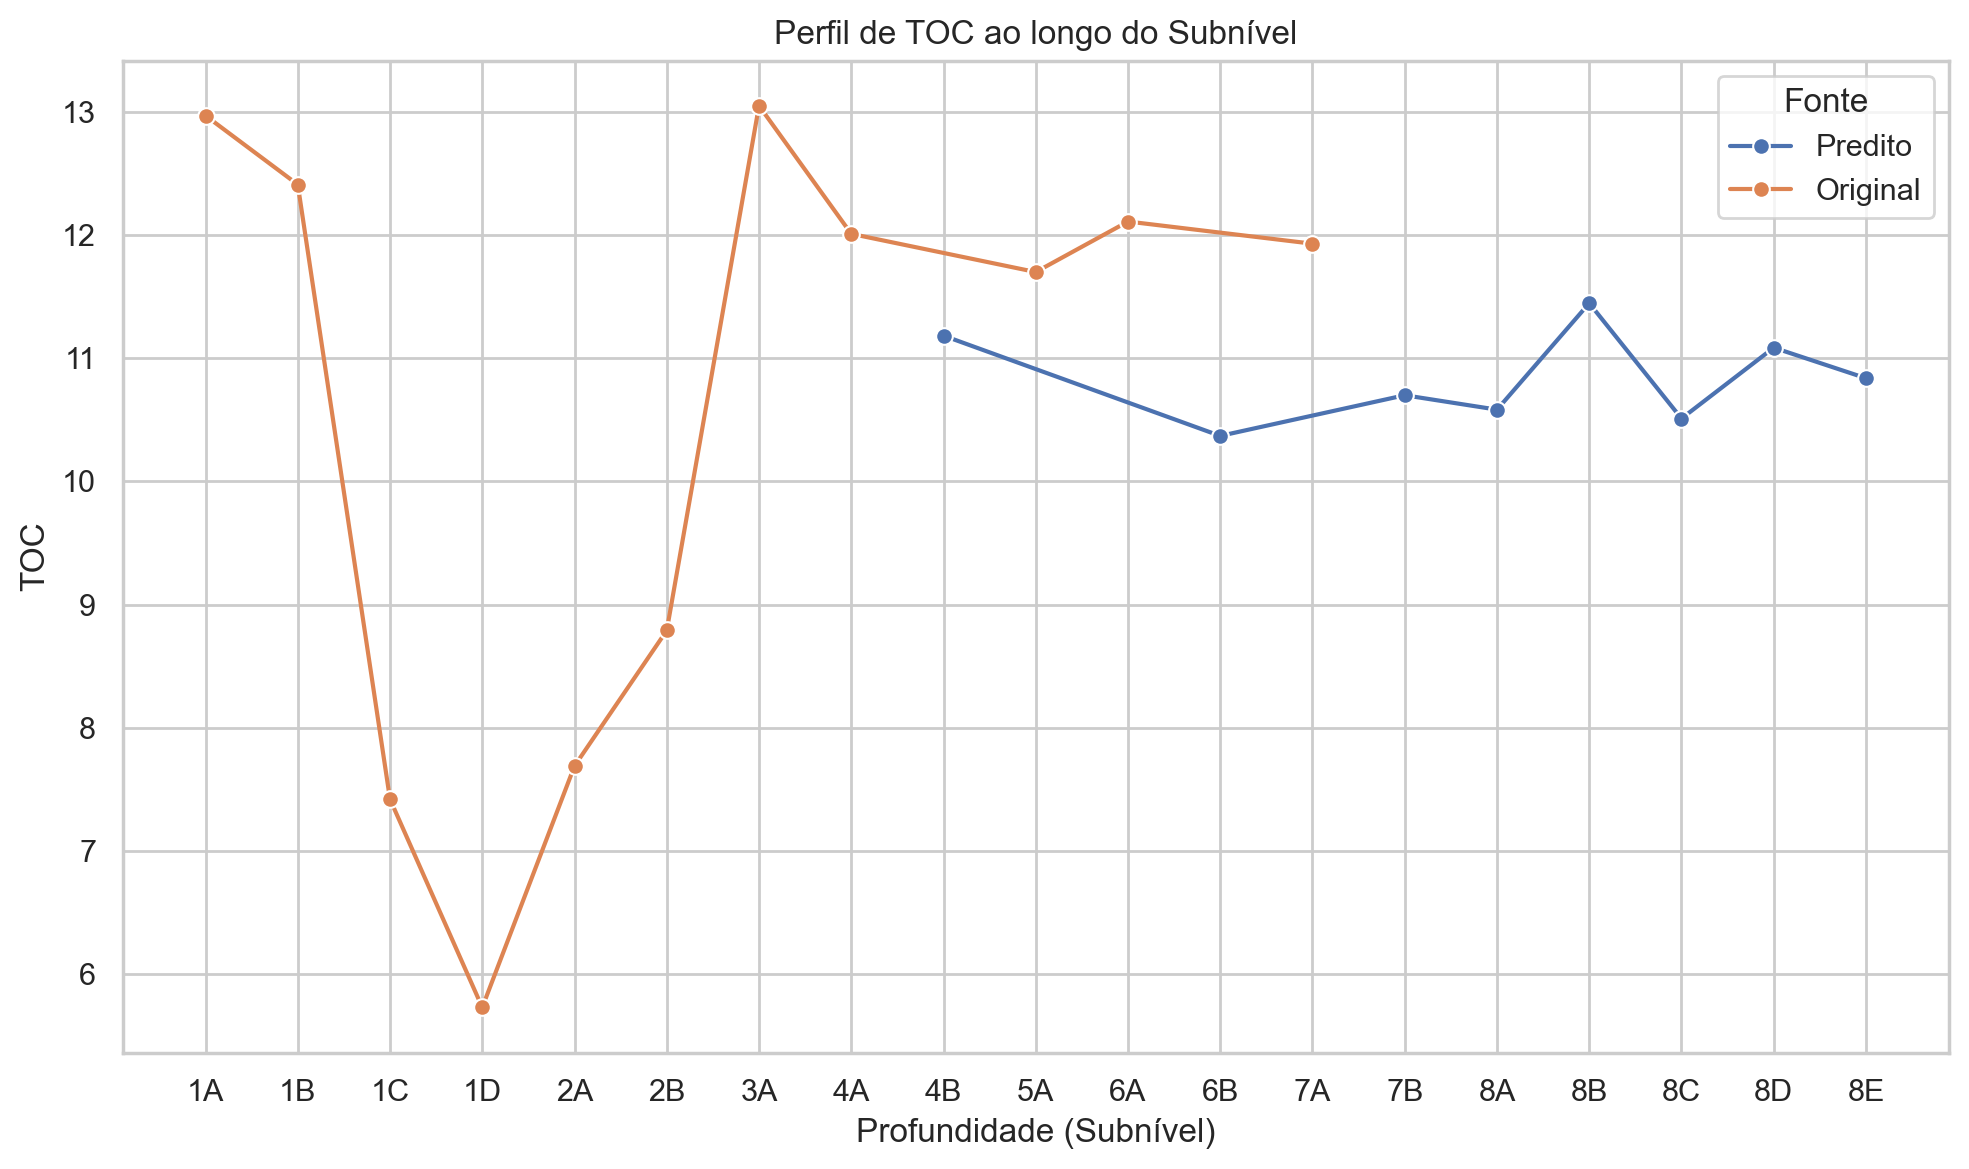

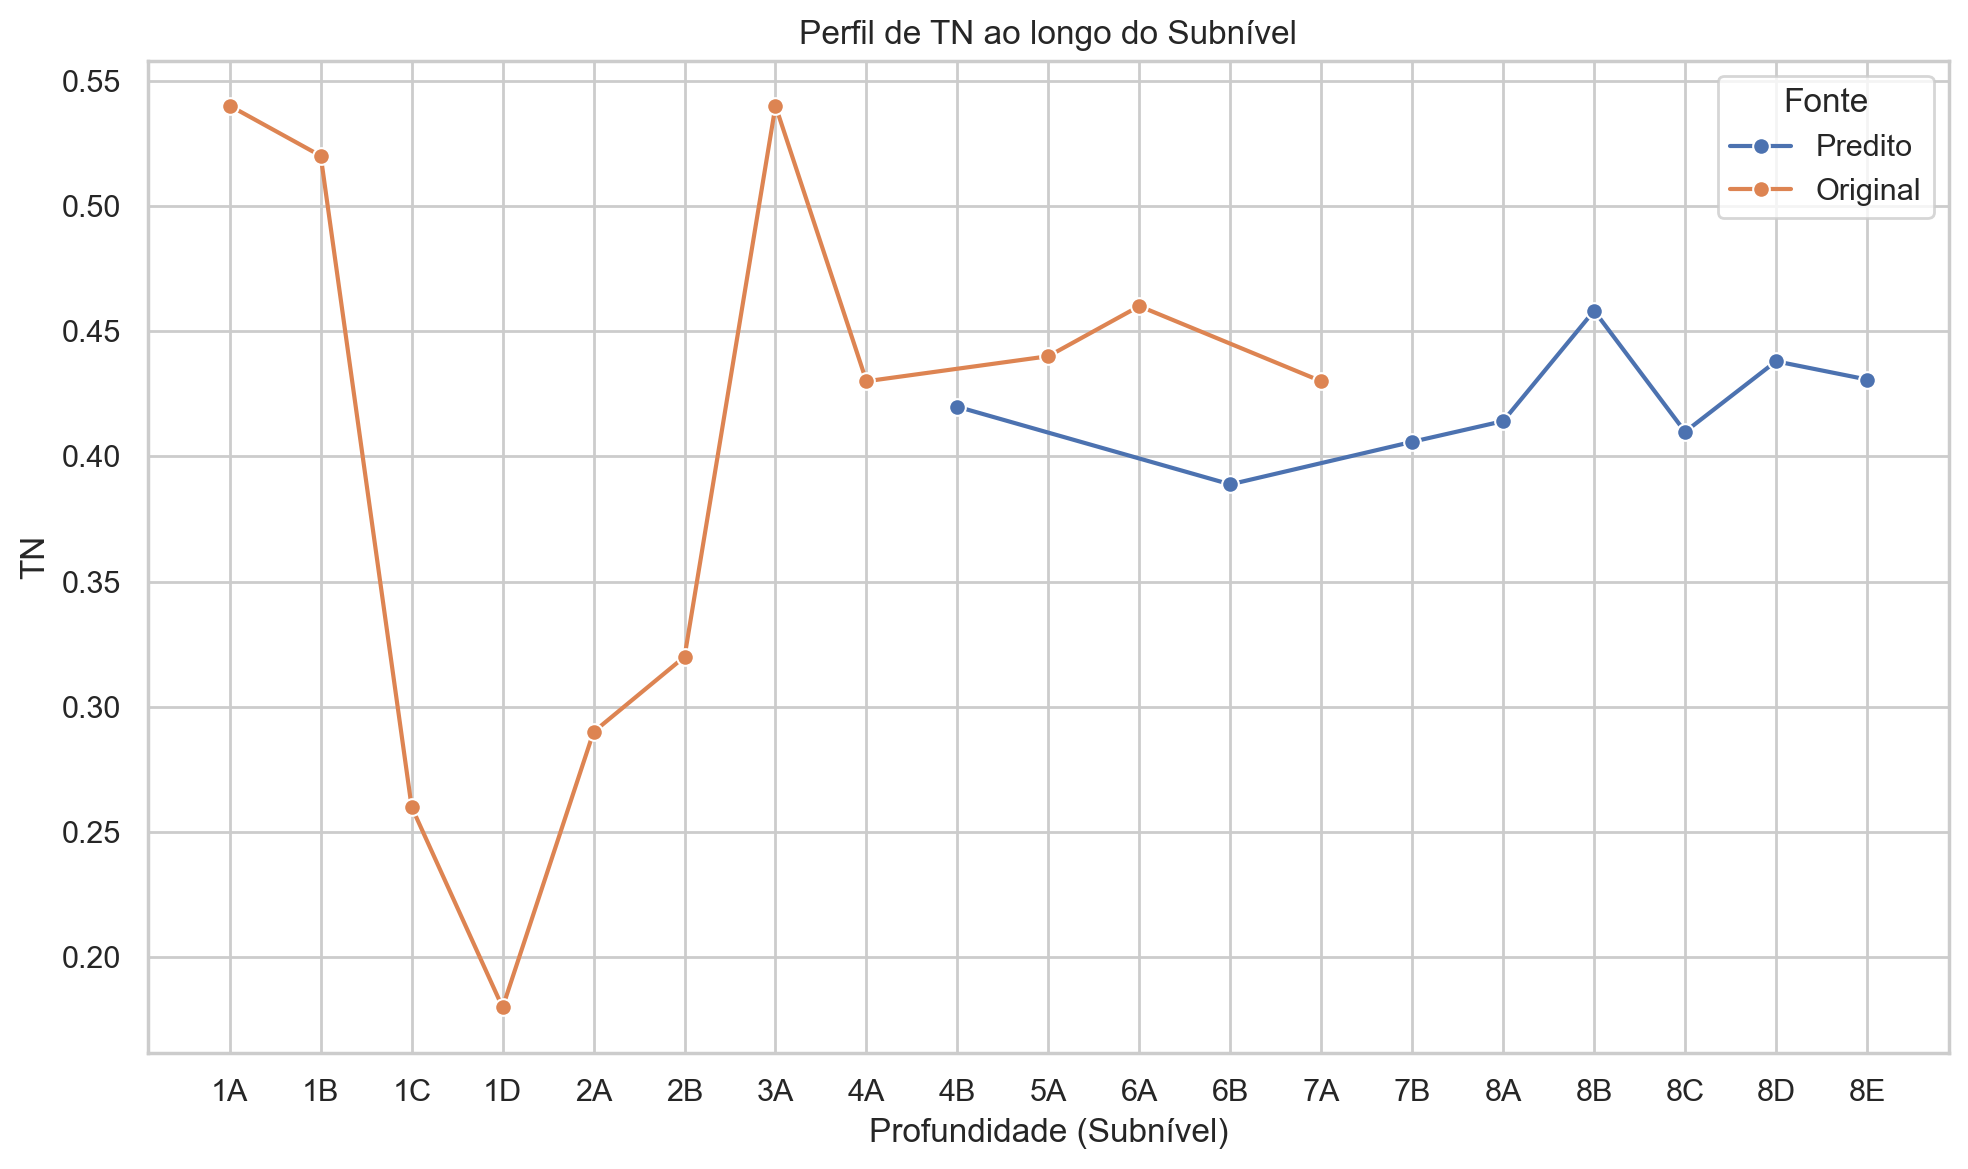

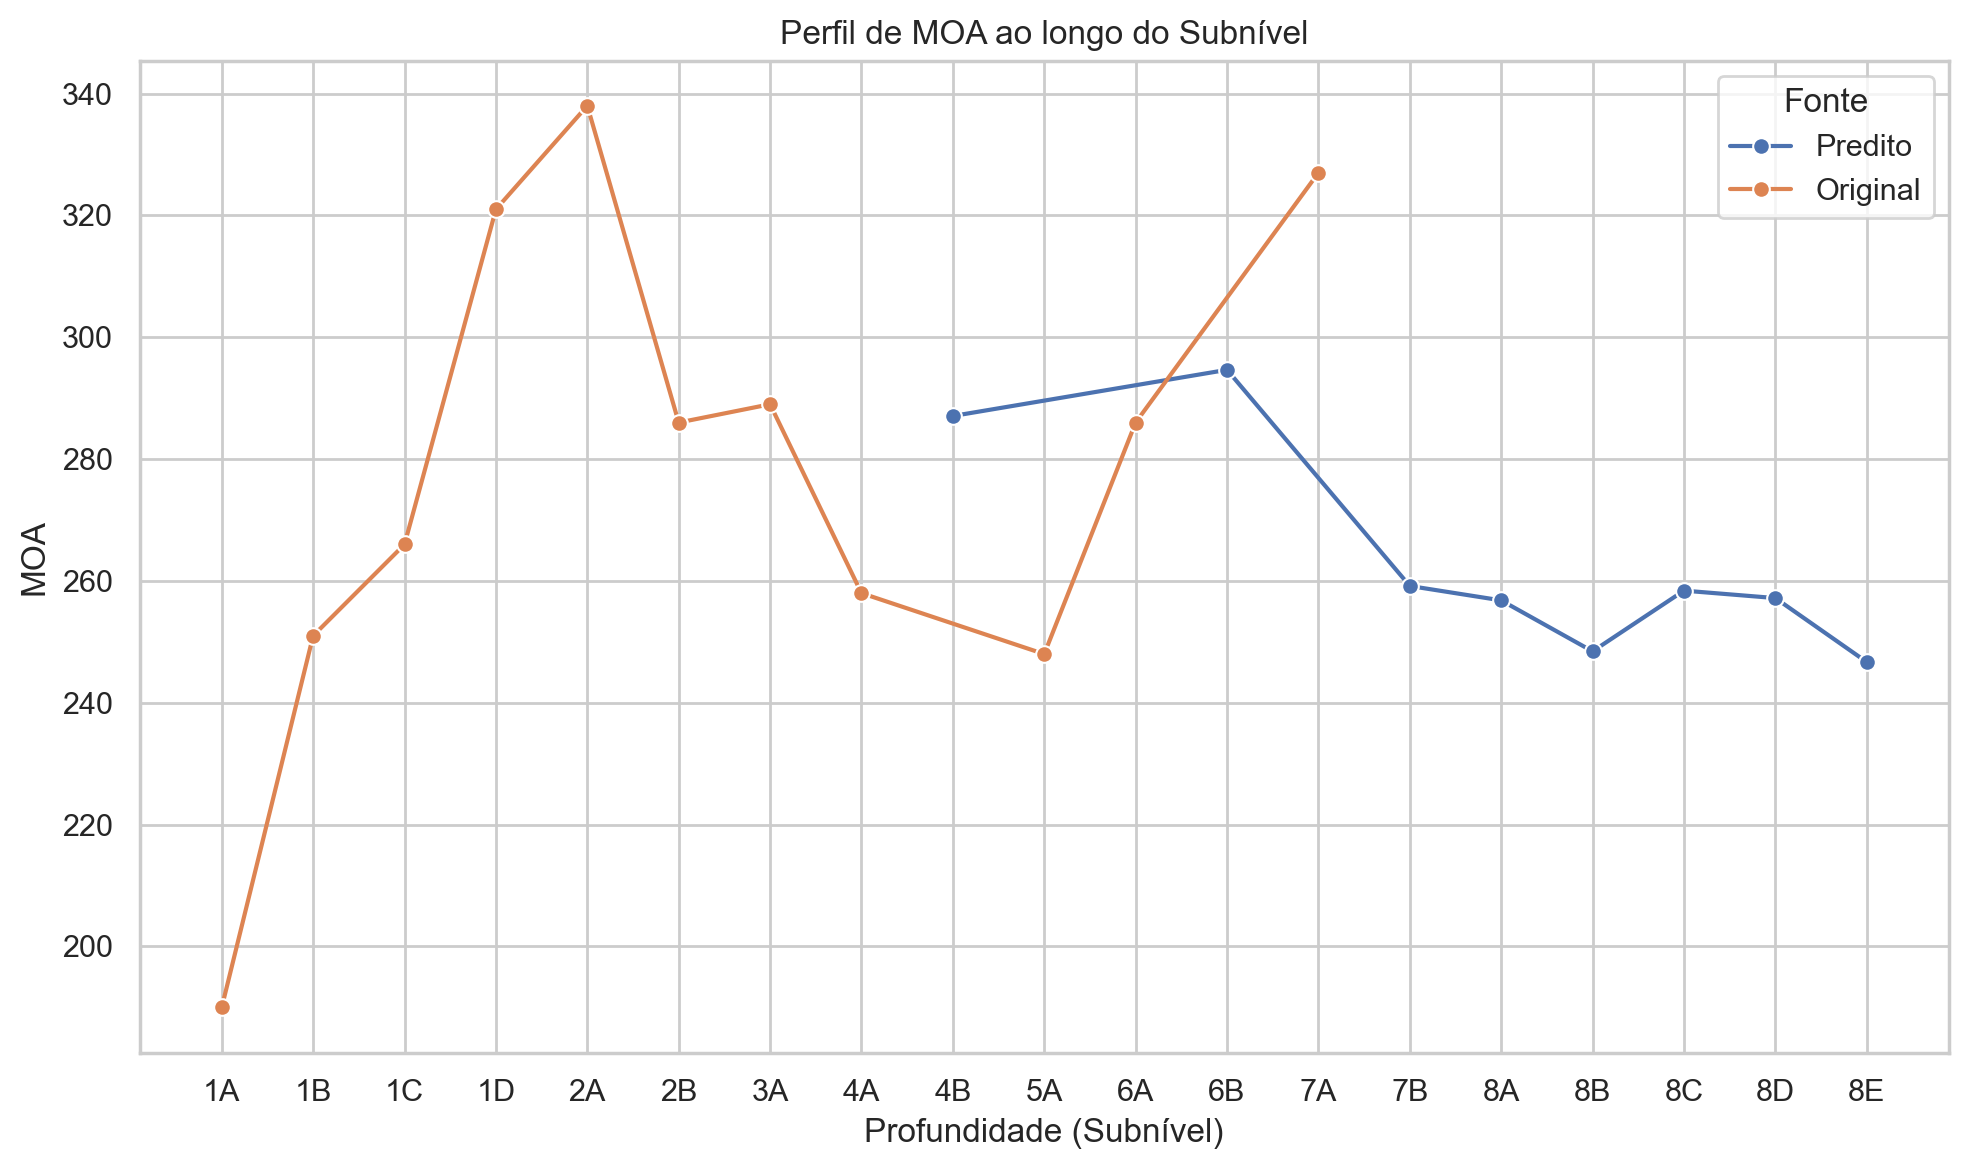

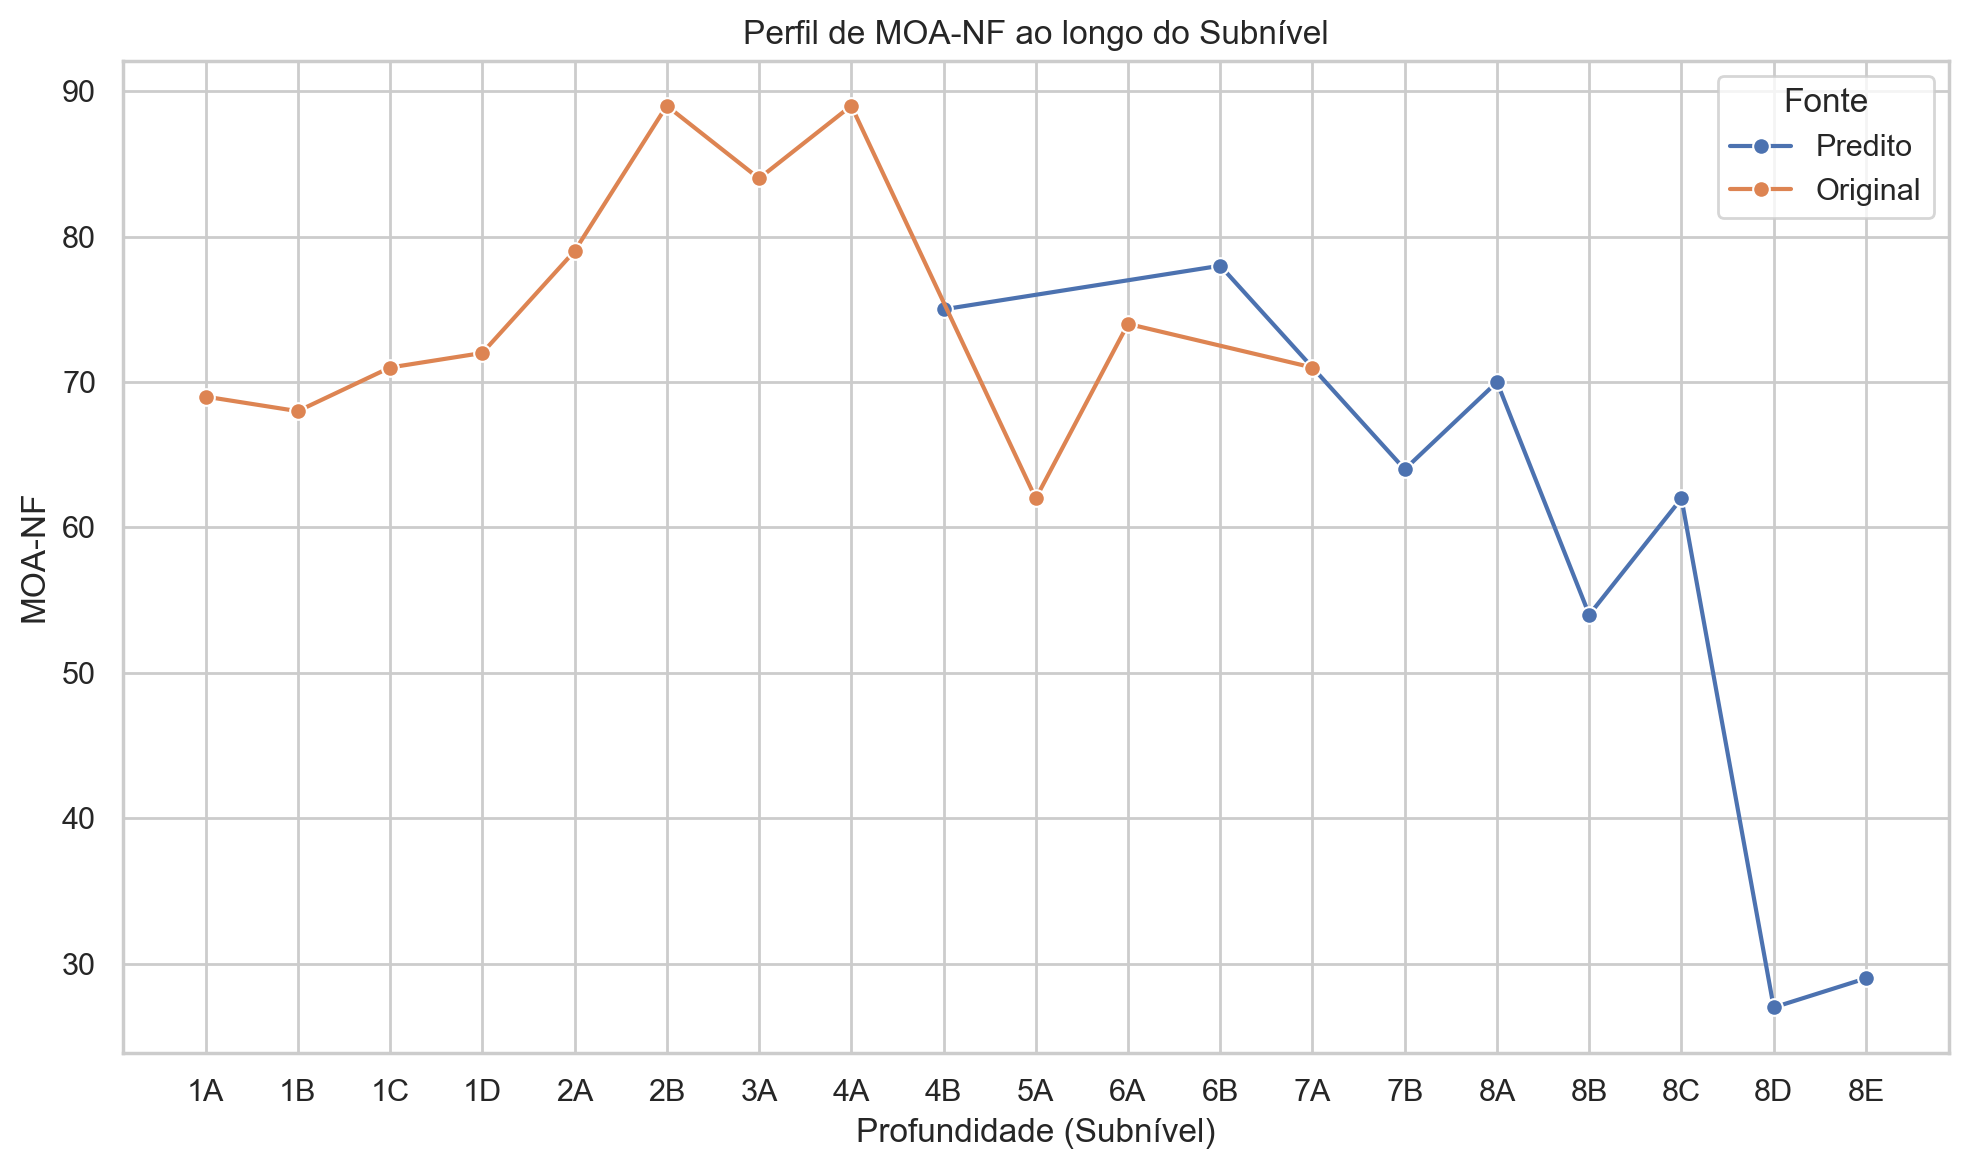

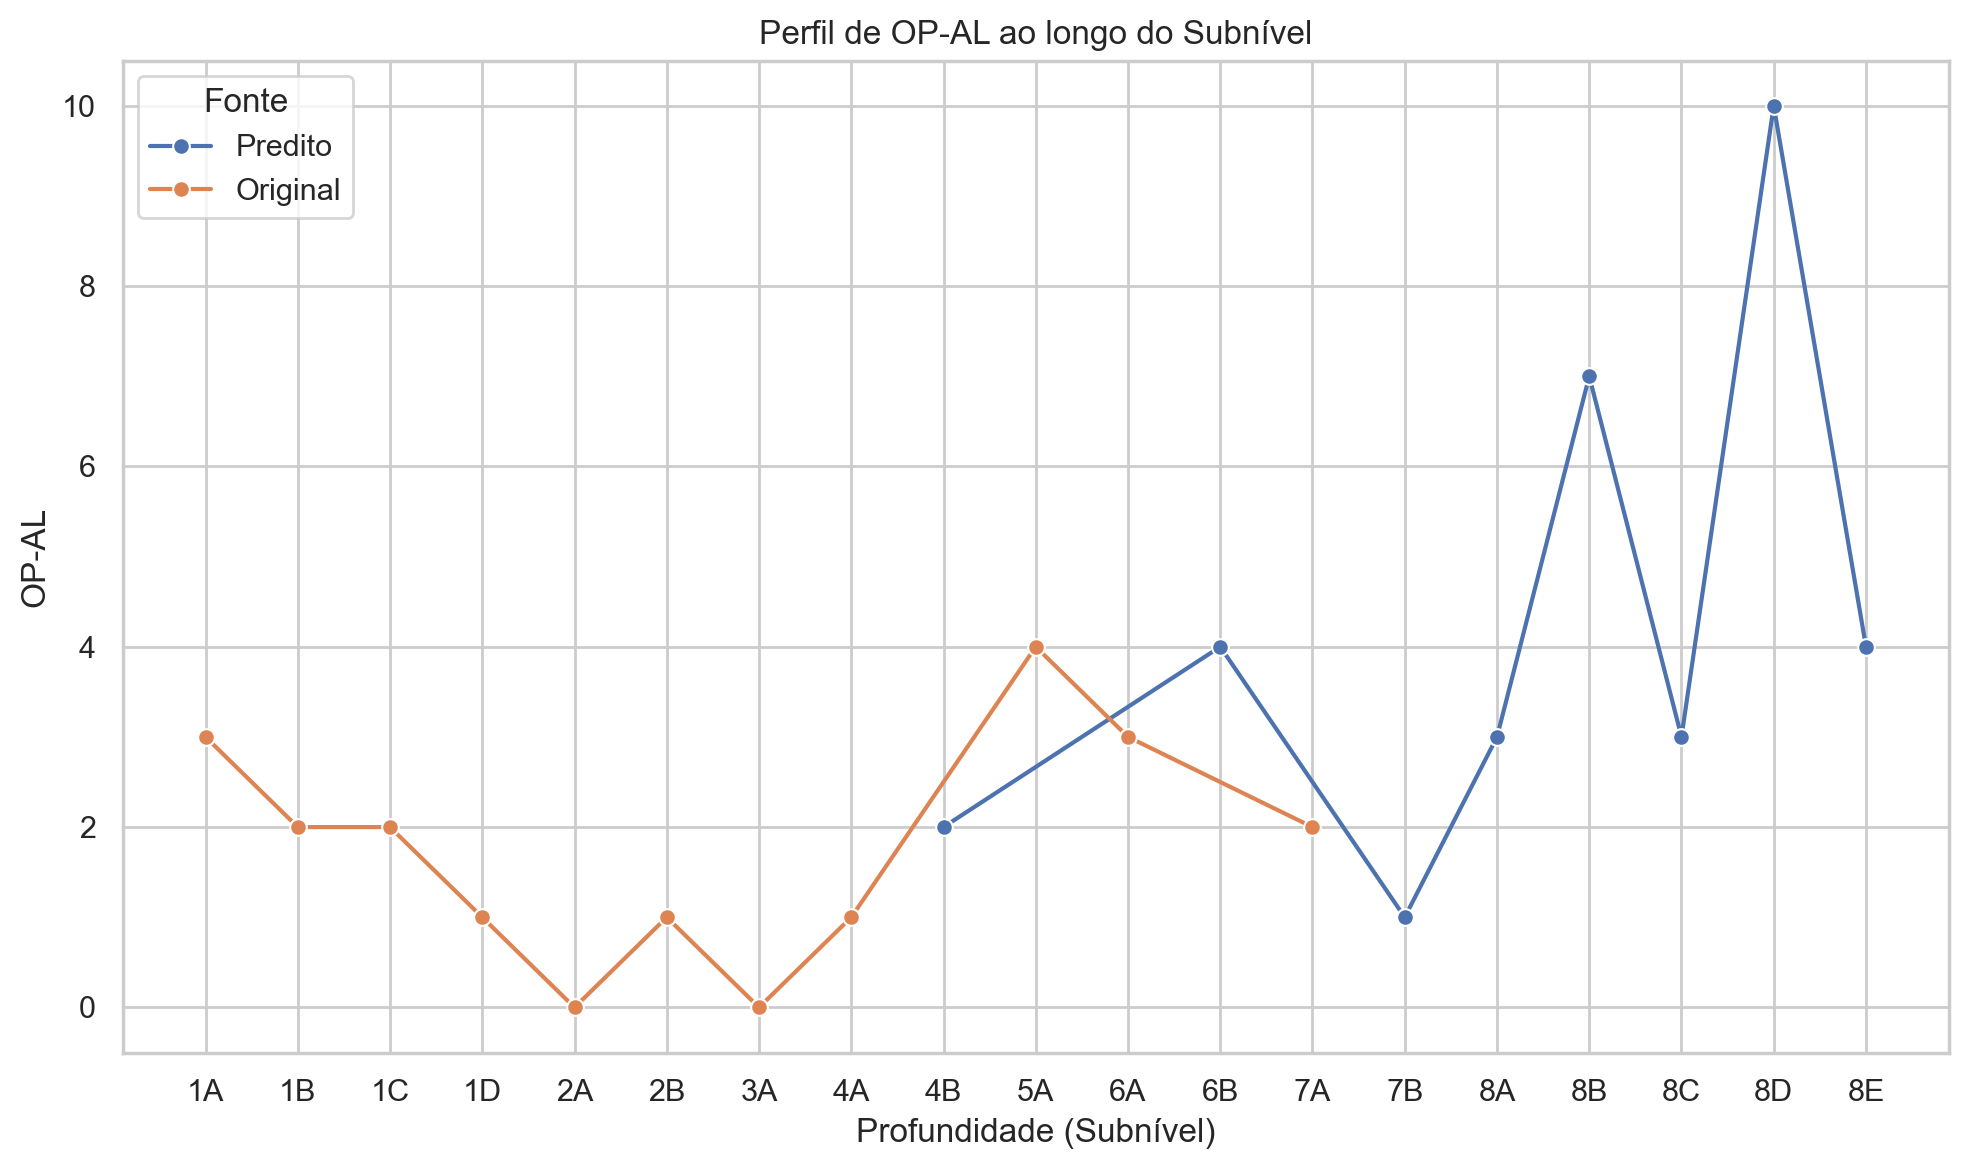

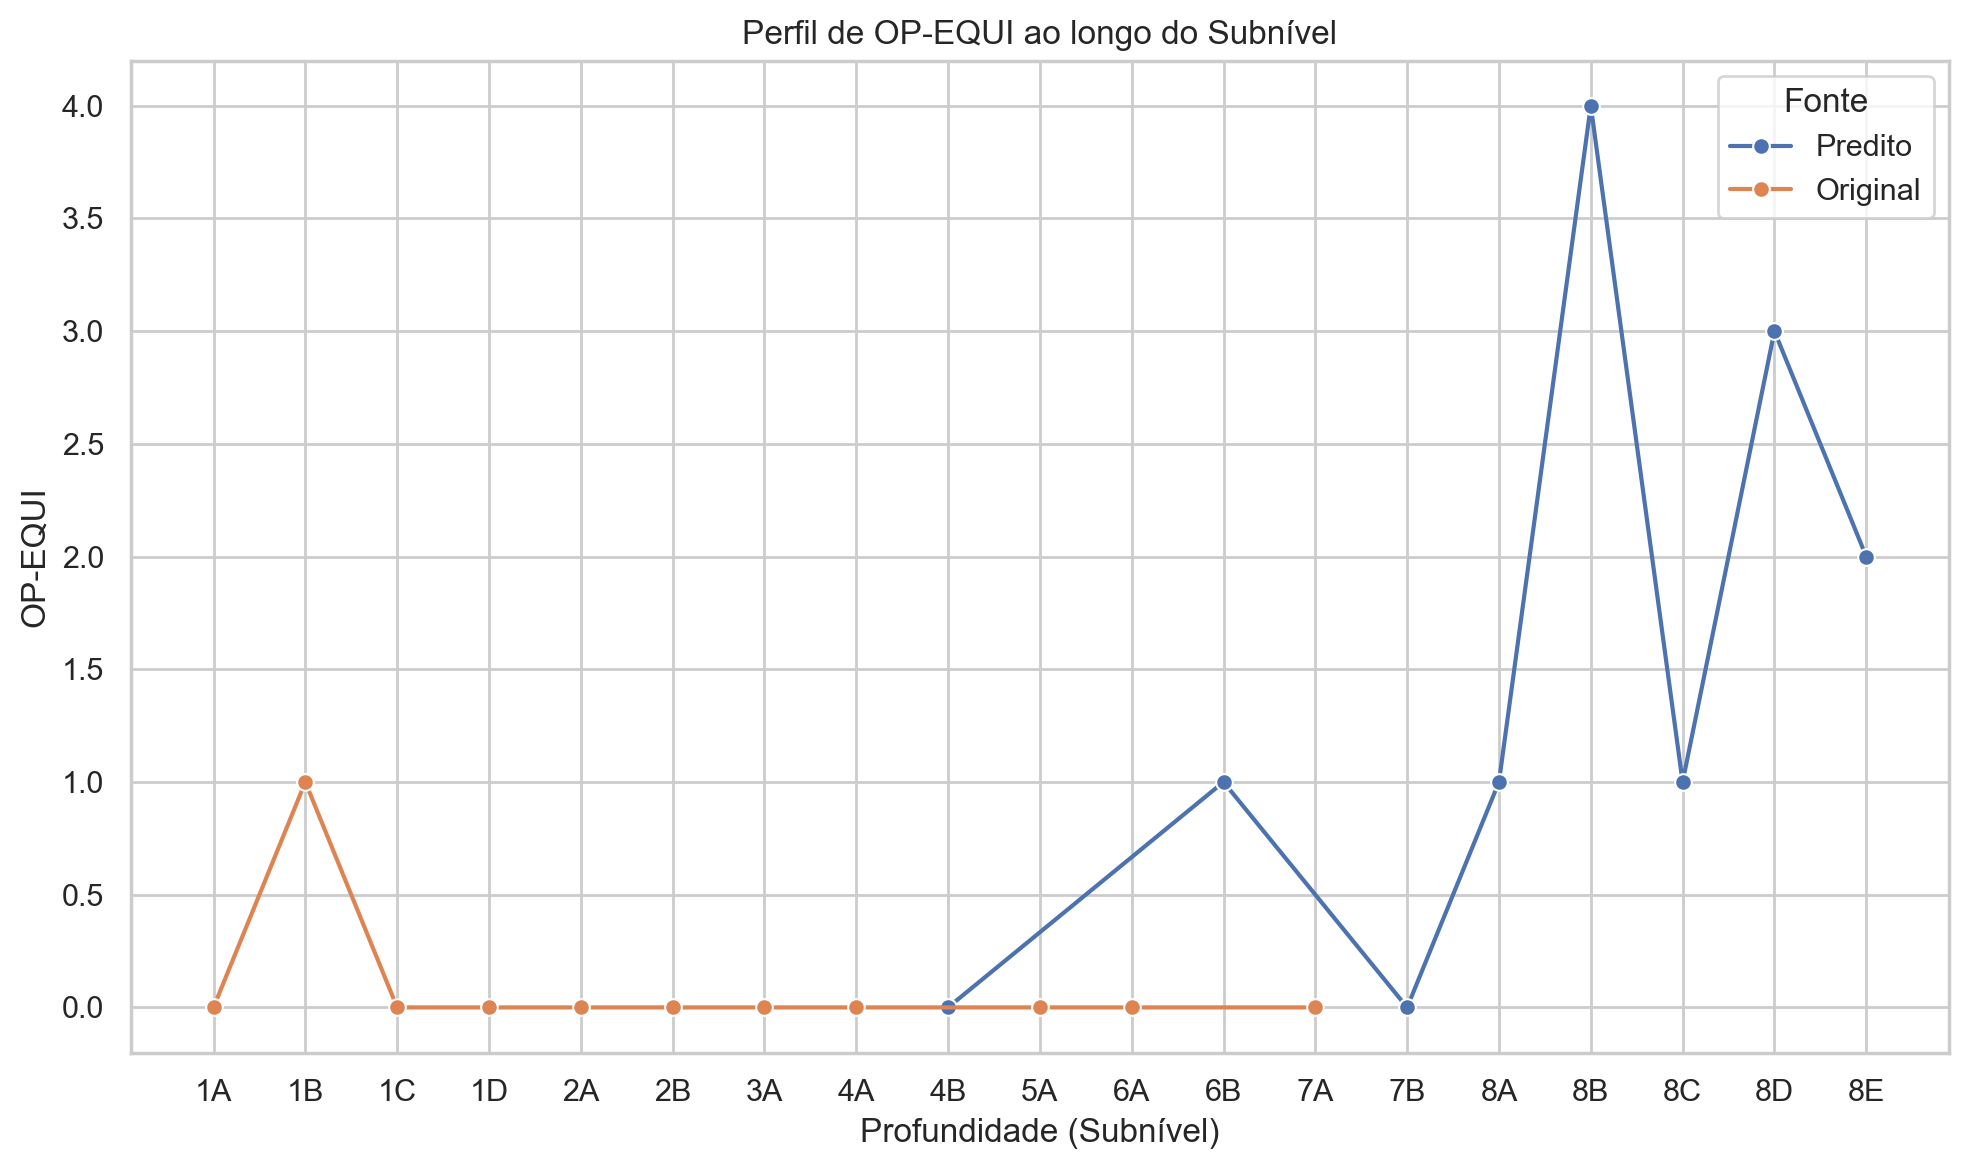

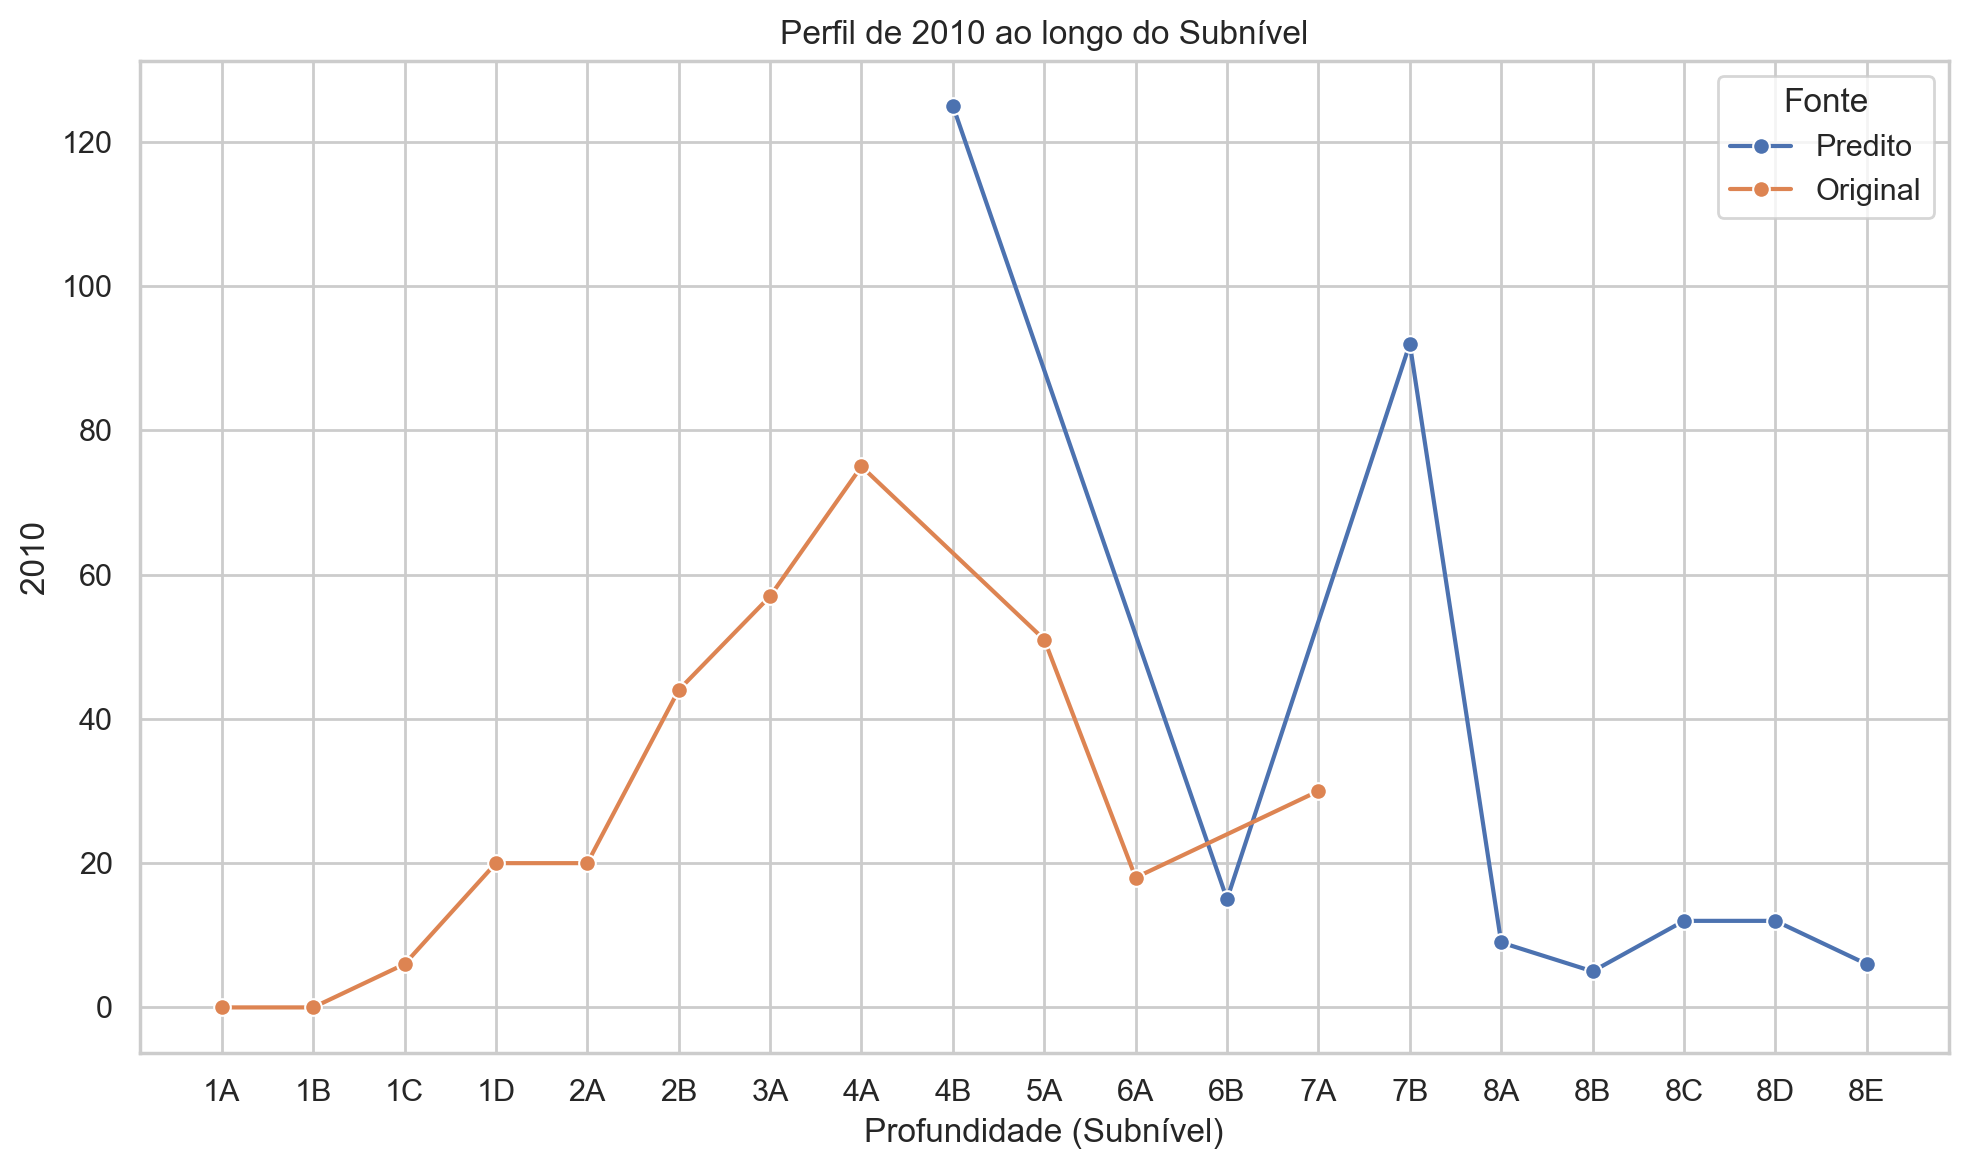

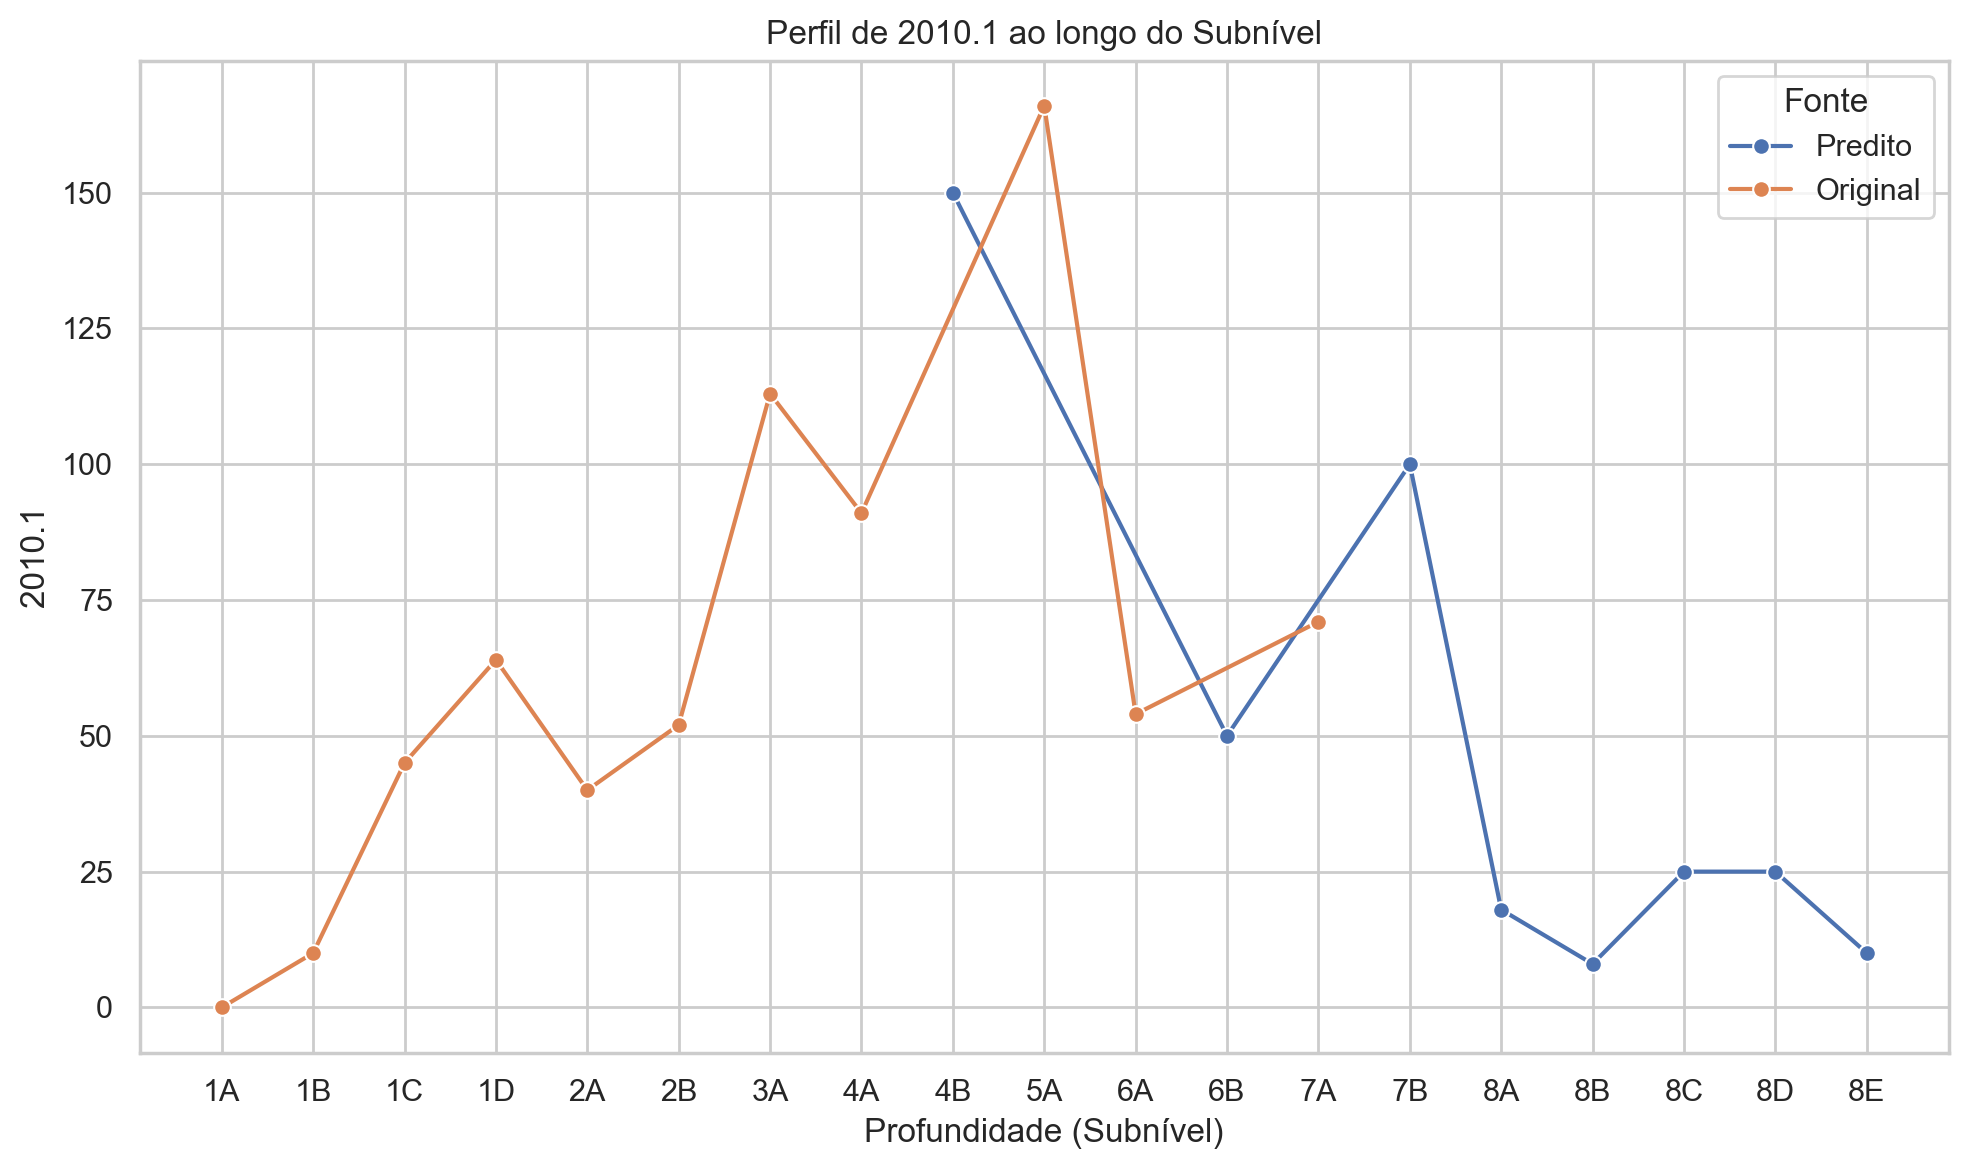

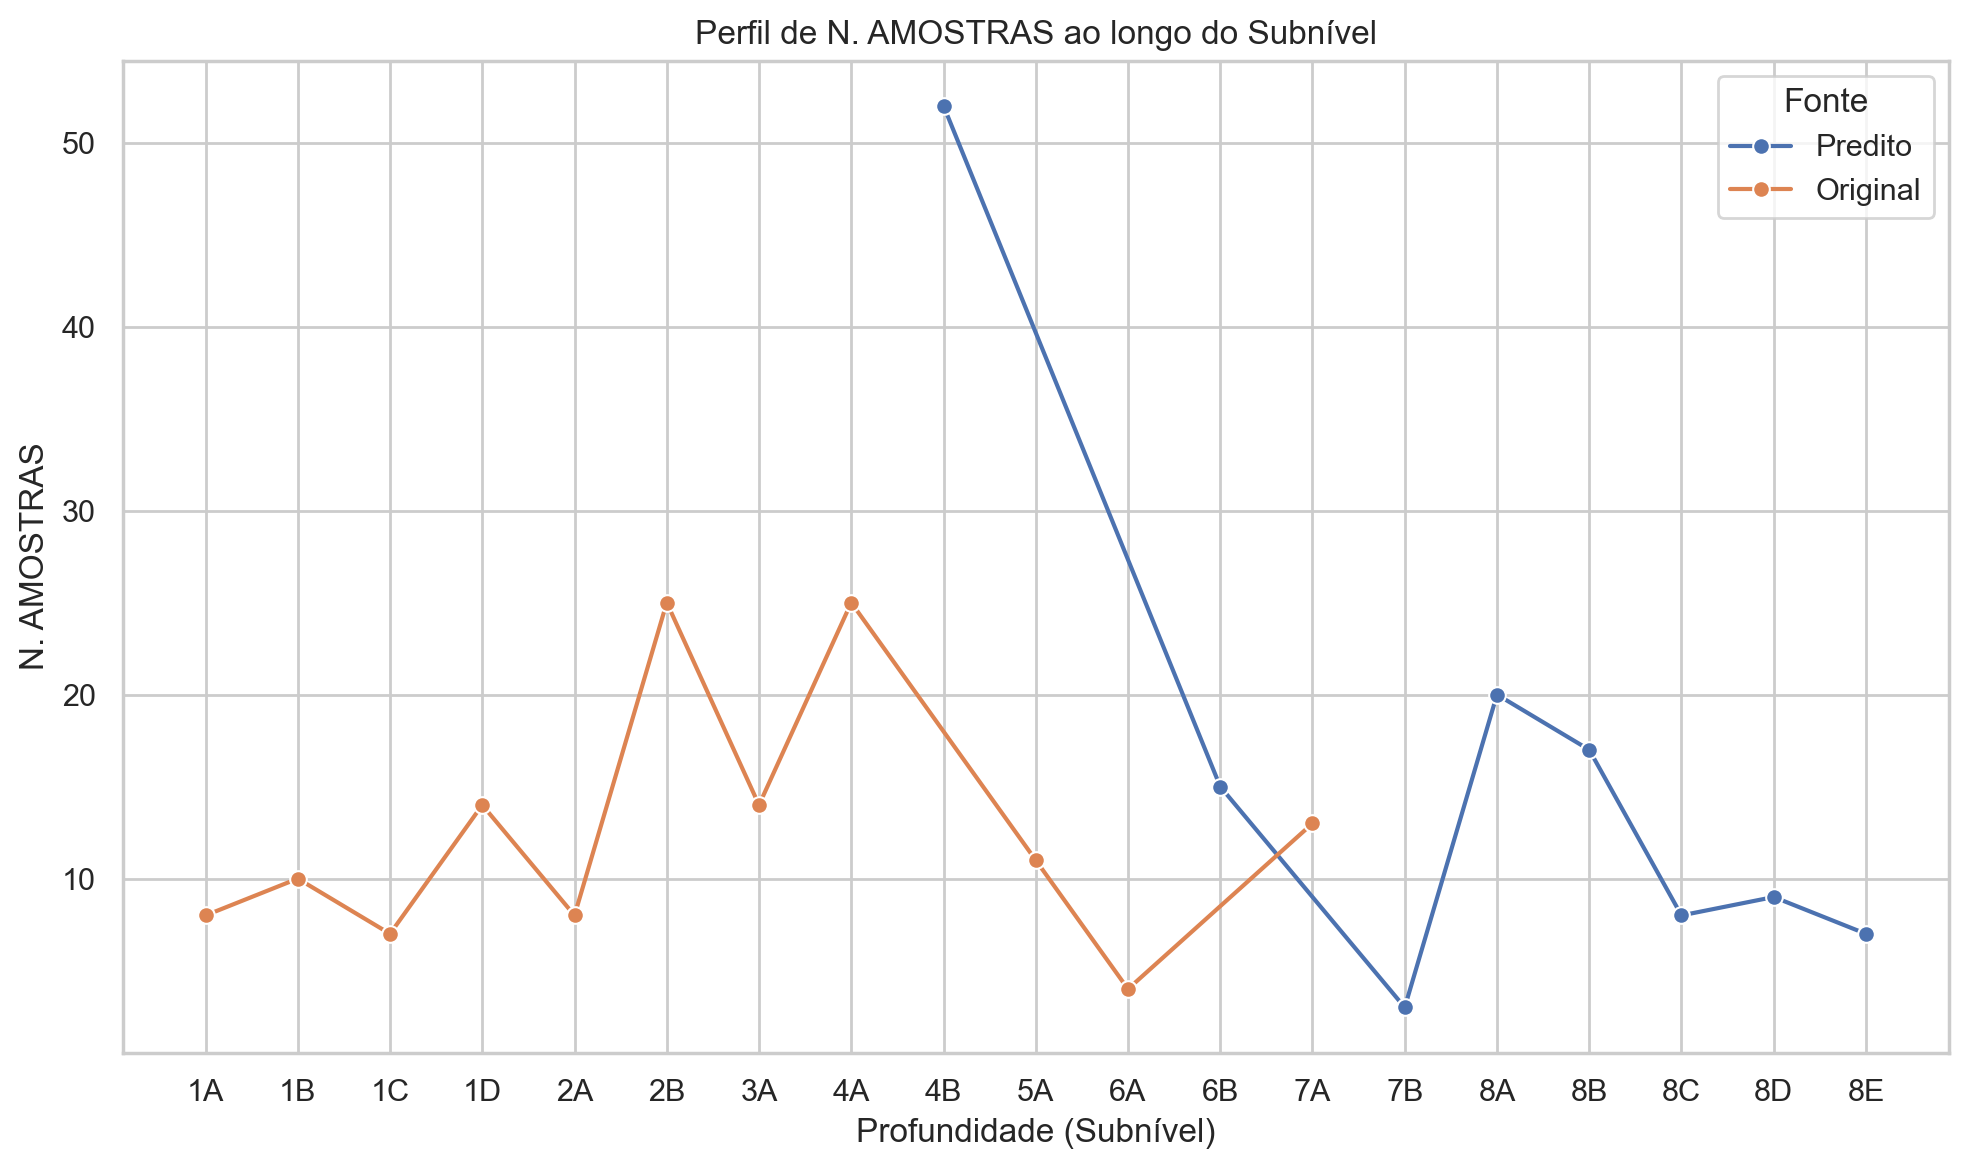

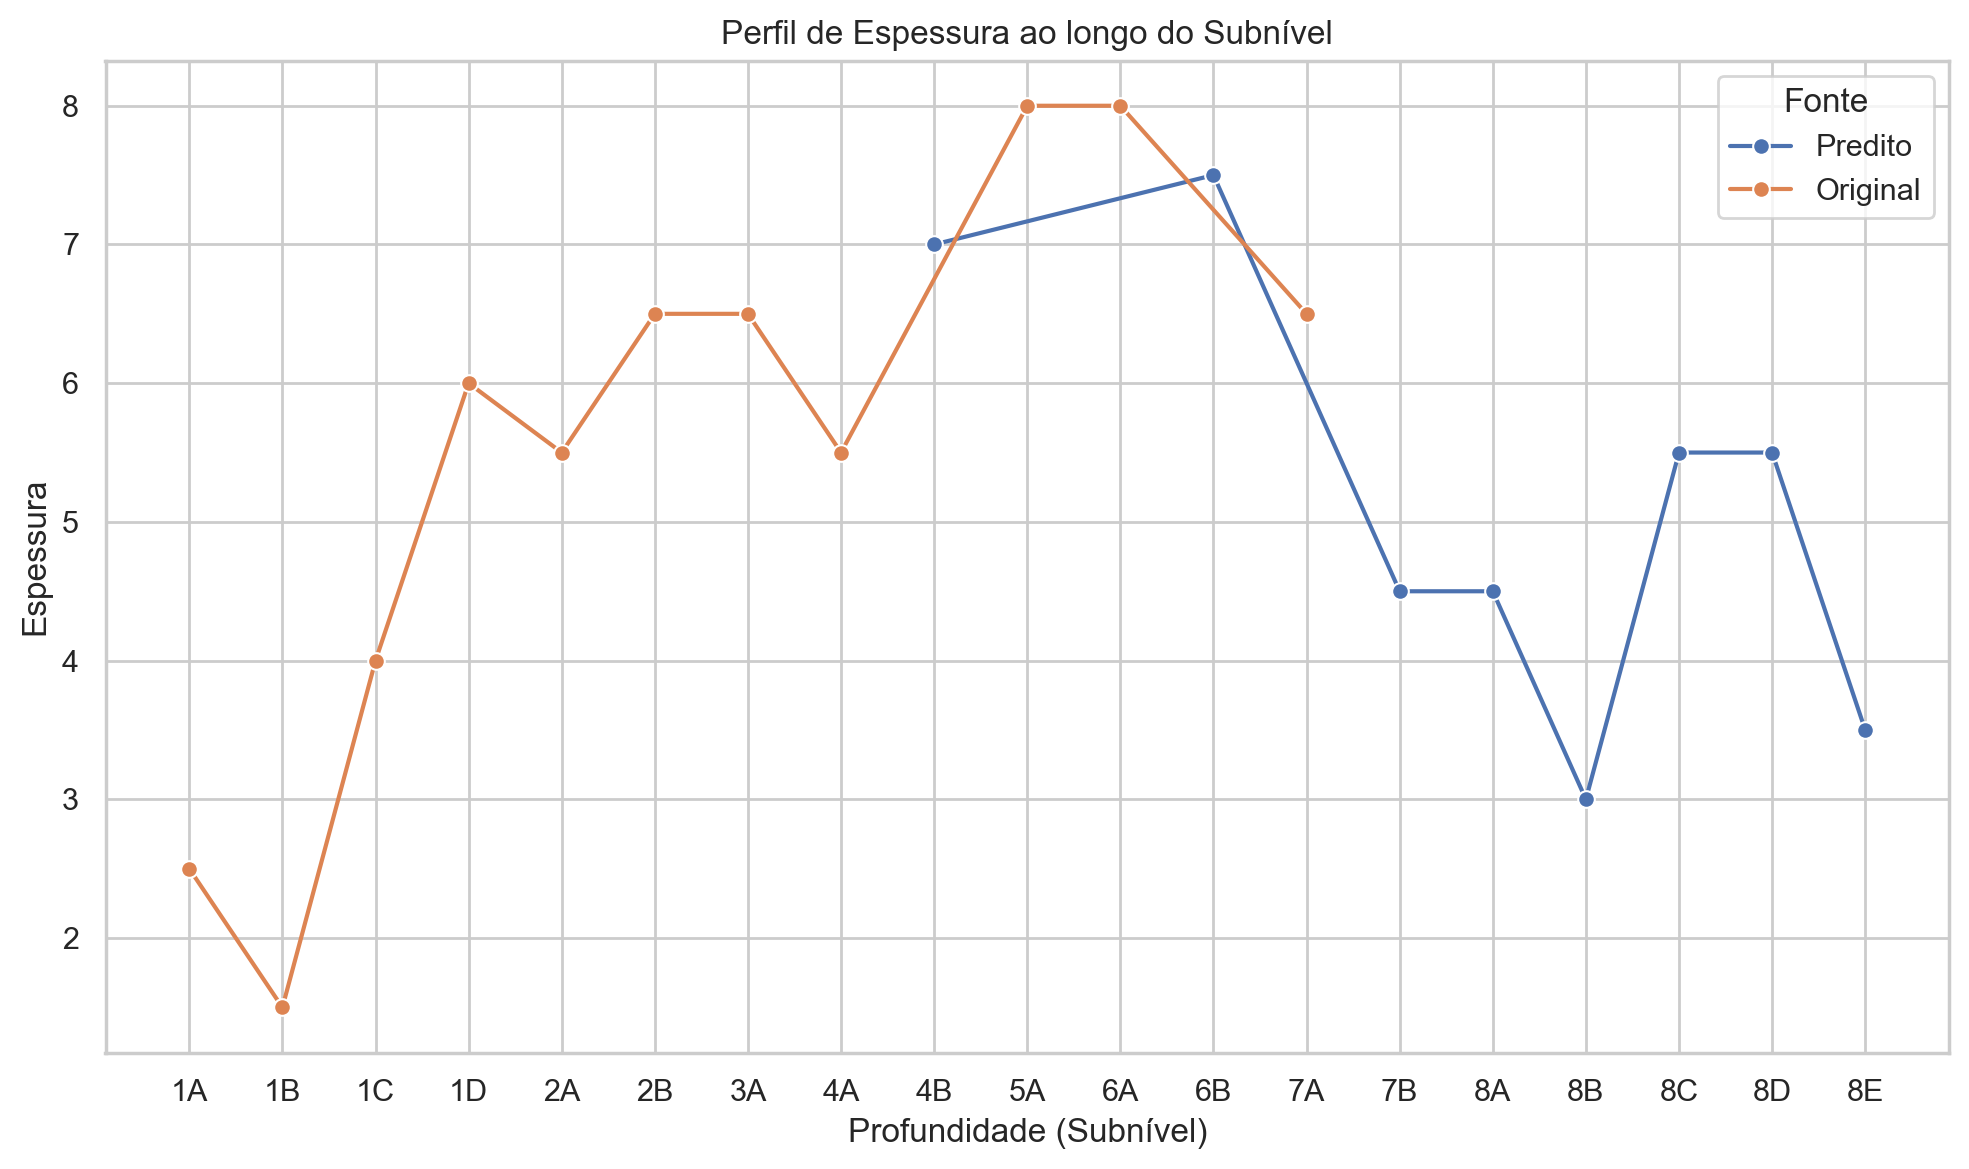

In [ ]:
# Gráfico de linha: eixo x = profundidade, eixo y = teores
sns.lineplot(data=df, x="Subniveis", y="U/Th", hue="Fonte", marker="o")
plt.title("Perfil de U/Th ao longo do Subnível")
plt.xlabel("Profundidade (Subnível)")
plt.ylabel("U/Th")
plt.gca().invert_xaxis()  # Inverte o eixo X, se necessário, para profundidade aumentando da esquerda para a direita
plt.legend(title="Fonte")
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico de linha: eixo x = profundidade, eixo y = teores
sns.lineplot(data=df, x="Subniveis", y="Fe2O3", hue="Fonte", marker="o")
plt.title("Perfil de Fe2O3 ao longo do Subnível")
plt.xlabel("Profundidade (Subnível)")
plt.ylabel("Fe2O3")
plt.gca().invert_xaxis()  # Inverte o eixo X, se necessário, para profundidade aumentando da esquerda para a direita
plt.legend(title="Fonte")
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico de linha: eixo x = profundidade, eixo y = teores
sns.lineplot(data=df, x="Subniveis", y="Al2O3", hue="Fonte", marker="o")
plt.title("Perfil de Al2O3 ao longo do Subnível")
plt.xlabel("Profundidade (Subnível)")
plt.ylabel("Al2O3")
plt.gca().invert_xaxis()  # Inverte o eixo X, se necessário, para profundidade aumentando da esquerda para a direita
plt.legend(title="Fonte")
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico de linha: eixo x = profundidade, eixo y = teores
sns.lineplot(data=df, x="Subniveis", y="TiO2", hue="Fonte", marker="o")
plt.title("Perfil de TiO2 ao longo do Subnível")
plt.xlabel("Profundidade (Subnível)")
plt.ylabel("TiO2")
plt.gca().invert_xaxis()  # Inverte o eixo X, se necessário, para profundidade aumentando da esquerda para a direita
plt.legend(title="Fonte")
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico de linha: eixo x = profundidade, eixo y = teores
sns.lineplot(data=df, x="Subniveis", y="TS", hue="Fonte", marker="o")
plt.title("Perfil de TS ao longo do Subnível")
plt.xlabel("Profundidade (Subnível)")
plt.ylabel("TS")
plt.gca().invert_xaxis()  # Inverte o eixo X, se necessário, para profundidade aumentando da esquerda para a direita
plt.legend(title="Fonte")
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico de linha: eixo x = profundidade, eixo y = teores
sns.lineplot(data=df, x="Subniveis", y="TOC", hue="Fonte", marker="o")
plt.title("Perfil de TOC ao longo do Subnível")
plt.xlabel("Profundidade (Subnível)")
plt.ylabel("TOC")
plt.gca().invert_xaxis()  # Inverte o eixo X, se necessário, para profundidade aumentando da esquerda para a direita
plt.legend(title="Fonte")
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico de linha: eixo x = profundidade, eixo y = teores
sns.lineplot(data=df, x="Subniveis", y="TN", hue="Fonte", marker="o")
plt.title("Perfil de TN ao longo do Subnível")
plt.xlabel("Profundidade (Subnível)")
plt.ylabel("TN")
plt.gca().invert_xaxis()  # Inverte o eixo X, se necessário, para profundidade aumentando da esquerda para a direita
plt.legend(title="Fonte")
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico de linha: eixo x = profundidade, eixo y = teores
sns.lineplot(data=df, x="Subniveis", y="MOA", hue="Fonte", marker="o")
plt.title("Perfil de MOA ao longo do Subnível")
plt.xlabel("Profundidade (Subnível)")
plt.ylabel("MOA")
plt.gca().invert_xaxis()  # Inverte o eixo X, se necessário, para profundidade aumentando da esquerda para a direita
plt.legend(title="Fonte")
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico de linha: eixo x = profundidade, eixo y = teores
sns.lineplot(data=df, x="Subniveis", y="MOA-NF", hue="Fonte", marker="o")
plt.title("Perfil de MOA-NF ao longo do Subnível")
plt.xlabel("Profundidade (Subnível)")
plt.ylabel("MOA-NF")
plt.gca().invert_xaxis()  # Inverte o eixo X, se necessário, para profundidade aumentando da esquerda para a direita
plt.legend(title="Fonte")
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico de linha: eixo x = profundidade, eixo y = teores
sns.lineplot(data=df, x="Subniveis", y="OP-AL", hue="Fonte", marker="o")
plt.title("Perfil de OP-AL ao longo do Subnível")
plt.xlabel("Profundidade (Subnível)")
plt.ylabel("OP-AL")
plt.gca().invert_xaxis()  # Inverte o eixo X, se necessário, para profundidade aumentando da esquerda para a direita
plt.legend(title="Fonte")
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico de linha: eixo x = profundidade, eixo y = teores
sns.lineplot(data=df, x="Subniveis", y="OP-EQUI", hue="Fonte", marker="o")
plt.title("Perfil de OP-EQUI ao longo do Subnível")
plt.xlabel("Profundidade (Subnível)")
plt.ylabel("OP-EQUI")
plt.gca().invert_xaxis()  # Inverte o eixo X, se necessário, para profundidade aumentando da esquerda para a direita
plt.legend(title="Fonte")
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico de linha: eixo x = profundidade, eixo y = teores
sns.lineplot(data=df, x="Subniveis", y="2010", hue="Fonte", marker="o")
plt.title("Perfil de 2010 ao longo do Subnível")
plt.xlabel("Profundidade (Subnível)")
plt.ylabel("2010")
plt.gca().invert_xaxis()  # Inverte o eixo X, se necessário, para profundidade aumentando da esquerda para a direita
plt.legend(title="Fonte")
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico de linha: eixo x = profundidade, eixo y = teores
sns.lineplot(data=df, x="Subniveis", y="2010.1", hue="Fonte", marker="o")
plt.title("Perfil de 2010.1 ao longo do Subnível")
plt.xlabel("Profundidade (Subnível)")
plt.ylabel("2010.1")
plt.gca().invert_xaxis()  # Inverte o eixo X, se necessário, para profundidade aumentando da esquerda para a direita
plt.legend(title="Fonte")
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico de linha: eixo x = profundidade, eixo y = teores
sns.lineplot(data=df, x="Subniveis", y="N. AMOSTRAS", hue="Fonte", marker="o")
plt.title("Perfil de N. AMOSTRAS ao longo do Subnível")
plt.xlabel("Profundidade (Subnível)")
plt.ylabel("N. AMOSTRAS")
plt.gca().invert_xaxis()  # Inverte o eixo X, se necessário, para profundidade aumentando da esquerda para a direita
plt.legend(title="Fonte")
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico de linha: eixo x = profundidade, eixo y = teores
sns.lineplot(data=df, x="Subniveis", y="Espessura", hue="Fonte", marker="o")
plt.title("Perfil de Espessura ao longo do Subnível")
plt.xlabel("Profundidade (Subnível)")
plt.ylabel("Espessura")
plt.gca().invert_xaxis()  # Inverte o eixo X, se necessário, para profundidade aumentando da esquerda para a direita
plt.legend(title="Fonte")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import KFold, cross_val_score

# Use only rows with all targets present
df_model = df.dropna(subset=["U/Th", "Fe2O3", "Al2O3", "TiO2", "TS", "TOC", "TN", "MOA"]).reset_index(drop=True)

# Definindo as features (variáveis preditoras) e alvos (multivariado)
X = df_model[["MOA-NF", "OP-AL", "OP-EQUI", "2010", "2010.1", "Espessura", "N. AMOSTRAS"]]
y = df_model[["U/Th", "Fe2O3", "Al2O3", "TiO2", "TS", "TOC", "TN", "MOA"]]

# Modelo Random Forest
model = RandomForestRegressor(random_state=42, n_estimators=1000, n_jobs=-1)

# Validação cruzada K-Fold (K=5 ou menos se poucos dados)
kfold = KFold(n_splits=min(5, len(X)), shuffle=True, random_state=42)

# Avaliação com RMSE negativo (scikit-learn usa "neg_mean_squared_error")
rmse_scores = np.sqrt(-cross_val_score(model, X, y, cv=kfold, scoring='neg_mean_squared_error'))
mae_scores = -cross_val_score(model, X, y, cv=kfold, scoring='neg_mean_absolute_error')
r2_scores = cross_val_score(model, X, y, cv=kfold, scoring='r2')

print('--- Validação Cruzada Random Forest ---')
print(f'RMSE médio: {rmse_scores.mean():.4f} (± {rmse_scores.std():.4f})')
print(f'MAE médio : {mae_scores.mean():.4f} (± {mae_scores.std():.4f})')
print(f'R² médio  : {r2_scores.mean():.4f} (± {r2_scores.std():.4f})')

--- Validação Cruzada Random Forest ---
RMSE médio: 11.1444 (± 3.3415)
MAE médio : 3.4926 (± 1.1019)
R² médio  : -1.6634 (± 2.0328)


In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
import numpy as np

# Usar apenas linhas sem valores faltantes nas variáveis alvo
df_model = df.dropna(subset=["U/Th", "Fe2O3", "Al2O3", "TiO2", "TS", "TOC", "TN", "MOA"]).reset_index(drop=True)

# Definindo as features (variáveis preditoras) e alvos (multivariado)
X = df_model[["MOA-NF", "OP-AL", "OP-EQUI", "2010", "2010.1", "Espessura", "N. AMOSTRAS"]]
y = df_model[["U/Th", "Fe2O3", "Al2O3", "TiO2", "TS", "TOC", "TN", "MOA"]]

# Instanciando o modelo Random Forest multivariado
base_model = RandomForestRegressor(random_state=42, n_estimators=1000, n_jobs=-1)
model = MultiOutputRegressor(base_model)

# Validação cruzada K-Fold
kfold = KFold(n_splits=min(5, len(X)), shuffle=True, random_state=42)

# Avaliação com RMSE
rmse_scores = np.sqrt(-cross_val_score(model, X, y, cv=kfold, scoring='neg_mean_squared_error'))
mae_scores = -cross_val_score(model, X, y, cv=kfold, scoring='neg_mean_absolute_error')
r2_scores = cross_val_score(model, X, y, cv=kfold, scoring='r2')

print('--- Validação Cruzada Random Forest ---')
print(f'RMSE médio: {rmse_scores.mean():.4f} (± {rmse_scores.std():.4f})')
print(f'MAE médio : {mae_scores.mean():.4f} (± {mae_scores.std():.4f})')
print(f'R² médio  : {r2_scores.mean():.4f} (± {r2_scores.std():.4f})')

--- Validação Cruzada Random Forest ---
RMSE médio: 11.1372 (± 3.3621)
MAE médio : 3.4925 (± 1.1041)
R² médio  : -1.5128 (± 1.7811)


In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import pandas as pd

# ============================
# Dados
# ============================

# Selecionar apenas linhas com dados completos nas variáveis alvo
df_model = df.dropna(subset=["U/Th", "Fe2O3", "Al2O3", "TiO2", "TS", "TOC", "TN", "MOA"]).reset_index(drop=True)

# Features
X = df_model[["MOA-NF", "OP-AL", "OP-EQUI", "2010", "2010.1", "Espessura", "N. AMOSTRAS"]]

# Targets
targets = ["U/Th", "Fe2O3", "Al2O3", "TiO2", "TS", "TOC", "TN", "MOA"]

# ============================
# Configuração da validação cruzada
# ============================

kfold = KFold(n_splits=min(5, len(X)), shuffle=True, random_state=42)

# ============================
# Loop para cada variável alvo
# ============================

results = []

for target in targets:
    y = df_model[target]

    model = RandomForestRegressor(
        random_state=42,
        n_estimators=1000,
        n_jobs=-1
    )

    # RMSE
    rmse = np.sqrt(
        -cross_val_score(model, X, y, cv=kfold, scoring='neg_mean_squared_error')
    )

    # MAE
    mae = -cross_val_score(model, X, y, cv=kfold, scoring='neg_mean_absolute_error')

    # R2
    r2 = cross_val_score(model, X, y, cv=kfold, scoring='r2')

    results.append({
        'Variável': target,
        'RMSE médio': rmse.mean(),
        'RMSE std': rmse.std(),
        'MAE médio': mae.mean(),
        'MAE std': mae.std(),
        'R² médio': r2.mean(),
        'R² std': r2.std()
    })

# ============================
# Resultado consolidado
# ============================

df_results = pd.DataFrame(results)

print("\n=== Avaliação por variável ===\n")
print(df_results.round(4))



=== Avaliação por variável ===

  Variável  RMSE médio  RMSE std  MAE médio  MAE std  R² médio  R² std
0     U/Th      0.2505    0.1282     0.1794   0.0893   -0.2157  0.5356
1    Fe2O3      0.5101    0.2218     0.4055   0.1878   -2.1449  3.3720
2    Al2O3      0.3423    0.2250     0.2895   0.1981   -0.0535  0.5571
3     TiO2      0.0152    0.0087     0.0124   0.0071   -0.3557  0.9383
4       TS      1.0151    0.3198     0.7735   0.2709   -1.6727  1.7222
5      TOC      2.0931    0.6065     1.5677   0.4174   -1.2518  1.3084
6       TN      0.0881    0.0316     0.0690   0.0222   -1.5332  2.0021
7      MOA     31.3896    9.5378    24.6427   8.5346   -4.8747  8.0961


In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import KFold, cross_val_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Remover linhas com valores faltantes nas variáveis alvo
df_model = df.dropna(subset=["U/Th", "Fe2O3", "Al2O3", "TiO2", "TS", "TOC", "TN", "MOA"]).reset_index(drop=True)

# Features
X = df_model[["MOA-NF", "OP-AL", "OP-EQUI", "2010", "2010.1", "Espessura", "N. AMOSTRAS"]]

# Target - Exemplo: prever "Fe2O3"
y = df_model["Fe2O3"]

# Definir o modelo
model = DecisionTreeRegressor(
    random_state=42,
    max_depth=3  # Limitar profundidade para evitar overfitting
)

# Treinar o modelo
model.fit(X, y)

kfold = KFold(n_splits=min(5, len(X)), shuffle=True, random_state=42)

rmse = np.sqrt(-cross_val_score(model, X, y, cv=kfold, scoring='neg_mean_squared_error'))
mae = -cross_val_score(model, X, y, cv=kfold, scoring='neg_mean_absolute_error')
r2 = cross_val_score(model, X, y, cv=kfold, scoring='r2')

print('--- Avaliação Árvore de Decisão ---')
print(f'RMSE médio: {rmse.mean():.4f} (± {rmse.std():.4f})')
print(f'MAE médio : {mae.mean():.4f} (± {mae.std():.4f})')
print(f'R² médio  : {r2.mean():.4f} (± {r2.std():.4f})')


--- Avaliação Árvore de Decisão ---
RMSE médio: 0.6382 (± 0.1805)
MAE médio : 0.4842 (± 0.1348)
R² médio  : -2.0114 (± 2.3526)


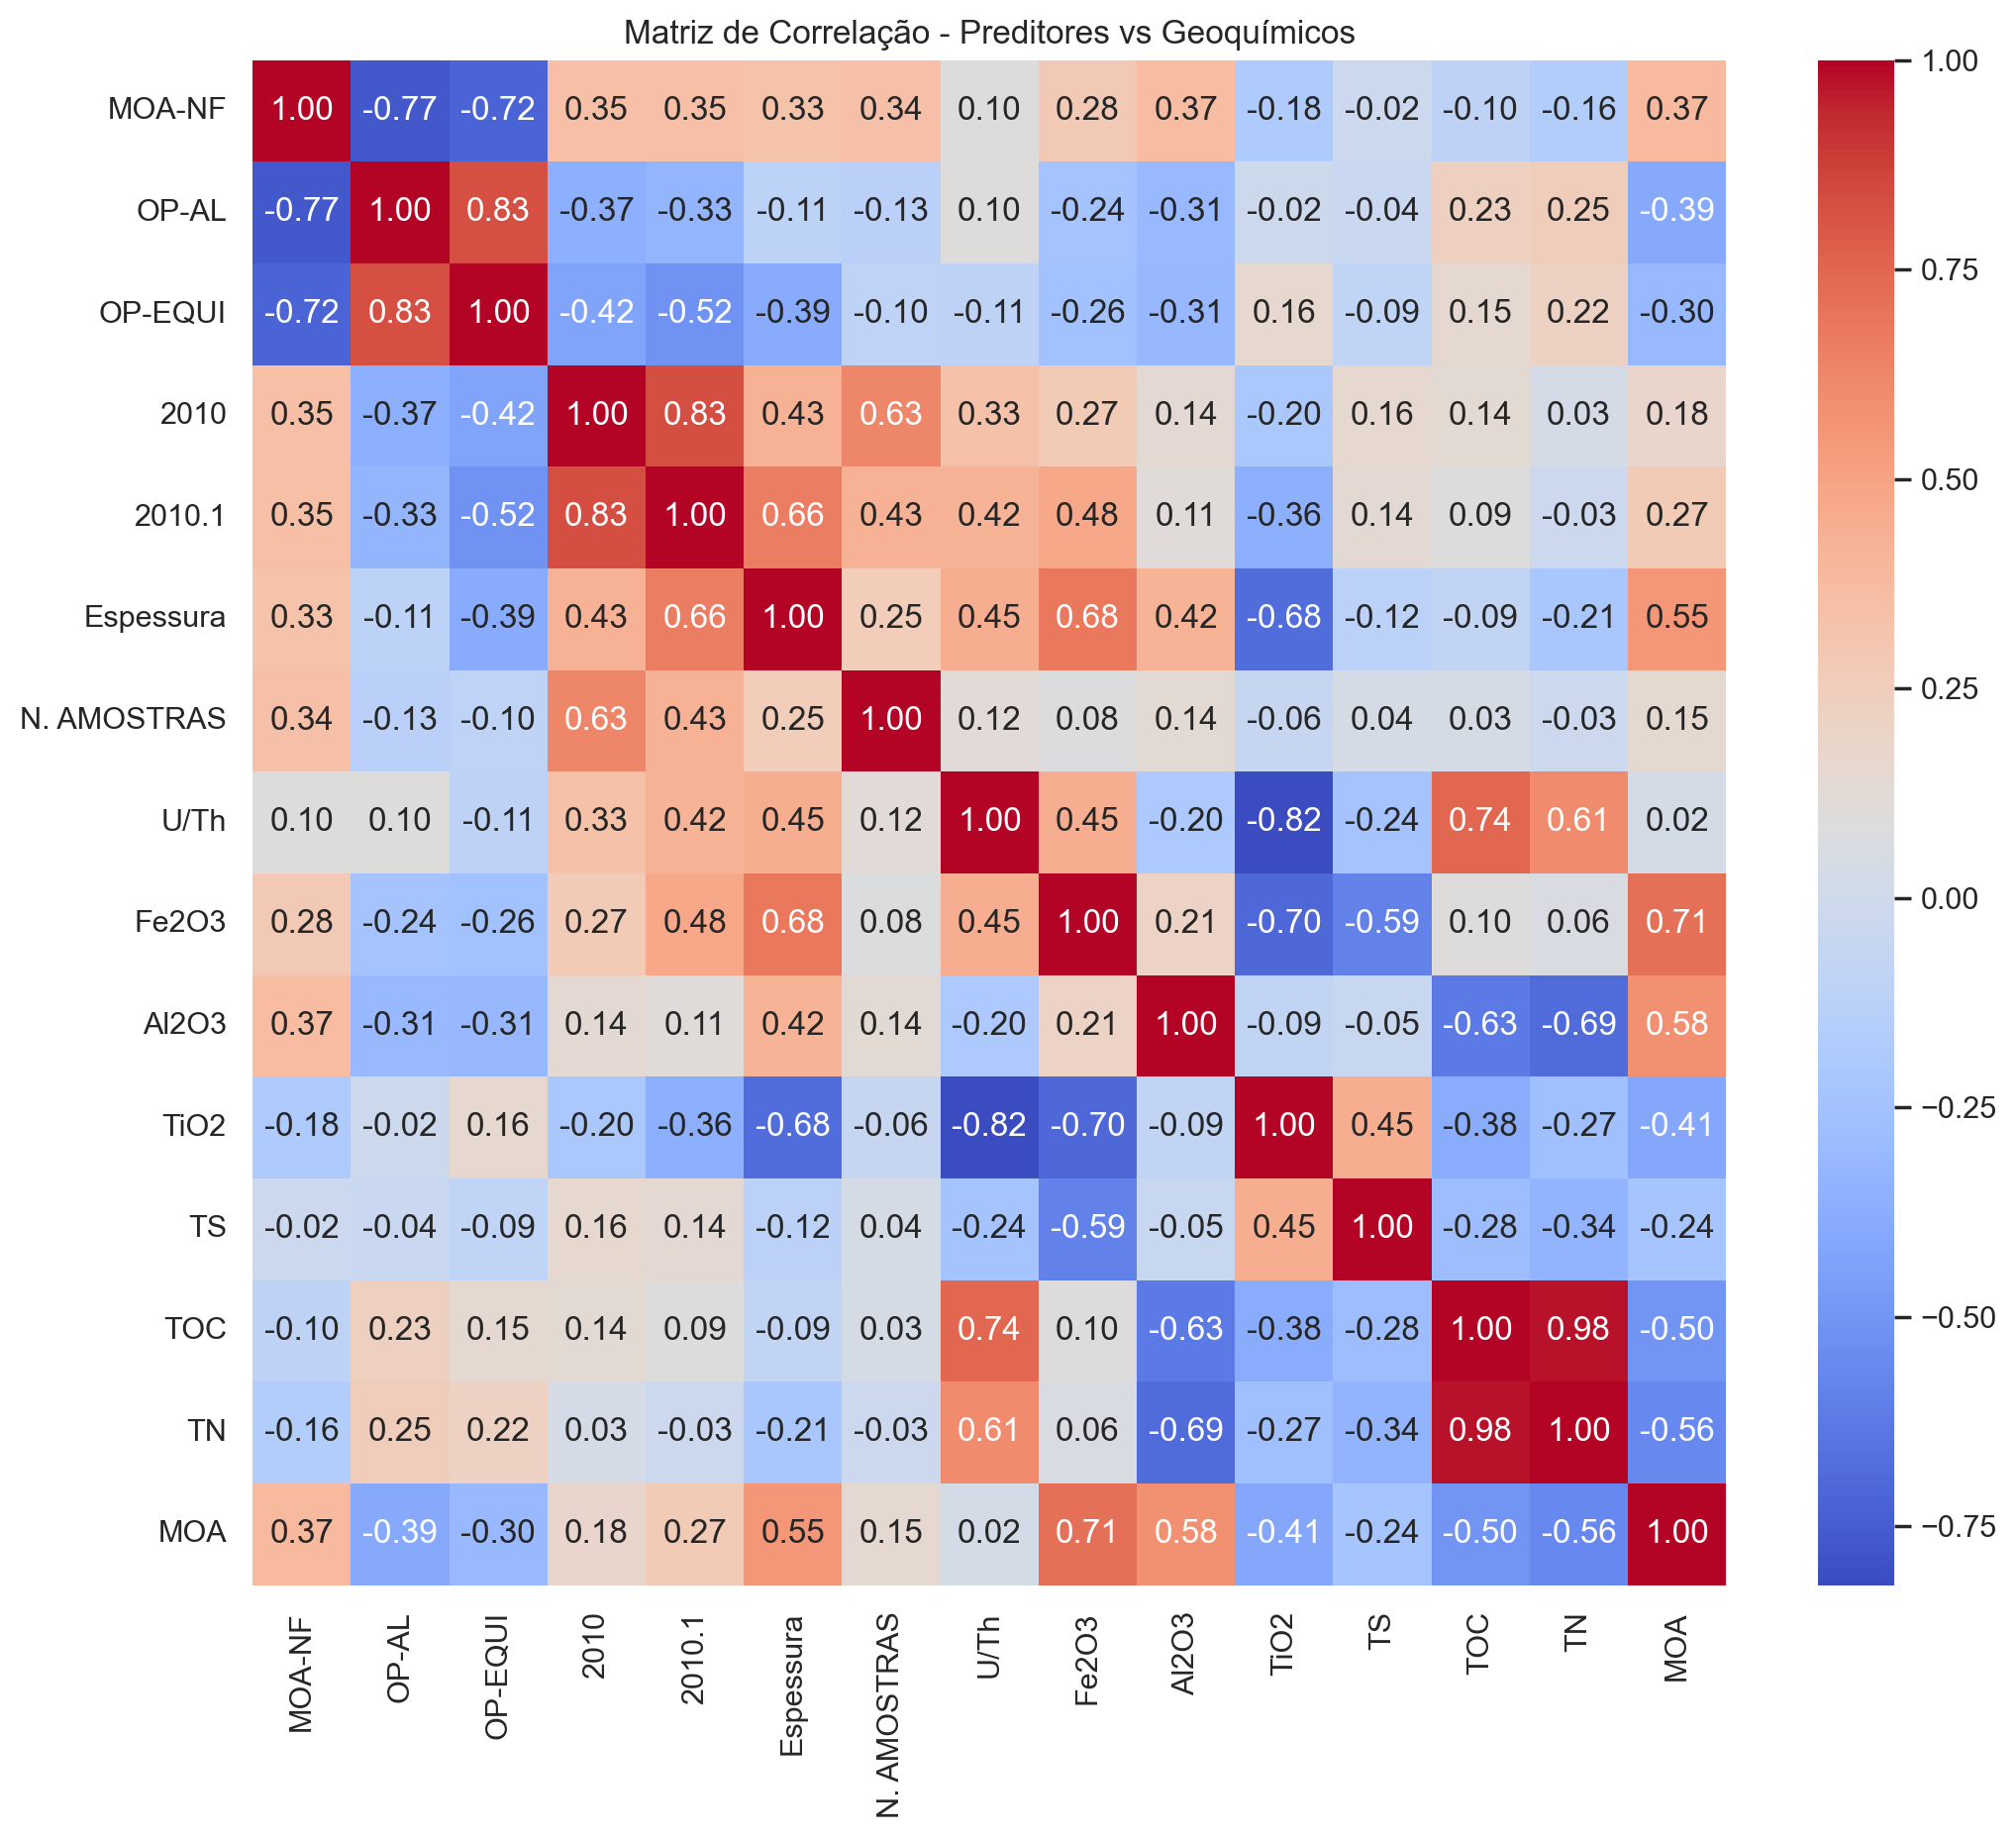

In [ ]:
# Selecionar preditores + alvos
variaveis = ["MOA-NF", "OP-AL", "OP-EQUI", "2010", "2010.1", "Espessura", "N. AMOSTRAS",
              "U/Th", "Fe2O3", "Al2O3", "TiO2", "TS", "TOC", "TN", "MOA"]

# Matriz de correlação
corr = df[variaveis].corr()

# Plotar
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação - Preditores vs Geoquímicos")
plt.show()


In [ ]:
# Dados
X = df[['MOA', 'Espessura', '2010.1']].values
y = df['Fe2O3'].values

# Remover NaNs
mask = ~np.isnan(y) & ~np.isnan(X).any(axis=1)
X = X[mask]
y = y[mask]

# Criar o modelo
model_multi = LinearRegression()
model_multi.fit(X, y)

# Coeficientes
print('\nRegressão Linear Múltipla — Fe2O3 ~ MOA + Espessura + 2010.1')
print(f'Coeficientes (b1, b2, b3): {model_multi.coef_}')
print(f'Intercepto (b0): {model_multi.intercept_:.4f}')
print(f'R² da regressão: {model_multi.score(X, y):.4f}')

# Preencher valores ausentes somente se houver NaNs
missing_mask = df['Fe2O3'].isna()
if missing_mask.any():
    df.loc[missing_mask, 'Fe2O3'] = model_multi.predict(
        df.loc[missing_mask, ['MOA', 'Espessura', '2010.1']].values
    )



Regressão Linear Múltipla — Fe2O3 ~ MOA + Espessura + 2010.1
Coeficientes (b1, b2, b3): [0.00968509 0.11619722 0.00185395]
Intercepto (b0): 2.6417
R² da regressão: 0.6333


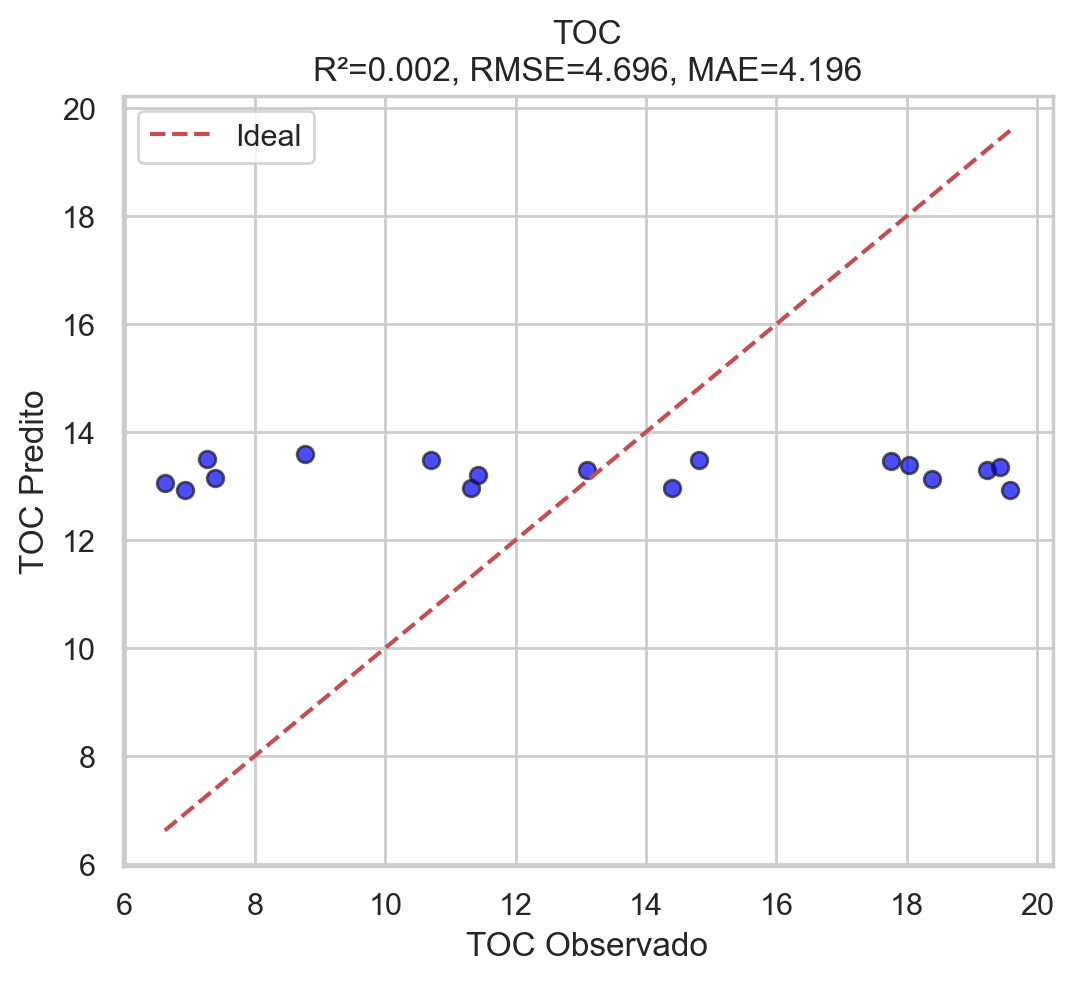

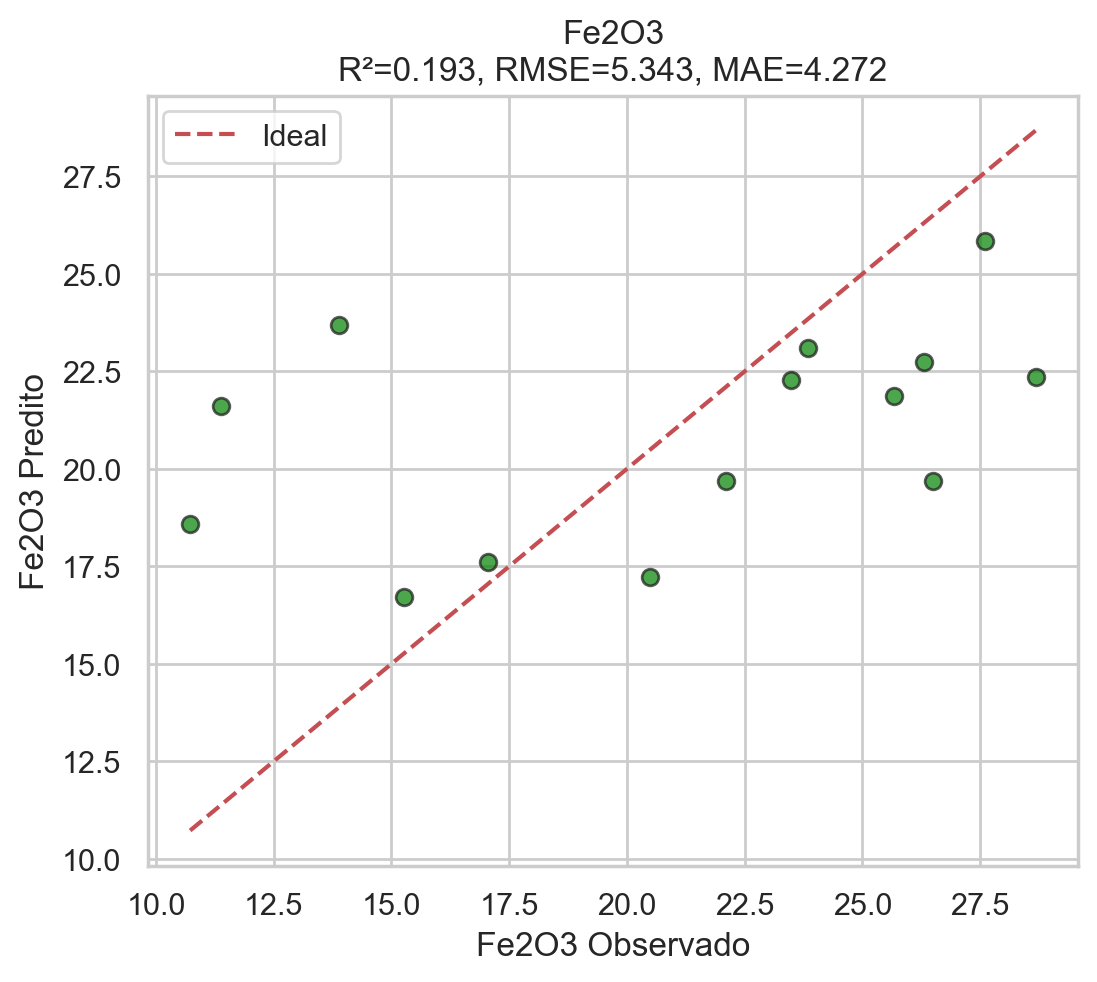

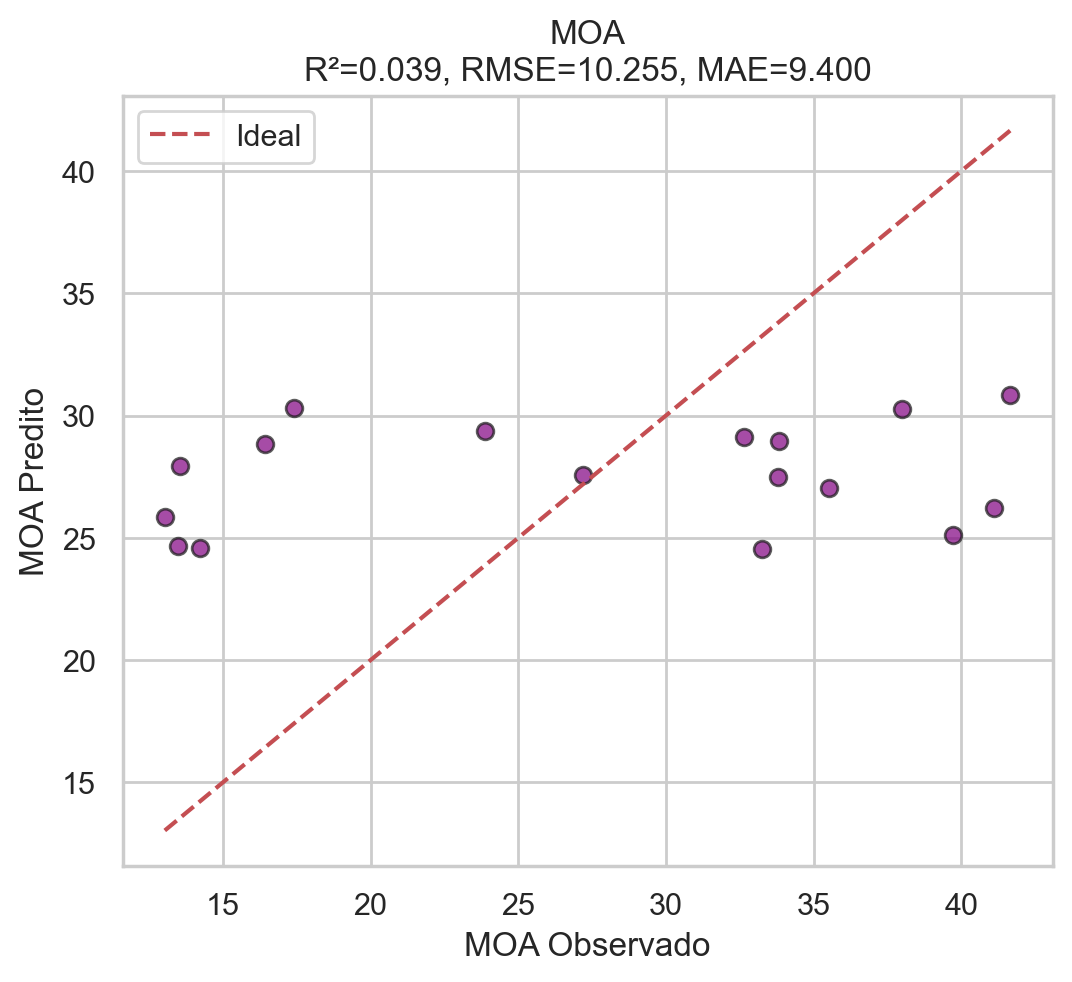

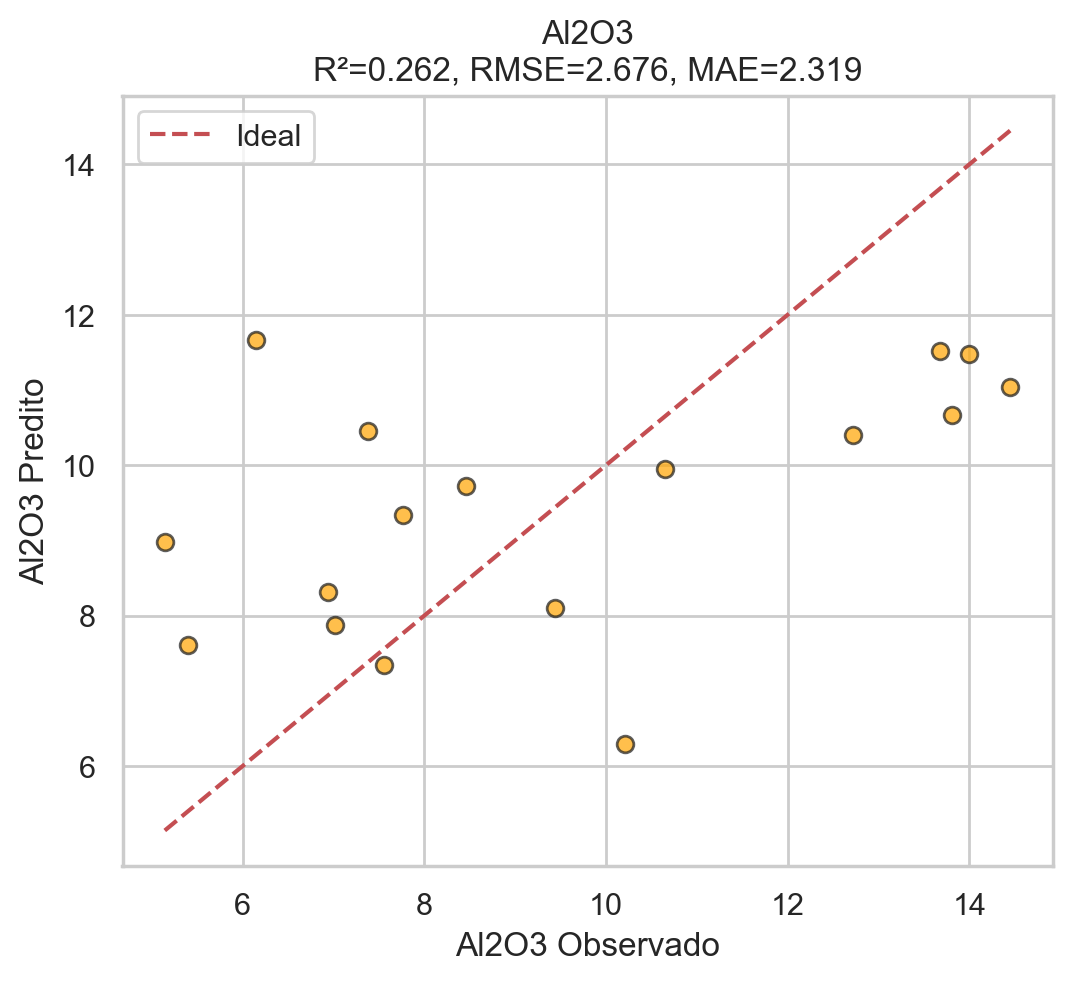


📊 =================== TABELA FINAL PREENCHIDA ===================

   MOA  Espessura  2010.1    TN    TOC  Fe2O3  Al2O3
13.036      2.147 134.330 0.174 14.400 20.492  7.377
16.438      3.881 183.685 0.998  8.775 25.514  5.141
17.408      1.479 182.533 0.941 13.548 23.487  5.399
24.420      1.223 115.917 0.862 14.807 25.020 14.450
39.702      4.885 145.094 0.607 13.101 21.636 14.000
33.775      1.233 142.343 0.920 13.532 15.267  7.767
35.521      2.667 142.971 0.855 10.706 10.727  9.984
23.875      1.007 165.795 0.399 18.395 19.490  9.434
32.592      1.111 197.577 0.727 18.044 13.343 10.209
37.980      1.931 175.163 0.720 13.380 11.380  7.015
33.237      4.263 135.052 0.624 19.240 22.114  6.148
32.655      2.170 178.104 0.183 11.313 28.678  8.401
33.842      1.138 167.425 0.418  7.386 26.490  6.941
41.652      1.688 190.104 0.119 19.591 23.846  7.559
13.482      4.909 143.307 0.137  6.929 25.678 11.713
26.864      4.980 169.076 0.286  6.616 26.198 12.714
41.087      4.461 158.541 0.829

In [ ]:
def plot_regression_real_vs_pred(y_true, y_pred, variable_name, color='blue', save=False):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    plt.scatter(y_true, y_pred, color=color, alpha=0.7, edgecolor='k')
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='Ideal')
    plt.title(f'{variable_name}\nR²={r2:.3f}, RMSE={rmse:.3f}, MAE={mae:.3f}')
    plt.xlabel(f'{variable_name} Observado')
    plt.ylabel(f'{variable_name} Predito')
    plt.grid(True)
    plt.legend()

    if save:
        plt.savefig(f'{variable_name}_regression.png', dpi=300, bbox_inches='tight')
    plt.show()

# =============================
# 📥 Simulação dos dados (Substitua pelo seu DataFrame real)
# =============================
# Exemplo básico para simulação (troque pelo seu df real)
data = {
    'MOA': np.random.uniform(10, 50, 20),
    'Espessura': np.random.uniform(1, 5, 20),
    '2010.1': np.random.uniform(100, 200, 20),
    'TN': np.random.uniform(0.1, 1.0, 20),
    'TOC': np.random.uniform(5, 20, 20),
    'Fe2O3': np.random.uniform(10, 30, 20),
    'Al2O3': np.random.uniform(5, 15, 20)
}

df = pd.DataFrame(data)

# Simular valores ausentes
df.loc[[2, 5, 9], 'TOC'] = np.nan
df.loc[[1, 4, 7], 'Fe2O3'] = np.nan
df.loc[[3, 8, 15], 'MOA'] = np.nan
df.loc[[6, 11, 14], 'Al2O3'] = np.nan

# =============================
# 📈 Regressão Linear Simples — TOC ~ TN
# =============================
X_toc = df[['TN']].values
y_toc = df['TOC'].values

mask_toc = ~np.isnan(X_toc.flatten()) & ~np.isnan(y_toc)
X_toc = X_toc[mask_toc].reshape(-1, 1)
y_toc = y_toc[mask_toc]

model_toc = LinearRegression().fit(X_toc, y_toc)

# Preencher TOC
missing_toc = df['TOC'].isna()
if missing_toc.any():
    df.loc[missing_toc, 'TOC'] = model_toc.predict(
        df.loc[missing_toc, ['TN']].values
    )

# Plot
y_pred_toc = model_toc.predict(X_toc)
plot_regression_real_vs_pred(y_toc, y_pred_toc, 'TOC', color='blue', save=False)

# =============================
# 📈 Regressão Múltipla — Fe2O3 ~ MOA + Espessura + 2010.1
# =============================
X_fe = df[['MOA', 'Espessura', '2010.1']].values
y_fe = df['Fe2O3'].values

mask_fe = ~np.isnan(y_fe) & ~np.isnan(X_fe).any(axis=1)
X_fe = X_fe[mask_fe]
y_fe = y_fe[mask_fe]

model_fe = LinearRegression().fit(X_fe, y_fe)

# Preencher Fe2O3
missing_fe = df['Fe2O3'].isna()
if missing_fe.any():
    df.loc[missing_fe, 'Fe2O3'] = model_fe.predict(
        df.loc[missing_fe, ['MOA', 'Espessura', '2010.1']].values
    )

# Plot
y_pred_fe = model_fe.predict(X_fe)
plot_regression_real_vs_pred(y_fe, y_pred_fe, 'Fe2O3', color='green', save=False)

# =============================
# 📈 Regressão Múltipla — MOA ~ Fe2O3 + Espessura + 2010.1
# =============================
X_moa = df[['Fe2O3', 'Espessura', '2010.1']].values
y_moa = df['MOA'].values

mask_moa = ~np.isnan(y_moa) & ~np.isnan(X_moa).any(axis=1)
X_moa = X_moa[mask_moa]
y_moa = y_moa[mask_moa]

model_moa = LinearRegression().fit(X_moa, y_moa)

# Preencher MOA
missing_moa = df['MOA'].isna()
if missing_moa.any():
    df.loc[missing_moa, 'MOA'] = model_moa.predict(
        df.loc[missing_moa, ['Fe2O3', 'Espessura', '2010.1']].values
    )

# Plot
y_pred_moa = model_moa.predict(X_moa)
plot_regression_real_vs_pred(y_moa, y_pred_moa, 'MOA', color='purple', save=False)

# =============================
# 📈 Regressão Múltipla — Al2O3 ~ Fe2O3 + Espessura + 2010.1
# =============================
X_al = df[['Fe2O3', 'Espessura', '2010.1']].values
y_al = df['Al2O3'].values

mask_al = ~np.isnan(y_al) & ~np.isnan(X_al).any(axis=1)
X_al = X_al[mask_al]
y_al = y_al[mask_al]

model_al = LinearRegression().fit(X_al, y_al)

# Preencher Al2O3
missing_al = df['Al2O3'].isna()
if missing_al.any():
    df.loc[missing_al, 'Al2O3'] = model_al.predict(
        df.loc[missing_al, ['Fe2O3', 'Espessura', '2010.1']].values
    )

# Plot
y_pred_al = model_al.predict(X_al)
plot_regression_real_vs_pred(y_al, y_pred_al, 'Al2O3', color='orange', save=False)

# =============================
# 📜 TABELA FINAL PREENCHIDA
# =============================
pd.set_option('display.max_columns', None)
print('\n📊 =================== TABELA FINAL PREENCHIDA ===================\n')
print(df.round(3).to_string(index=False))


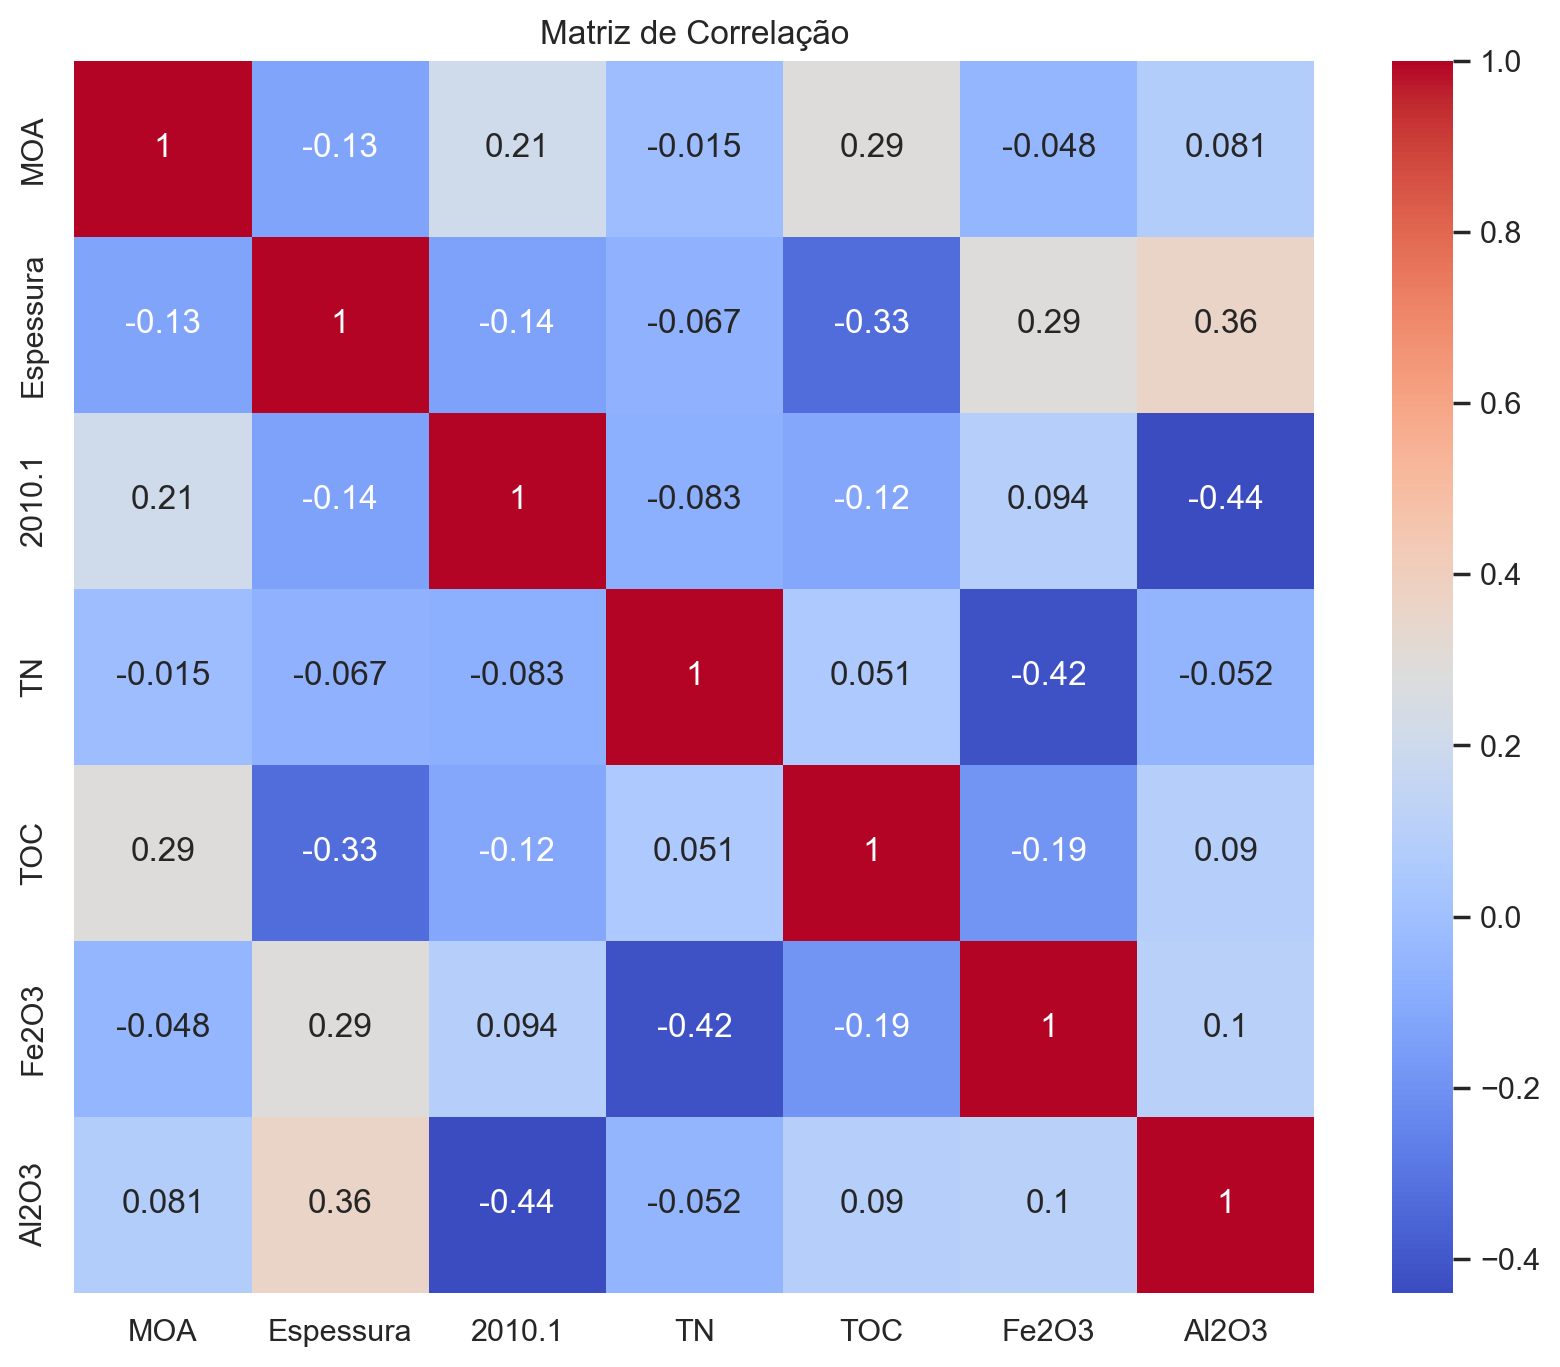

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title('Matriz de Correlação')
plt.show()


In [ ]:
df = pd.DataFrame(dados)

# Simular valores ausentes aleatórios
for col in ['U/Th', 'Fe2O3', 'Al2O3', 'TiO2', 'TS', 'TOC', 'TN', 'MOA']:
    df.loc[np.random.choice(df.index, 3, replace=False), col] = np.nan

# =======================================
# 🔧 Funções auxiliares
# =======================================

# Bootstrap
def bootstrap_fill(df, targets):
    df_fill = df.copy()
    for target in targets:
        known = df_fill[target].dropna().values
        missing = df_fill[target].isna()
        if missing.sum() > 0:
            df_fill.loc[missing, target] = np.random.choice(known, size=missing.sum(), replace=True)
    return df_fill

# IDW
def idw_predict(xy_known, values_known, xy_target, power=2):
    xy_known = np.asarray(xy_known, dtype=float)
    xy_target = np.asarray(xy_target, dtype=float)
    if xy_known.ndim == 1:
        xy_known = xy_known.reshape(-1, 1)
    if xy_target.ndim == 1:
        xy_target = xy_target.reshape(1, -1)
    # Ensure shapes are compatible for broadcasting
    distances = np.linalg.norm(xy_known - xy_target, axis=1)
    distances[distances == 0] = 1e-10
    weights = 1 / distances**power
    return np.sum(weights * values_known) / np.sum(weights)

def idw_fill(df, targets, coords):
    df_fill = df.copy()
    for target in targets:
        missing_idx = df_fill[df_fill[target].isna()].index
        xy_known = df_fill[df_fill[target].notna()][coords].values
        values_known = df_fill[df_fill[target].notna()][target].values

        for idx in missing_idx:
            point = df_fill.loc[idx, coords].values
            pred = idw_predict(xy_known, values_known, point)
            df_fill.at[idx, target] = pred
    return df_fill

# KNN
def knn_fill(df, targets, coords, n_neighbors=2):
    df_fill = df.copy()
    for target in targets:
        known = df_fill[df_fill[target].notna()]
        missing = df_fill[df_fill[target].isna()]

        if missing.shape[0] > 0:
            X_train = known[coords].values
            y_train = known[target].values
            X_test = missing[coords].values

            model = KNeighborsRegressor(n_neighbors=n_neighbors)
            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)

            df_fill.loc[missing.index, target] = y_pred
    return df_fill

# =======================================
# 🚀 Gerar as três tabelas preenchidas
# =======================================
coords = ['MOA-NF', 'OP-AL', 'OP-EQUI', '2010', '2010.1', 'Espessura', 'N. AMOSTRAS']
targets = ['U/Th', 'Fe2O3', 'Al2O3', 'TiO2', 'TS', 'TOC', 'TN', 'MOA']

df_bootstrap = bootstrap_fill(df, targets)
df_idw = idw_fill(df, targets, coords)
df_knn = knn_fill(df, targets, coords, n_neighbors=2)

# =======================================
# 📊 Combinar as tabelas lado a lado
# =======================================
def rename_columns(df, method):
    new_cols = {}
    for col in df.columns:
        if col in targets:
            new_cols[col] = f'{col}_{method}'
    return df.rename(columns=new_cols)

df_bootstrap = rename_columns(df_bootstrap, 'Bootstrap')
df_idw = rename_columns(df_idw, 'IDW')
df_knn = rename_columns(df_knn, 'KNN')

# Unir as tabelas
tabelas = df[['MOA-NF', 'OP-AL', 'OP-EQUI', '2010', '2010.1', 'Espessura', 'N. AMOSTRAS']].copy()

tabelas = tabelas.join([
    df_bootstrap[[f'{var}_Bootstrap' for var in targets]],
    df_idw[[f'{var}_IDW' for var in targets]],
    df_knn[[f'{var}_KNN' for var in targets]]
])

# =======================================
# 📜 Tabela final lado a lado
# =======================================
pd.set_option('display.max_columns', None)
print('\n📊 =================== TABELA PREENCHIDA LADO A LADO ===================\n')
print(tabelas.round(3).to_string(index=False))



📊 =================== TABELA PREENCHIDA LADO A LADO ===================

 MOA-NF  OP-AL  OP-EQUI  2010  2010.1  Espessura  N. AMOSTRAS  U/Th_Bootstrap  Fe2O3_Bootstrap  Al2O3_Bootstrap  TiO2_Bootstrap  TS_Bootstrap  TOC_Bootstrap  TN_Bootstrap  MOA_Bootstrap  U/Th_IDW  Fe2O3_IDW  Al2O3_IDW  TiO2_IDW  TS_IDW  TOC_IDW  TN_IDW  MOA_IDW  U/Th_KNN  Fe2O3_KNN  Al2O3_KNN  TiO2_KNN  TS_KNN  TOC_KNN  TN_KNN  MOA_KNN
     29      4        2     6      10        3.5            7            1.82             5.52            13.69            0.57          2.73           8.79          0.43          266.0     1.458      5.644     13.836     0.610   2.146   11.088   0.444  284.187     1.325      5.230     13.250     0.620   2.700   12.690   0.530    258.5
     27     10        3    12      25        5.5            9            1.17             5.52            13.69            0.55          1.49           7.69          0.46          289.0     1.464      5.785     13.993     0.607   2.201   10.719   0.4

In [ ]:
df_media = tabelas.copy()

for var in targets:
    cols = [f'{var}_Bootstrap', f'{var}_IDW', f'{var}_KNN']
    df_media[f'{var}_Média'] = df_media[cols].mean(axis=1)

# =======================================
# 📜 Visualizar a tabela final com média
# =======================================
pd.set_option('display.max_columns', None)
print('\n📊 =================== TABELA COM MÉDIA DOS TRÊS MÉTODOS ===================\n')
print(df_media.round(3).to_string(index=False))



📊 =================== TABELA COM MÉDIA DOS TRÊS MÉTODOS ===================

 MOA-NF  OP-AL  OP-EQUI  2010  2010.1  Espessura  N. AMOSTRAS  U/Th_Bootstrap  Fe2O3_Bootstrap  Al2O3_Bootstrap  TiO2_Bootstrap  TS_Bootstrap  TOC_Bootstrap  TN_Bootstrap  MOA_Bootstrap  U/Th_IDW  Fe2O3_IDW  Al2O3_IDW  TiO2_IDW  TS_IDW  TOC_IDW  TN_IDW  MOA_IDW  U/Th_KNN  Fe2O3_KNN  Al2O3_KNN  TiO2_KNN  TS_KNN  TOC_KNN  TN_KNN  MOA_KNN  U/Th_Média  Fe2O3_Média  Al2O3_Média  TiO2_Média  TS_Média  TOC_Média  TN_Média  MOA_Média
     29      4        2     6      10        3.5            7            1.82             5.52            13.69            0.57          2.73           8.79          0.43          266.0     1.458      5.644     13.836     0.610   2.146   11.088   0.444  284.187     1.325      5.230     13.250     0.620   2.700   12.690   0.530    258.5       1.534        5.465       13.592       0.600     2.525     10.856     0.468    269.562
     27     10        3    12      25        5.5            9 

In [ ]:
df = pd.DataFrame(dados)

# =======================================
# 🔧 Funções auxiliares
# =======================================
def bootstrap_fill(df, targets):
    df_fill = df.copy()
    for target in targets:
        known = df_fill[target].dropna().values
        missing = df_fill[target].isna()
        if missing.sum() > 0:
            df_fill.loc[missing, target] = np.random.choice(known, size=missing.sum(), replace=True)
    return df_fill

def idw_predict(xy_known, values_known, xy_target, power=2):
    xy_known = np.asarray(xy_known, dtype=float)
    xy_target = np.asarray(xy_target, dtype=float)
    if xy_known.ndim == 1:
        xy_known = xy_known.reshape(-1, 1)
    if xy_target.ndim == 1:
        xy_target = xy_target.reshape(1, -1)
    distances = np.linalg.norm(xy_known - xy_target, axis=1)
    distances[distances == 0] = 1e-10
    weights = 1 / distances**power
    return np.sum(weights * values_known) / np.sum(weights)

def idw_fill(df, targets, coords):
    df_fill = df.copy()
    for target in targets:
        missing_idx = df_fill[df_fill[target].isna()].index
        xy_known = df_fill[df_fill[target].notna()][coords].values
        values_known = df_fill[df_fill[target].notna()][target].values

        for idx in missing_idx:
            point = df_fill.loc[idx, coords].values
            pred = idw_predict(xy_known, values_known, point)
            df_fill.at[idx, target] = pred
    return df_fill

def knn_fill(df, targets, coords, n_neighbors=2):
    df_fill = df.copy()
    for target in targets:
        known = df_fill[df_fill[target].notna()]
        missing = df_fill[df_fill[target].isna()]

        if missing.shape[0] > 0:
            X_train = known[coords].values
            y_train = known[target].values
            X_test = missing[coords].values

            model = KNeighborsRegressor(n_neighbors=n_neighbors)
            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)

            df_fill.loc[missing.index, target] = y_pred
    return df_fill

# =======================================
# 🚀 Gerar as três tabelas preenchidas
# =======================================
coords = ['MOA-NF', 'OP-AL', 'OP-EQUI', '2010', '2010.1', 'Espessura', 'N. AMOSTRAS']
targets = ['U/Th', 'Fe2O3', 'Al2O3', 'TiO2', 'TS', 'TOC', 'TN', 'MOA']

df_bootstrap = bootstrap_fill(df, targets)
df_idw = idw_fill(df, targets, coords)
df_knn = knn_fill(df, targets, coords, n_neighbors=2)

# =======================================
# 📊 Combinar as tabelas lado a lado
# =======================================
def rename_columns(df, method):
    new_cols = {}
    for col in df.columns:
        if col in targets:
            new_cols[col] = f'{col}_{method}'
    return df.rename(columns=new_cols)

df_bootstrap = rename_columns(df_bootstrap, 'Bootstrap')
df_idw = rename_columns(df_idw, 'IDW')
df_knn = rename_columns(df_knn, 'KNN')

# Unir as tabelas incluindo Subniveis
tabelas = df[['Subniveis', 'MOA-NF', 'OP-AL', 'OP-EQUI', '2010', '2010.1', 'Espessura', 'N. AMOSTRAS']].copy()

tabelas = tabelas.join([
    df_bootstrap[[f'{var}_Bootstrap' for var in targets]],
    df_idw[[f'{var}_IDW' for var in targets]],
    df_knn[[f'{var}_KNN' for var in targets]]
])


# =======================================
# 🚀 Calcular a média dos três modelos
# =======================================
df_media = tabelas.copy()

for var in targets:
    cols = [f'{var}_Bootstrap', f'{var}_IDW', f'{var}_KNN']
    df_media[f'{var}_Média'] = df_media[cols].mean(axis=1)

# =======================================
# 📜 Visualizar a tabela final com média
# =======================================
pd.set_option('display.max_columns', None)
print('\n📊 =================== TABELA COM MÉDIA DOS TRÊS MÉTODOS ===================\n')
print(df_media.round(3).to_string(index=False))



📊 =================== TABELA COM MÉDIA DOS TRÊS MÉTODOS ===================

Subniveis  MOA-NF  OP-AL  OP-EQUI  2010  2010.1  Espessura  N. AMOSTRAS  U/Th_Bootstrap  Fe2O3_Bootstrap  Al2O3_Bootstrap  TiO2_Bootstrap  TS_Bootstrap  TOC_Bootstrap  TN_Bootstrap  MOA_Bootstrap  U/Th_IDW  Fe2O3_IDW  Al2O3_IDW  TiO2_IDW  TS_IDW  TOC_IDW  TN_IDW  MOA_IDW  U/Th_KNN  Fe2O3_KNN  Al2O3_KNN  TiO2_KNN  TS_KNN  TOC_KNN  TN_KNN  MOA_KNN  U/Th_Média  Fe2O3_Média  Al2O3_Média  TiO2_Média  TS_Média  TOC_Média  TN_Média  MOA_Média
       8E      29      4        2     6      10        3.5            7            1.81             7.41            14.13            0.63          2.62          12.97          0.29          338.0     1.491      5.788     13.918     0.610   2.379   10.706   0.421  264.359     1.495      5.230     13.250     0.620   2.175   12.690   0.530    220.5       1.599        6.143       13.766       0.620     2.391     12.122     0.414    274.286
       8D      27     10        3    12   

In [ ]:
# ==========================
# 🔧 Funções de avaliação
# ==========================
def evaluate(true, pred):
    rmse = np.sqrt(mean_squared_error(true, pred))
    mae = mean_absolute_error(true, pred)
    r2 = r2_score(true, pred)
    return rmse, mae, r2

# ==========================
# 🚀 Validação Bootstrap
# ==========================
def bootstrap_validation(df, target, test_fraction=0.3):
    df_temp = df.copy()
    known = df_temp[df_temp[target].notna()]
    n_test = max(1, int(len(known) * test_fraction))
    test_idx = np.random.choice(known.index, size=n_test, replace=False)

    true_values = df_temp.loc[test_idx, target].values
    df_temp.loc[test_idx, target] = np.nan

    filled = np.random.choice(known.drop(index=test_idx)[target].dropna().values, size=n_test, replace=True)

    rmse, mae, r2 = evaluate(true_values, filled)
    return rmse, mae, r2

# ==========================
# 🚀 Validação IDW
# ==========================
def idw_predict(xy_known, values_known, xy_target, power=2):
    xy_known = np.asarray(xy_known, dtype=float)
    xy_target = np.asarray(xy_target, dtype=float)
    distances = np.linalg.norm(xy_known - xy_target, axis=1)
    distances[distances == 0] = 1e-10
    weights = 1 / distances ** power
    return np.sum(weights * values_known) / np.sum(weights)

def idw_validation(df, target, coords, test_fraction=0.3):
    df_temp = df.copy()
    known = df_temp[df_temp[target].notna()]
    n_test = max(1, int(len(known) * test_fraction))
    test_idx = np.random.choice(known.index, size=n_test, replace=False)

    true_values = df_temp.loc[test_idx, target].values
    xy_known = known.drop(index=test_idx)[coords].values
    values_known = known.drop(index=test_idx)[target].values

    xy_test = df_temp.loc[test_idx, coords].values
    predictions = []

    for point in xy_test:
        pred = idw_predict(xy_known, values_known, point)
        predictions.append(pred)

    rmse, mae, r2 = evaluate(true_values, predictions)
    return rmse, mae, r2

# ==========================
# 🚀 Validação KNN
# ==========================
def knn_validation(df, target, coords, n_neighbors=2, test_fraction=0.3):
    df_temp = df.copy()
    known = df_temp[df_temp[target].notna()]
    n_test = max(1, int(len(known) * test_fraction))
    test_idx = np.random.choice(known.index, size=n_test, replace=False)

    true_values = df_temp.loc[test_idx, target].values

    X_train = known.drop(index=test_idx)[coords].values
    y_train = known.drop(index=test_idx)[target].values
    X_test = df_temp.loc[test_idx, coords].values

    model = KNeighborsRegressor(n_neighbors=n_neighbors)
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    rmse, mae, r2 = evaluate(true_values, predictions)
    return rmse, mae, r2

# ==========================
# 🚀 Rodar validação para todos os geoquímicos
# ==========================
coords = ['MOA-NF', 'OP-AL', 'OP-EQUI', '2010', '2010.1', 'Espessura', 'N. AMOSTRAS']
targets = ['U/Th', 'Fe2O3', 'Al2O3', 'TiO2', 'TS', 'TOC', 'TN', 'MOA']

resultados = []

for var in targets:
    print(f'\n📊 Validação para {var}')

    rmse_b, mae_b, r2_b = bootstrap_validation(df, var)
    print(f'Bootstrap — RMSE: {rmse_b:.3f}, MAE: {mae_b:.3f}, R2: {r2_b:.3f}')

    rmse_idw, mae_idw, r2_idw = idw_validation(df, var, coords)
    print(f'IDW       — RMSE: {rmse_idw:.3f}, MAE: {mae_idw:.3f}, R2: {r2_idw:.3f}')

    rmse_knn, mae_knn, r2_knn = knn_validation(df, var, coords, n_neighbors=2)
    print(f'KNN       — RMSE: {rmse_knn:.3f}, MAE: {mae_knn:.3f}, R2: {r2_knn:.3f}')

    resultados.extend([
        {'Variável': var, 'Método': 'Bootstrap', 'RMSE': rmse_b, 'MAE': mae_b, 'R2': r2_b},
        {'Variável': var, 'Método': 'IDW', 'RMSE': rmse_idw, 'MAE': mae_idw, 'R2': r2_idw},
        {'Variável': var, 'Método': 'KNN', 'RMSE': rmse_knn, 'MAE': mae_knn, 'R2': r2_knn},
    ])

# ==========================
# 📜 Resultados consolidados
# ==========================
resultados_df = pd.DataFrame(resultados)

print('\n📊 =================== RESULTADOS DA VALIDAÇÃO ===================\n')
print(resultados_df.round(3).to_string(index=False))



📊 Validação para U/Th
Bootstrap — RMSE: 0.690, MAE: 0.633, R2: -4.356
IDW       — RMSE: 0.152, MAE: 0.117, R2: -0.549
KNN       — RMSE: 0.456, MAE: 0.298, R2: -0.696

📊 Validação para Fe2O3
Bootstrap — RMSE: 1.545, MAE: 1.510, R2: -16.664
IDW       — RMSE: 0.806, MAE: 0.768, R2: -1.017
KNN       — RMSE: 0.579, MAE: 0.537, R2: 0.193

📊 Validação para Al2O3
Bootstrap — RMSE: 1.143, MAE: 1.140, R2: -12.579
IDW       — RMSE: 0.591, MAE: 0.509, R2: -1.493
KNN       — RMSE: 0.720, MAE: 0.678, R2: -1.088

📊 Validação para TiO2
Bootstrap — RMSE: 0.024, MAE: 0.020, R2: -1.077
IDW       — RMSE: 0.041, MAE: 0.040, R2: -0.119
KNN       — RMSE: 0.013, MAE: 0.012, R2: 0.406

📊 Validação para TS
Bootstrap — RMSE: 1.589, MAE: 1.547, R2: -5.639
IDW       — RMSE: 1.109, MAE: 0.982, R2: -0.230
KNN       — RMSE: 0.936, MAE: 0.853, R2: -8.834

📊 Validação para TOC
Bootstrap — RMSE: 3.193, MAE: 2.633, R2: -64.769
IDW       — RMSE: 0.883, MAE: 0.828, R2: -8.237
KNN       — RMSE: 1.487, MAE: 1.355, R2: 0.098

✔️ U/Th preenchido usando Bootstrap
✔️ Fe2O3 preenchido usando IDW
✔️ Al2O3 preenchido usando IDW
✔️ TiO2 preenchido usando IDW
✔️ TS preenchido usando Bootstrap
✔️ TOC preenchido usando Bootstrap
✔️ TN preenchido usando KNN
✔️ MOA preenchido usando IDW
✅ Tabela exportada para "Tabela_Final_Preenchida.xlsx".


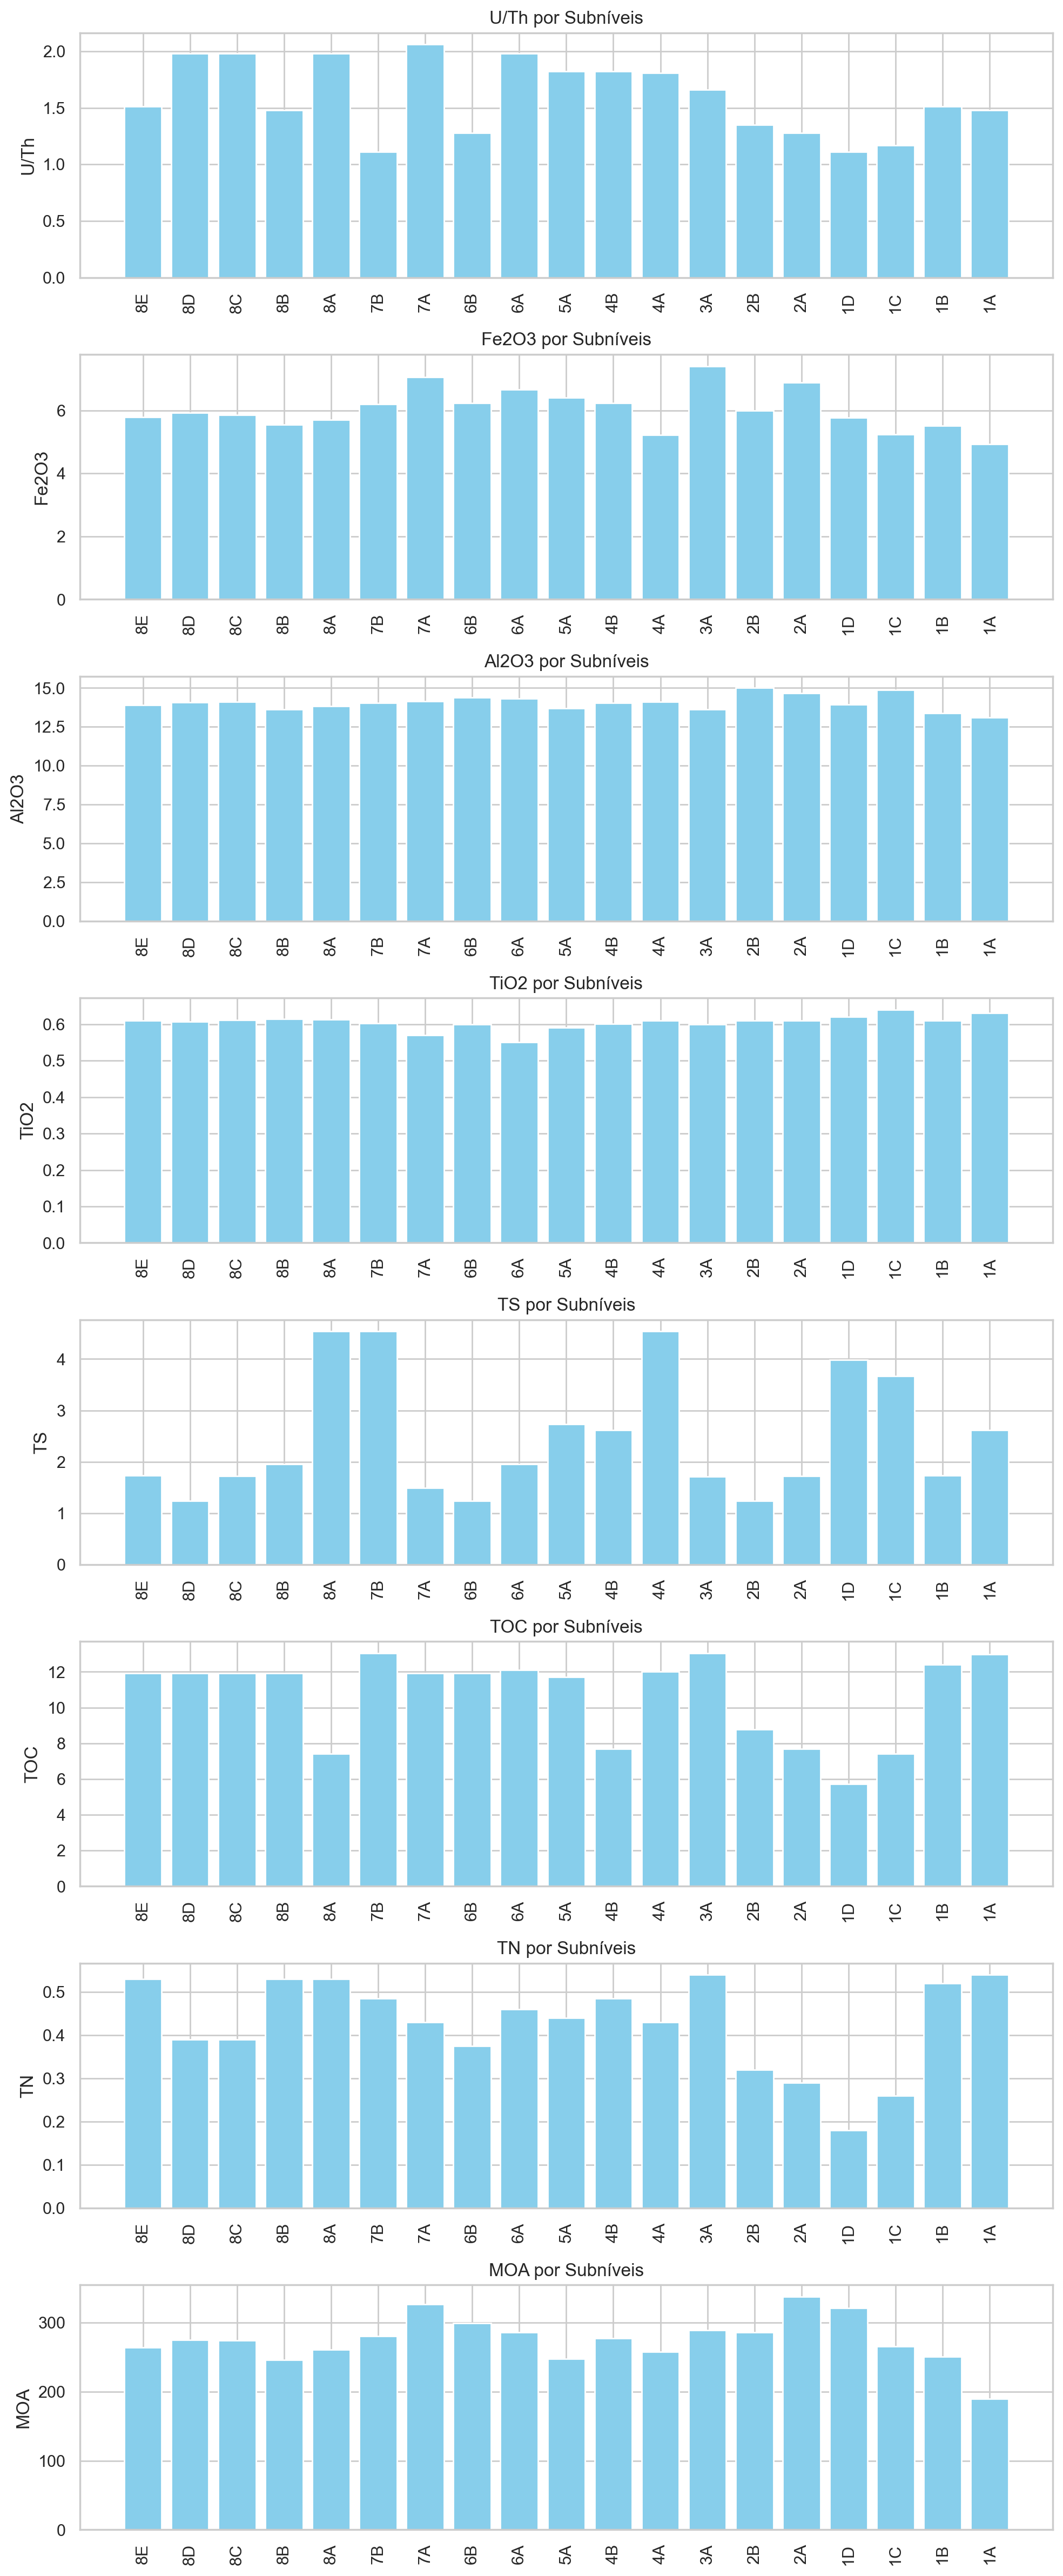

✅ Gráfico salvo como "Perfis_por_Subniveis.png".


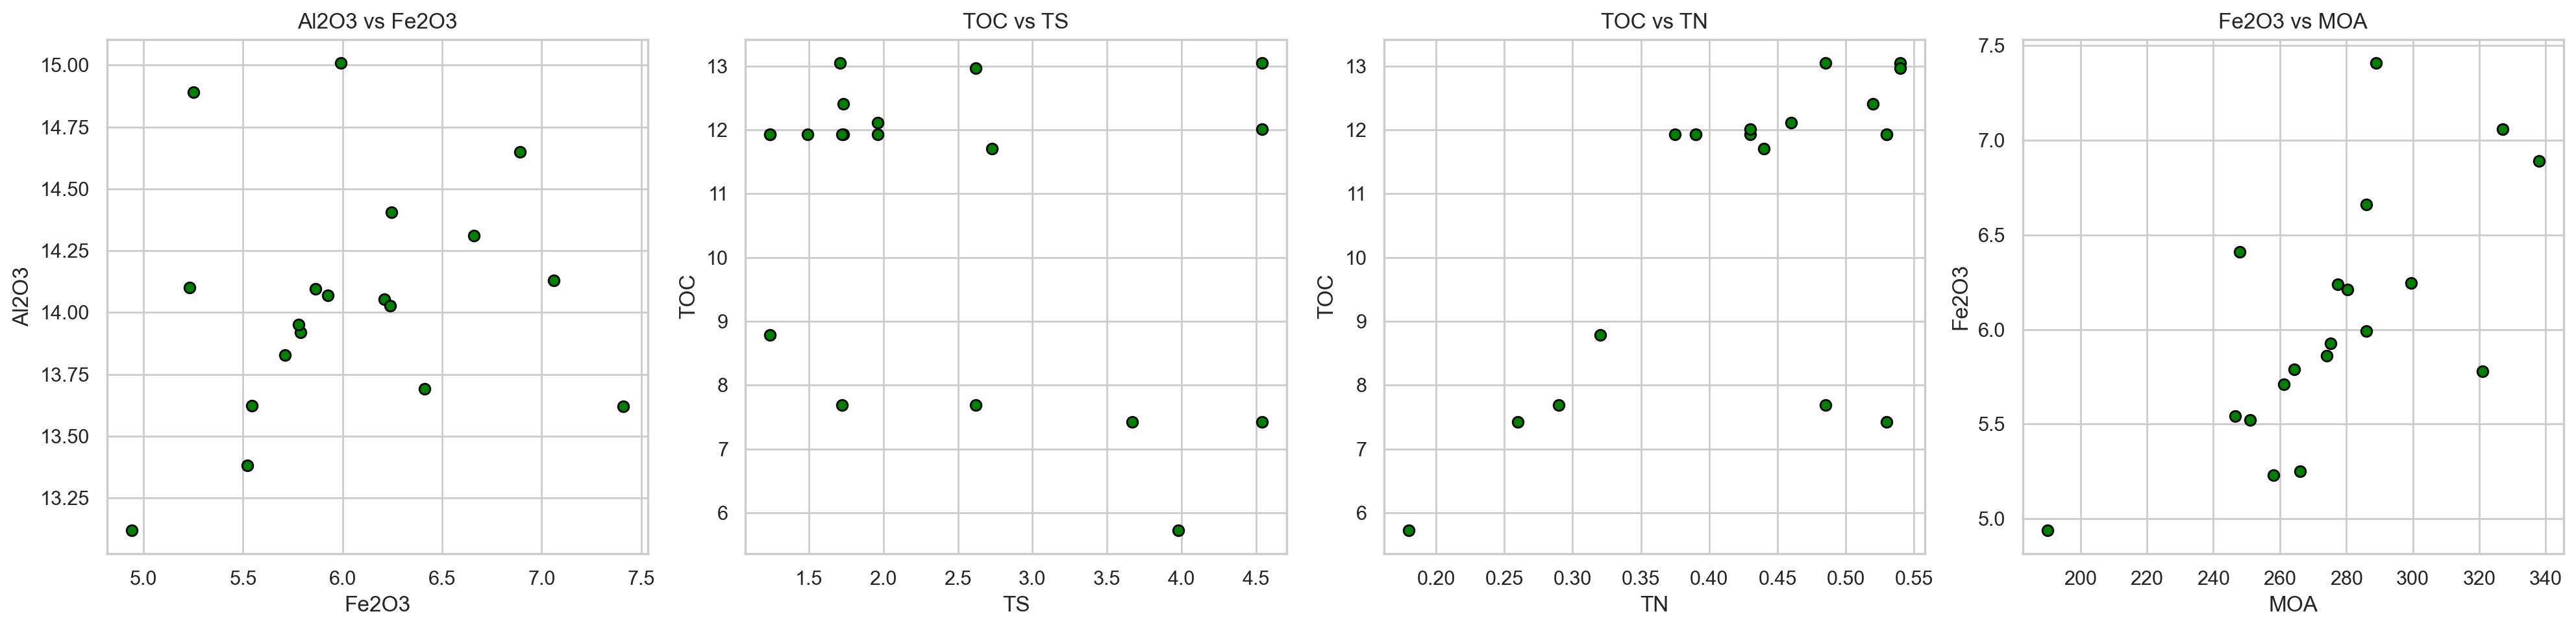

✅ Scatter plot salvo como "Scatter_Comparacoes.png".


In [ ]:
df = pd.DataFrame(dados)

# ===========================
# 🔧 Funções de preenchimento
# ===========================
def bootstrap_fill(df, target):
    known = df[target].dropna().values
    missing = df[target].isna()
    if missing.sum() > 0:
        df.loc[missing, target] = np.random.choice(known, size=missing.sum(), replace=True)
    return df

def idw_predict(xy_known, values_known, xy_target, power=2):
    xy_known = np.asarray(xy_known, dtype=float)
    xy_target = np.asarray(xy_target, dtype=float)
    distances = np.linalg.norm(xy_known - xy_target, axis=1)
    distances[distances == 0] = 1e-10
    weights = 1 / distances**power
    return np.sum(weights * values_known) / np.sum(weights)

def idw_fill(df, target, coords):
    missing_idx = df[df[target].isna()].index
    xy_known = df[df[target].notna()][coords].values
    values_known = df[df[target].notna()][target].values

    for idx in missing_idx:
        point = df.loc[idx, coords].values
        pred = idw_predict(xy_known, values_known, point)
        df.at[idx, target] = pred
    return df

def knn_fill(df, target, coords, n_neighbors=2):
    known = df[df[target].notna()]
    missing = df[df[target].isna()]

    if missing.shape[0] > 0:
        X_train = known[coords].values
        y_train = known[target].values
        X_test = missing[coords].values

        model = KNeighborsRegressor(n_neighbors=n_neighbors)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        df.loc[missing.index, target] = y_pred
    return df

# ===========================
# 🚦 Pipeline de seleção automática dos melhores modelos
# ===========================
# 🔥 Baseado na sua validação anterior
best_methods = {
    'U/Th': 'Bootstrap',
    'Fe2O3': 'IDW',
    'Al2O3': 'IDW',
    'TiO2': 'IDW',
    'TS': 'Bootstrap',
    'TOC': 'Bootstrap',  # Presumindo comportamento similar ao TS
    'TN': 'KNN',
    'MOA': 'IDW'
}

# ===========================
# 🚀 Executar pipeline
# ===========================
coords = ['MOA-NF', 'OP-AL', 'OP-EQUI', '2010', '2010.1', 'Espessura', 'N. AMOSTRAS']
targets = ['U/Th', 'Fe2O3', 'Al2O3', 'TiO2', 'TS', 'TOC', 'TN', 'MOA']

df_filled = df.copy()

for var in targets:
    method = best_methods.get(var)

    if method == 'Bootstrap':
        df_filled = bootstrap_fill(df_filled, var)

    elif method == 'IDW':
        df_filled = idw_fill(df_filled, var, coords)

    elif method == 'KNN':
        df_filled = knn_fill(df_filled, var, coords)

    print(f'✔️ {var} preenchido usando {method}')

# ===========================
# 📜 Exportar tabela final
# ===========================
df_filled.to_excel('Tabela_Final_Preenchida.xlsx', index=False)
print('✅ Tabela exportada para "Tabela_Final_Preenchida.xlsx".')

# ===========================
# 📈 Plotar gráficos por Subníveis
# ===========================
plt.rcParams.update({'figure.max_open_warning': 0})
fig, axs = plt.subplots(len(targets), 1, figsize=(10, len(targets)*3))

for i, var in enumerate(targets):
    axs[i].bar(df_filled['Subniveis'], df_filled[var], color='skyblue')
    axs[i].set_title(f'{var} por Subníveis')
    axs[i].set_ylabel(var)
    axs[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.savefig('Perfis_por_Subniveis.png', dpi=300)
plt.show()
print('✅ Gráfico salvo como "Perfis_por_Subniveis.png".')

# ===========================
# 📈 Scatter plot comparando variáveis
# ===========================
pairs = [('Fe2O3', 'Al2O3'), ('TS', 'TOC'), ('TN', 'TOC'), ('MOA', 'Fe2O3')]

fig, axs = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 5))

for i, (x, y) in enumerate(pairs):
    axs[i].scatter(df_filled[x], df_filled[y], color='green', edgecolor='black')
    axs[i].set_xlabel(x)
    axs[i].set_ylabel(y)
    axs[i].set_title(f'{y} vs {x}')

plt.tight_layout()
plt.savefig('Scatter_Comparacoes.png', dpi=300)
plt.show()
print('✅ Scatter plot salvo como "Scatter_Comparacoes.png".')


In [ ]:
df = pd.DataFrame(df_filled)
colunas_plotaveis = ["U/Th", "Fe2O3", "Al2O3", "TiO2", "TS", "TOC", "TN", "MOA",
                     "MOA-NF", "OP-AL", "OP-EQUI", "Coleta 2010", "Coleta 2016", "contagem", "Espessura"]

# Criação dos dropdowns
dropdown1 = widgets.Dropdown(
    options=colunas_plotaveis,
    value='U/Th',
    description='Parâmetro 1:',
    layout=widgets.Layout(width='250px')
)

dropdown2 = widgets.Dropdown(
    options=colunas_plotaveis,
    value='Fe2O3',
    description='Parâmetro 2:',
    layout=widgets.Layout(width='250px')
)
dropdown3 = widgets.Dropdown(
    options=colunas_plotaveis,
    value='Al2O3',
    description='Parâmetro 3:',
    layout=widgets.Layout(width='250px')
)
dropdown4 = widgets.Dropdown(
    options=colunas_plotaveis,
    value='TiO2',
    description='Parâmetro 4:',
    layout=widgets.Layout(width='250px')
)

# Função para gerar um gráfico individual
def gerar_grafico(coluna, cor='blue'):
    fig = px.line(
        df,
        x=coluna,
        y='Subniveis',
        height=1000,
        width=500,
        markers=True,
        title=f"{coluna}"
    )
    fig.update_yaxes(autorange="reversed", tickmode='array', tickvals=df['Subniveis'], ticktext=df['Subniveis'])
    fig.update_traces(marker=dict(size=10, line=dict(width=2, color='DarkSlateGrey')), line=dict(color=cor))
    media = df[coluna].mean()
    fig.add_vline(x=media, line_width=2, line_dash="dash", line_color="red")
    fig.add_annotation(xref="paper", yref="paper", x=0.95, y=0.95, text=f"Média: {media:.2f}",
                       showarrow=False, font=dict(size=14), bgcolor="white",
                       bordercolor="black", borderwidth=1, borderpad=4)
    fig.add_annotation(xref="paper", yref="paper", x=0.95, y=0.90,
                       text=f"Máx: {df[coluna].max():.2f}", showarrow=False,
                       font=dict(size=14), bgcolor="white", bordercolor="black", borderwidth=1, borderpad=4)
    fig.add_annotation(xref="paper", yref="paper", x=0.95, y=0.85,
                       text=f"Mín: {df[coluna].min():.2f}", showarrow=False,
                       font=dict(size=14), bgcolor="white", bordercolor="black", borderwidth=1, borderpad=4)
    return fig

# Outputs
output1 = Output()
output2 = Output()
output3 = Output()
output4 = Output()

ui = HBox([dropdown1, dropdown2, dropdown3, dropdown4])
display(ui)
display(HBox([output1, output2, output3, output4]))  # lado a lado

def atualizar(col1, col2, col3, col4):
    with output1:
        output1.clear_output()
        fig1 = gerar_grafico(col1, cor='blue')

    with output2:
        output2.clear_output()
        fig2 = gerar_grafico(col2, cor='green')

    with output3:
        output3.clear_output()
        fig3 = gerar_grafico(col3, cor='purple')

    with output4:
        output4.clear_output()
        fig4 = gerar_grafico(col4, cor='orange')


interactive_output(atualizar, {'col1': dropdown1, 'col2': dropdown2, 'col3': dropdown3, 'col4': dropdown4})


app = dash.Dash( __name__, external_stylesheets=[dbc.themes.BOOTSTRAP])
app.title = "Gráficos Interativos"
app.layout = html.Div([
    dbc.Row([
        dbc.Col([
            dcc.Dropdown(
                id='dropdown1',
                options=[{'label': col, 'value': col} for col in colunas_plotaveis],
                value='U/Th',
                style={'width': '50%'}
            ),
            dcc.Graph(id='graph1')
        ], width=3),
        dbc.Col([
            dcc.Dropdown(
                id='dropdown2',
                options=[{'label': col, 'value': col} for col in colunas_plotaveis],
                value='Fe2O3',
                style={'width': '50%'}
            ),
            dcc.Graph(id='graph2')
        ], width=3),
        dbc.Col([
            dcc.Dropdown(
                id='dropdown3',
                options=[{'label': col, 'value': col} for col in colunas_plotaveis],
                value='Al2O3',
                style={'width': '50%'}
            ),
            dcc.Graph(id='graph3')
        ], width=3),
        dbc.Col([
            dcc.Dropdown(
                id='dropdown4',
                options=[{'label': col, 'value': col} for col in colunas_plotaveis],
                value='TiO2',
                style={'width': '50%'}
            ),
            dcc.Graph(id='graph4')
        ], width=3)
    ])
])

@app.callback(
    [dash.dependencies.Output('graph1', 'figure'),
     dash.dependencies.Output('graph2', 'figure'),
     dash.dependencies.Output('graph3', 'figure'),
     dash.dependencies.Output('graph4', 'figure')],
    [dash.dependencies.Input('dropdown1', 'value'),
     dash.dependencies.Input('dropdown2', 'value'),
     dash.dependencies.Input('dropdown3', 'value'),
     dash.dependencies.Input('dropdown4', 'value')]
)
def update_graphs(col1, col2, col3, col4):
    fig1 = gerar_grafico(col1, cor='blue')
    fig2 = gerar_grafico(col2, cor='green')
    fig3 = gerar_grafico(col3, cor='purple')
    fig4 = gerar_grafico(col4, cor='orange')
    return fig1, fig2, fig3, fig4
if __name__ == '__main__':
    app.run(debug=True, port=8051)

In [ ]:
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
import numpy as np

loo = LeaveOneOut()

def loo_validate(model, X, y):
    y_true, y_pred = [], []
    for train_index, test_index in loo.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        model.fit(X_train, y_train)
        y_p = model.predict(X_test)

        y_true.append(y_test[0])
        y_pred.append(y_p[0])

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return rmse, mae, r2

# Exemplo para MOA
X = df[coords].values
y = df['MOA'].values

model = DecisionTreeRegressor(max_depth=3, min_samples_split=4, random_state=42)

rmse, mae, r2 = loo_validate(model, X, y)

print(f"📊 Decision Tree Validado - MOA")
print(f"RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")


📊 Decision Tree Validado - MOA
RMSE: 43.9929, MAE: 35.7640, R²: -0.8504


In [ ]:
from sklearn.linear_model import Lasso


df = pd.DataFrame(dados)

coords = ['MOA-NF', 'OP-AL', 'OP-EQUI', '2010', '2010.1', 'Espessura', 'N. AMOSTRAS']
targets = ['U/Th', 'Fe2O3', 'Al2O3', 'TiO2', 'TS', 'TOC', 'TN', 'MOA']

# ==========================
# Mapear os melhores modelos
# ==========================
melhores_modelos = {
    'U/Th': Lasso(alpha=0.01, max_iter=10000),
    'Fe2O3': RandomForestRegressor(n_estimators=300, max_depth=4, random_state=42),
    'Al2O3': GradientBoostingRegressor(n_estimators=300, max_depth=3, random_state=42),
    'TiO2': RandomForestRegressor(n_estimators=300, max_depth=4, random_state=42),
    'TS': RandomForestRegressor(n_estimators=300, max_depth=4, random_state=42),
    'TOC': RandomForestRegressor(n_estimators=300, max_depth=4, random_state=42),
    'TN': RandomForestRegressor(n_estimators=300, max_depth=4, random_state=42),
    'MOA': GradientBoostingRegressor(n_estimators=300, max_depth=3, random_state=42)
}

# ==========================
# 🚀 Pipeline de preenchimento
# ==========================
df_preenchido = df.copy()

for var in targets:
    modelo = melhores_modelos[var]
    df_model = df_preenchido.dropna(subset=[var])

    X_train = df_model[coords].values
    y_train = df_model[var].values

    modelo.fit(X_train, y_train)

    # Identificar linhas com valores ausentes
    missing_idx = df_preenchido[df_preenchido[var].isna()].index

    if len(missing_idx) > 0:
        X_pred = df_preenchido.loc[missing_idx, coords].values
        y_pred = modelo.predict(X_pred)

        df_preenchido.loc[missing_idx, var] = y_pred

    print(f'✔️ {var} preenchido com {modelo.__class__.__name__}')

# ==========================
# 💾 Exportar para Excel
# ==========================
df_preenchido.to_excel('Tabela_Preenchida_Final.xlsx', index=False)

print('\n✅ Tabela preenchida salva como "Tabela_Preenchida_Final.xlsx".')



✔️ U/Th preenchido com Lasso
✔️ Fe2O3 preenchido com RandomForestRegressor
✔️ Al2O3 preenchido com GradientBoostingRegressor
✔️ TiO2 preenchido com RandomForestRegressor
✔️ TS preenchido com RandomForestRegressor
✔️ TOC preenchido com RandomForestRegressor
✔️ TN preenchido com RandomForestRegressor
✔️ MOA preenchido com GradientBoostingRegressor

✅ Tabela preenchida salva como "Tabela_Preenchida_Final.xlsx".


In [ ]:
df = pd.DataFrame(dados)

coords = ['MOA-NF', 'OP-AL', 'OP-EQUI', '2010', '2010.1', 'Espessura', 'N. AMOSTRAS']
targets = ['U/Th', 'Fe2O3', 'Al2O3', 'TiO2', 'TS', 'TOC', 'TN', 'MOA']

# ==========================
# Função para Rede Neural
# ==========================
def build_nn(input_shape):
    model = keras.Sequential([
        layers.Input(shape=(input_shape,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# ==========================
# Validação LOOCV
# ==========================
def loo_validate(model, X, y, is_dl=False):
    loo = LeaveOneOut()
    y_true, y_pred = [], []

    scaler_X = StandardScaler().fit(X)
    X_scaled = scaler_X.transform(X)

    scaler_y = StandardScaler().fit(y.reshape(-1, 1))
    y_scaled = scaler_y.transform(y.reshape(-1, 1))

    for train_idx, test_idx in loo.split(X):
        X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
        y_train, y_test = y_scaled[train_idx], y_scaled[test_idx]

        if is_dl:
            model_dl = build_nn(X.shape[1])
            model_dl.fit(X_train, y_train, epochs=300, verbose=0)
            y_p = model_dl.predict(X_test)
        else:
            model.fit(X_train, y_train.ravel())
            y_p = model.predict(X_test).reshape(-1, 1)

        y_true.append(y_test[0])
        y_pred.append(y_p[0][0])

    y_true = scaler_y.inverse_transform(np.array(y_true).reshape(-1,1)).flatten()
    y_pred = scaler_y.inverse_transform(np.array(y_pred).reshape(-1,1)).flatten()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return rmse, mae, r2

# ==========================
# Pipeline Híbrido
# ==========================
resultados = []
df_preenchido = df.copy()

for var in targets:
    df_model = df.dropna(subset=[var])
    X = df_model[coords].values
    y = df_model[var].values

    modelos = {
        'RandomForest': RandomForestRegressor(n_estimators=300, max_depth=4, random_state=42),
        'GradientBoosting': GradientBoostingRegressor(n_estimators=300, max_depth=3, random_state=42),
        'DeepLearning': 'DL'  # Placeholder para Deep Learning
    }

    metricas = []

    for nome, modelo in modelos.items():
        if nome == 'DeepLearning':
            rmse, mae, r2 = loo_validate(None, X, y, is_dl=True)
        else:
            rmse, mae, r2 = loo_validate(modelo, X, y, is_dl=False)

        metricas.append({
            'Variável': var,
            'Modelo': nome,
            'RMSE': rmse,
            'MAE': mae,
            'R2': r2
        })

    metricas_df = pd.DataFrame(metricas)
    melhor_modelo = metricas_df.loc[metricas_df['RMSE'].idxmin()]

    print(f'✔️ {var} — Melhor modelo: {melhor_modelo["Modelo"]} (RMSE={melhor_modelo["RMSE"]:.3f})')

    # Aplicar preenchimento com o melhor modelo
    df_temp = df_preenchido.dropna(subset=[var])
    X_train = df_temp[coords].values
    y_train = df_temp[var].values

    scaler_X = StandardScaler().fit(X_train)
    X_scaled = scaler_X.transform(X_train)

    scaler_y = StandardScaler().fit(y_train.reshape(-1, 1))
    y_scaled = scaler_y.transform(y_train.reshape(-1, 1))

    missing_idx = df_preenchido[df_preenchido[var].isna()].index

    if len(missing_idx) > 0:
        X_missing = scaler_X.transform(df_preenchido.loc[missing_idx, coords].values)

        if melhor_modelo["Modelo"] == 'DeepLearning':
            model_dl = build_nn(X_train.shape[1])
            model_dl.fit(X_scaled, y_scaled, epochs=500, verbose=0)
            y_pred_scaled = model_dl.predict(X_missing)
        else:
            model = modelos[melhor_modelo["Modelo"]]
            model.fit(X_scaled, y_scaled.ravel())
            y_pred_scaled = model.predict(X_missing).reshape(-1, 1)

        y_pred = scaler_y.inverse_transform(y_pred_scaled)
        df_preenchido.loc[missing_idx, var] = y_pred.flatten()

    metricas_df['Melhor_Modelo'] = metricas_df['Modelo'] == melhor_modelo['Modelo']
    resultados.append(metricas_df)

# ==========================
# 📊 Consolidar resultados
# ==========================
resultados_df = pd.concat(resultados, ignore_index=True)

# ==========================
# 💾 Exportar
# ==========================
resultados_df.to_excel('Metricas_Pipeline_Hibrido.xlsx', index=False)
df_preenchido.to_excel('Tabela_Preenchida_Pipeline_Hibrido.xlsx', index=False)

print('Pipeline híbrido concluído e salvo:')
print('-  Tabela final: Tabela_Preenchida_Pipeline_Hibrido.xlsx')
print('-  Métricas dos modelos: Metricas_Pipeline_Hibrido.xlsx')



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
✔️ U/Th — Melhor modelo: RandomForest (RMSE=0.400)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
✔️ Fe2O3 — Melhor modelo: RandomForest (RMSE=0.828)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━

In [ ]:
df = pd.DataFrame(df_preenchido)

colunas_plotaveis = ["U/Th", "Fe2O3", "Al2O3", "TiO2", "TS", "TOC", "TN", "MOA",
                     "MOA-NF", "OP-AL", "OP-EQUI", "Coleta 2010", "Coleta 2016", "contagem", "Espessura"]

# Criação dos dropdowns
dropdown1 = widgets.Dropdown(
    options=colunas_plotaveis,
    value='U/Th',
    description='Parâmetro 1:',
    layout=widgets.Layout(width='250px')
)

dropdown2 = widgets.Dropdown(
    options=colunas_plotaveis,
    value='Fe2O3',
    description='Parâmetro 2:',
    layout=widgets.Layout(width='250px')
)
dropdown3 = widgets.Dropdown(
    options=colunas_plotaveis,
    value='Al2O3',
    description='Parâmetro 3:',
    layout=widgets.Layout(width='250px')
)
dropdown4 = widgets.Dropdown(
    options=colunas_plotaveis,
    value='TiO2',
    description='Parâmetro 4:',
    layout=widgets.Layout(width='250px')
)

# Função para gerar um gráfico individual
def gerar_grafico(coluna, cor='blue'):
    fig = px.line(
        df,
        x=coluna,
        y='Subniveis',
        height=1000,
        width=500,
        markers=True,
        title=f"{coluna}"
    )
    fig.update_yaxes(autorange="reversed", tickmode='array', tickvals=df['Subniveis'], ticktext=df['Subniveis'])
    fig.update_traces(marker=dict(size=10, line=dict(width=2, color='DarkSlateGrey')), line=dict(color=cor))
    media = df[coluna].mean()
    fig.add_vline(x=media, line_width=2, line_dash="dash", line_color="red")
    fig.add_annotation(xref="paper", yref="paper", x=0.95, y=0.95, text=f"Média: {media:.2f}",
                       showarrow=False, font=dict(size=14), bgcolor="white",
                       bordercolor="black", borderwidth=1, borderpad=4)
    fig.add_annotation(xref="paper", yref="paper", x=0.95, y=0.90,
                       text=f"Máx: {df[coluna].max():.2f}", showarrow=False,
                       font=dict(size=14), bgcolor="white", bordercolor="black", borderwidth=1, borderpad=4)
    fig.add_annotation(xref="paper", yref="paper", x=0.95, y=0.85,
                       text=f"Mín: {df[coluna].min():.2f}", showarrow=False,
                       font=dict(size=14), bgcolor="white", bordercolor="black", borderwidth=1, borderpad=4)
    return fig

# Outputs
output1 = Output()
output2 = Output()
output3 = Output()
output4 = Output()

ui = HBox([dropdown1, dropdown2, dropdown3, dropdown4])
display(ui)
display(HBox([output1, output2, output3, output4]))  # lado a lado

def atualizar(col1, col2, col3, col4):
    with output1:
        output1.clear_output()
        fig1 = gerar_grafico(col1, cor='blue')

    with output2:
        output2.clear_output()
        fig2 = gerar_grafico(col2, cor='green')

    with output3:
        output3.clear_output()
        fig3 = gerar_grafico(col3, cor='purple')

    with output4:
        output4.clear_output()
        fig4 = gerar_grafico(col4, cor='orange')


interactive_output(atualizar, {'col1': dropdown1, 'col2': dropdown2, 'col3': dropdown3, 'col4': dropdown4})


app = dash.Dash( __name__, external_stylesheets=[dbc.themes.BOOTSTRAP])
app.title = "Gráficos Interativos"
app.layout = html.Div([
    dbc.Row([
        dbc.Col([
            dcc.Dropdown(
                id='dropdown1',
                options=[{'label': col, 'value': col} for col in colunas_plotaveis],
                value='U/Th',
                style={'width': '50%'}
            ),
            dcc.Graph(id='graph1')
        ], width=3),
        dbc.Col([
            dcc.Dropdown(
                id='dropdown2',
                options=[{'label': col, 'value': col} for col in colunas_plotaveis],
                value='Fe2O3',
                style={'width': '50%'}
            ),
            dcc.Graph(id='graph2')
        ], width=3),
        dbc.Col([
            dcc.Dropdown(
                id='dropdown3',
                options=[{'label': col, 'value': col} for col in colunas_plotaveis],
                value='Al2O3',
                style={'width': '50%'}
            ),
            dcc.Graph(id='graph3')
        ], width=3),
        dbc.Col([
            dcc.Dropdown(
                id='dropdown4',
                options=[{'label': col, 'value': col} for col in colunas_plotaveis],
                value='TiO2',
                style={'width': '50%'}
            ),
            dcc.Graph(id='graph4')
        ], width=3)
    ])
])

@app.callback(
    [dash.dependencies.Output('graph1', 'figure'),
     dash.dependencies.Output('graph2', 'figure'),
     dash.dependencies.Output('graph3', 'figure'),
     dash.dependencies.Output('graph4', 'figure')],
    [dash.dependencies.Input('dropdown1', 'value'),
     dash.dependencies.Input('dropdown2', 'value'),
     dash.dependencies.Input('dropdown3', 'value'),
     dash.dependencies.Input('dropdown4', 'value')]
)
def update_graphs(col1, col2, col3, col4):
    fig1 = gerar_grafico(col1, cor='blue')
    fig2 = gerar_grafico(col2, cor='green')
    fig3 = gerar_grafico(col3, cor='purple')
    fig4 = gerar_grafico(col4, cor='orange')
    return fig1, fig2, fig3, fig4
if __name__ == '__main__':
    app.run(debug=True, port=8055)

Pipeline Híbrido de Modelagem Preditiva para Dados Paleoecológicos: Integração de Machine Learning e Deep Learning na Reconstrução de Dados Multiproxy do Lontras Shale Lagerstätte (LSL)

🔍 Análise por Variável e Modelo
🧪 U/Th
Melhor modelo: Deep Learning

Desempenho: R² = 0,998 | RMSE = 0,013 | MAE = 0,010

Análise: Todos os modelos supervisionados (RF, Gradient Boost, KNN e DL) tiveram excelente performance, mas o Deep Learning obteve o menor erro e melhor capacidade explicativa. O Bootstrap foi muito ruim, com R² negativo (indica que o modelo é pior que a média dos dados).

🧪 Fe₂O₃
Melhor modelo: Deep Learning

Desempenho: R² = 0,998 | RMSE = 0,029 | MAE = 0,022

Análise: KNN também teve ótima performance (R² = 0,970), mostrando que dados locais são bem ajustados. O DL superou todos. Bootstrap é descartável, indicando overfitting ou ausência de estrutura nos dados para esse método.

🧪 Al₂O₃
Melhor modelo: Deep Learning

Desempenho: R² = 0,999 | RMSE = 0,017 | MAE = 0,013

Análise: KNN (R² = 0,998) e Gradient Boost (R² = 0,979) são excelentes. Aqui, Linear é muito fraco (R² = 0,480), indicando relação não linear. Bootstrap novamente falha.

🧪 TiO₂
Melhor modelo: Deep Learning

Desempenho: R² = 0,998 | RMSE = 0,00085 | MAE = 0,00071

Análise: KNN está muito próximo (R² = 0,998), reforçando que a variável tem comportamento espacial/local forte. Modelos lineares não são tão bons, mas ainda aceitáveis (R² = 0,89). Bootstrap gera R² altamente negativo (-1,01).

🧪 TS (Total Sulfeto)
Melhor modelo: Deep Learning

Desempenho: R² = 0,998 | RMSE = 0,049 | MAE = 0,039

Análise: Gradient Boost e KNN têm desempenhos extremamente fortes (R² > 0,99). Linear tem desempenho ruim (R² = 0,10), não explica quase nada da variância.

🧪 TOC (Carbono Orgânico Total)
Melhor modelo: Gradient Boosting

Desempenho: R² = 0,959 | RMSE = 0,514 | MAE = 0,178

Análise: O DL não foi o melhor. Curiosamente, KNN e DL têm desempenho abaixo de Gradient Boost. Isso pode indicar que TOC tem uma relação mais bem representada por árvores aditivas do que por redes neurais ou modelos baseados em distância.

🧪 TN (Nitrogênio Total)
Melhor modelo: Gradient Boosting

Desempenho: R² = 0,951 | RMSE = 0,025 | MAE = 0,007

Análise: Aqui, Gradient supera Random Forest e DL, mesmo que por pouco. Bootstrap e Linear são ruins, especialmente Bootstrap com R² negativo (-0,95).

🧪 MOA (Matéria Orgânica Acumulada)
Melhor modelo: KNN

Desempenho: R² = 0,998 | RMSE = 1,29 | MAE = 0,84

Análise: A variável é altamente dependente de padrões locais, o que explica o sucesso do KNN. DL e GB não performaram tão bem para MOA, o que é indicativo de não-linearidades muito específicas e dependentes de vizinhança.

📈 Padrões Gerais
Deep Learning domina nas variáveis geoquímicas mais bem comportadas (TiO₂, Fe₂O₃, U/Th, TS, Al₂O₃).

Gradient Boosting é melhor para variáveis com padrões moderadamente não lineares mas que não respondem bem ao Deep Learning (TOC, TN).

KNN surpreende na modelagem de MOA, onde o comportamento local é determinante.

Linear é sistematicamente fraco, exceto para TiO₂ e Fe₂O₃ onde ainda é aceitável.

Bootstrap falha para todas as variáveis, revelando que é um péssimo baseline neste caso, inclusive com R² negativos.

🔥 Conclusão Técnica
O pipeline mostra que problemas com dados paleoecológicos e geoquímicos, quando possuem relações fortemente não lineares e estruturadas espacialmente, são muito bem resolvidos por Deep Learning, Gradient Boosting e KNN. A escolha do melhor modelo depende da variável-alvo, comportamento dos dados e estrutura da matriz de correlação.

In [ ]:
df = pd.DataFrame(dados)

coords = ['MOA-NF', 'OP-AL', 'OP-EQUI', '2010', '2010.1', 'Espessura', 'N. AMOSTRAS']
targets = ['U/Th', 'Fe2O3', 'Al2O3', 'TiO2', 'TS', 'TOC', 'TN', 'MOA']

# ==========================
# 🧪 Data Augmentation
# ==========================
def jitter(df, noise_level=0.02):
    return df + np.random.normal(0, noise_level * df.std(), df.shape)

def gerar_dados_sinteticos(df, n_replicas=5):
    dados_sinteticos = []
    for _ in range(n_replicas):
        df_boot = df.sample(frac=1, replace=True).reset_index(drop=True)
        df_jitter = jitter(df_boot)
        dados_sinteticos.append(df_jitter)
    return pd.concat(dados_sinteticos, ignore_index=True)

# ==========================
# 🔧 Deep Learning Model
# ==========================
def build_nn(input_shape):
    model = keras.Sequential([
        layers.Input(shape=(input_shape,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# ==========================
# 📊 Validação LOOCV
# ==========================
def loo_validate(model, X, y, is_dl=False, is_bootstrap=False):
    if is_bootstrap:
        y_pred = np.random.choice(y, size=len(y))
        rmse = np.sqrt(mean_squared_error(y, y_pred))
        mae = mean_absolute_error(y, y_pred)
        r2 = r2_score(y, y_pred)
        return rmse, mae, r2

    loo = LeaveOneOut()
    y_true, y_pred = [], []

    scaler_X = StandardScaler().fit(X)
    X_scaled = scaler_X.transform(X)

    scaler_y = StandardScaler().fit(y.reshape(-1, 1))
    y_scaled = scaler_y.transform(y.reshape(-1, 1))

    for train_idx, test_idx in loo.split(X):
        X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
        y_train, y_test = y_scaled[train_idx], y_scaled[test_idx]

        if is_dl:
            model_dl = build_nn(X.shape[1])
            model_dl.fit(X_train, y_train, epochs=300, verbose=0)
            y_p = model_dl.predict(X_test)
        else:
            model.fit(X_train, y_train.ravel())
            y_p = model.predict(X_test).reshape(-1, 1)

        y_true.append(y_test[0])
        y_pred.append(y_p[0][0])

    y_true = scaler_y.inverse_transform(np.array(y_true).reshape(-1,1)).flatten()
    y_pred = scaler_y.inverse_transform(np.array(y_pred).reshape(-1,1)).flatten()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return rmse, mae, r2

# ==========================
# 🚀 Pipeline Completo
# ==========================
resultados = []
df_preenchido = df.copy()

for var in targets:
    df_model = df.dropna(subset=[var])

    dados_numericos = df_model[coords + [var]]
    df_aumentado = gerar_dados_sinteticos(dados_numericos, n_replicas=5)

    X = df_aumentado[coords].values
    y = df_aumentado[var].values

    modelos = {
        'Linear': LinearRegression(),
        'RandomForest': RandomForestRegressor(n_estimators=300, max_depth=4, random_state=42),
        'GradientBoosting': GradientBoostingRegressor(n_estimators=300, max_depth=3, random_state=42),
        'KNN': KNeighborsRegressor(n_neighbors=2),
        'DeepLearning': 'DL',
        'Bootstrap': 'BOOT'
    }

    metricas = []

    for nome, modelo in modelos.items():
        if nome == 'DeepLearning':
            rmse, mae, r2 = loo_validate(None, X, y, is_dl=True)
        elif nome == 'Bootstrap':
            rmse, mae, r2 = loo_validate(None, X, y, is_bootstrap=True)
        else:
            rmse, mae, r2 = loo_validate(modelo, X, y)

        metricas.append({
            'Variável': var,
            'Modelo': nome,
            'RMSE': rmse,
            'MAE': mae,
            'R2': r2
        })

    metricas_df = pd.DataFrame(metricas)
    melhor_modelo = metricas_df.loc[metricas_df['RMSE'].idxmin()]

    print(f'✔️ {var} — Melhor modelo: {melhor_modelo["Modelo"]} (RMSE={melhor_modelo["RMSE"]:.3f})')

    # Preencher dados faltantes
    df_temp = df_preenchido.dropna(subset=[var])
    X_train = df_temp[coords].values
    y_train = df_temp[var].values

    scaler_X = StandardScaler().fit(X_train)
    X_scaled = scaler_X.transform(X_train)

    scaler_y = StandardScaler().fit(y_train.reshape(-1, 1))
    y_scaled = scaler_y.transform(y_train.reshape(-1, 1))

    missing_idx = df_preenchido[df_preenchido[var].isna()].index

    if len(missing_idx) > 0:
        X_missing = scaler_X.transform(df_preenchido.loc[missing_idx, coords].values)

        if melhor_modelo["Modelo"] == 'DeepLearning':
            model_dl = build_nn(X_train.shape[1])
            model_dl.fit(X_scaled, y_scaled, epochs=500, verbose=0)
            y_pred_scaled = model_dl.predict(X_missing)
        elif melhor_modelo["Modelo"] == 'Bootstrap':
            y_pred = np.random.choice(y_train, size=len(missing_idx))
            df_preenchido.loc[missing_idx, var] = y_pred
            continue
        else:
            model = modelos[melhor_modelo["Modelo"]]
            model.fit(X_scaled, y_scaled.ravel())
            y_pred_scaled = model.predict(X_missing).reshape(-1, 1)

        y_pred = scaler_y.inverse_transform(y_pred_scaled)
        df_preenchido.loc[missing_idx, var] = y_pred.flatten()

    metricas_df['Melhor_Modelo'] = metricas_df['Modelo'] == melhor_modelo['Modelo']
    resultados.append(metricas_df)

# ==========================
# 💾 Exportar resultados
# ==========================
resultados_df = pd.concat(resultados, ignore_index=True)
resultados_df.to_excel('Metricas_Pipeline_Final_Completo.xlsx', index=False)
df_preenchido.to_excel('Tabela_Preenchida_Pipeline_Final_Completo.xlsx', index=False)

print('✅ Pipeline final completo com Linear, KNN, Bootstrap, RF, GB e DeepLearning concluído:')
print('- 📄 Tabela: Tabela_Preenchida_Pipeline_Final_Completo.xlsx')
print('- 📑 Métricas: Metricas_Pipeline_Final_Completo.xlsx')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━

In [ ]:
df = pd.DataFrame(df_preenchido)

colunas_plotaveis = ["U/Th", "Fe2O3", "Al2O3", "TiO2", "TS", "TOC", "TN", "MOA",
                     "MOA-NF", "OP-AL", "OP-EQUI", "Coleta 2010", "Coleta 2016", "contagem", "Espessura"]

# Criação dos dropdowns
dropdown1 = widgets.Dropdown(
    options=colunas_plotaveis,
    value='U/Th',
    description='Parâmetro 1:',
    layout=widgets.Layout(width='250px')
)

dropdown2 = widgets.Dropdown(
    options=colunas_plotaveis,
    value='Fe2O3',
    description='Parâmetro 2:',
    layout=widgets.Layout(width='250px')
)
dropdown3 = widgets.Dropdown(
    options=colunas_plotaveis,
    value='Al2O3',
    description='Parâmetro 3:',
    layout=widgets.Layout(width='250px')
)
dropdown4 = widgets.Dropdown(
    options=colunas_plotaveis,
    value='TiO2',
    description='Parâmetro 4:',
    layout=widgets.Layout(width='250px')
)

# Função para gerar um gráfico individual
def gerar_grafico(coluna, cor='blue'):
    fig = px.line(
        df,
        x=coluna,
        y='Subniveis',
        height=1000,
        width=500,
        markers=True,
        title=f"{coluna}"
    )
    fig.update_yaxes(autorange="reversed", tickmode='array', tickvals=df['Subniveis'], ticktext=df['Subniveis'])
    fig.update_traces(marker=dict(size=10, line=dict(width=2, color='DarkSlateGrey')), line=dict(color=cor))
    media = df[coluna].mean()
    fig.add_vline(x=media, line_width=2, line_dash="dash", line_color="red")
    fig.add_annotation(xref="paper", yref="paper", x=0.95, y=0.95, text=f"Média: {media:.2f}",
                       showarrow=False, font=dict(size=14), bgcolor="white",
                       bordercolor="black", borderwidth=1, borderpad=4)
    fig.add_annotation(xref="paper", yref="paper", x=0.95, y=0.90,
                       text=f"Máx: {df[coluna].max():.2f}", showarrow=False,
                       font=dict(size=14), bgcolor="white", bordercolor="black", borderwidth=1, borderpad=4)
    fig.add_annotation(xref="paper", yref="paper", x=0.95, y=0.85,
                       text=f"Mín: {df[coluna].min():.2f}", showarrow=False,
                       font=dict(size=14), bgcolor="white", bordercolor="black", borderwidth=1, borderpad=4)
    return fig

# Outputs
output1 = Output()
output2 = Output()
output3 = Output()
output4 = Output()

ui = HBox([dropdown1, dropdown2, dropdown3, dropdown4])
display(ui)
display(HBox([output1, output2, output3, output4]))  # lado a lado

def atualizar(col1, col2, col3, col4):
    with output1:
        output1.clear_output()
        fig1 = gerar_grafico(col1, cor='blue')

    with output2:
        output2.clear_output()
        fig2 = gerar_grafico(col2, cor='green')

    with output3:
        output3.clear_output()
        fig3 = gerar_grafico(col3, cor='purple')

    with output4:
        output4.clear_output()
        fig4 = gerar_grafico(col4, cor='orange')


interactive_output(atualizar, {'col1': dropdown1, 'col2': dropdown2, 'col3': dropdown3, 'col4': dropdown4})


app = dash.Dash( __name__, external_stylesheets=[dbc.themes.BOOTSTRAP])
app.title = "Gráficos Interativos"
app.layout = html.Div([
    dbc.Row([
        dbc.Col([
            dcc.Dropdown(
                id='dropdown1',
                options=[{'label': col, 'value': col} for col in colunas_plotaveis],
                value='U/Th',
                style={'width': '50%'}
            ),
            dcc.Graph(id='graph1')
        ], width=3),
        dbc.Col([
            dcc.Dropdown(
                id='dropdown2',
                options=[{'label': col, 'value': col} for col in colunas_plotaveis],
                value='Fe2O3',
                style={'width': '50%'}
            ),
            dcc.Graph(id='graph2')
        ], width=3),
        dbc.Col([
            dcc.Dropdown(
                id='dropdown3',
                options=[{'label': col, 'value': col} for col in colunas_plotaveis],
                value='Al2O3',
                style={'width': '50%'}
            ),
            dcc.Graph(id='graph3')
        ], width=3),
        dbc.Col([
            dcc.Dropdown(
                id='dropdown4',
                options=[{'label': col, 'value': col} for col in colunas_plotaveis],
                value='TiO2',
                style={'width': '50%'}
            ),
            dcc.Graph(id='graph4')
        ], width=3)
    ])
])

@app.callback(
    [dash.dependencies.Output('graph1', 'figure'),
     dash.dependencies.Output('graph2', 'figure'),
     dash.dependencies.Output('graph3', 'figure'),
     dash.dependencies.Output('graph4', 'figure')],
    [dash.dependencies.Input('dropdown1', 'value'),
     dash.dependencies.Input('dropdown2', 'value'),
     dash.dependencies.Input('dropdown3', 'value'),
     dash.dependencies.Input('dropdown4', 'value')]
)
def update_graphs(col1, col2, col3, col4):
    fig1 = gerar_grafico(col1, cor='blue')
    fig2 = gerar_grafico(col2, cor='green')
    fig3 = gerar_grafico(col3, cor='purple')
    fig4 = gerar_grafico(col4, cor='orange')
    return fig1, fig2, fig3, fig4
if __name__ == '__main__':
    app.run(debug=True, port=8056)

In [ ]:
df = pd.DataFrame(dados)

coords = ['MOA-NF', 'OP-AL', 'OP-EQUI', '2010', '2010.1', 'Espessura', 'N. AMOSTRAS']
targets = ['U/Th', 'Fe2O3', 'Al2O3', 'TiO2', 'TS', 'TOC', 'TN', 'MOA']


# ===============================
# 🔧 Data Augmentation
# ===============================
def jitter(df, noise_level=0.02):
    return df + np.random.normal(0, noise_level * df.std(), df.shape)

def gerar_dados_sinteticos(df, n_replicas=5):
    dados_sinteticos = []
    for _ in range(n_replicas):
        df_boot = df.sample(frac=1, replace=True).reset_index(drop=True)
        df_jitter = jitter(df_boot)
        dados_sinteticos.append(df_jitter)
    return pd.concat(dados_sinteticos, ignore_index=True)


# ===============================
# 🔧 Deep Learning Model
# ===============================
def build_nn(input_shape):
    model = keras.Sequential([
        layers.Input(shape=(input_shape,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model


# ===============================
# 🔥 Validação LOOCV
# ===============================
def loo_validate(model, X, y, tipo='normal'):
    loo = LeaveOneOut()
    y_true, y_pred = [], []

    scaler_X = StandardScaler().fit(X)
    X_scaled = scaler_X.transform(X)

    scaler_y = StandardScaler().fit(y.reshape(-1, 1))
    y_scaled = scaler_y.transform(y.reshape(-1, 1)).flatten()

    for train_idx, test_idx in loo.split(X_scaled):
        X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
        y_train, y_test = y_scaled[train_idx], y_scaled[test_idx]

        if tipo == 'deeplearning':
            model_dl = build_nn(X_train.shape[1])
            model_dl.fit(X_train, y_train, epochs=300, verbose=0)
            pred = model_dl.predict(X_test).flatten()
        elif tipo == 'bootstrap':
            pred = [np.random.choice(y_train)]
        elif tipo == 'bayesianridge':
            bayes = BayesianRidge()
            bayes.fit(X_train, y_train)
            pred = bayes.predict(X_test).flatten()
        elif tipo == 'pymc':
            with pm.Model() as bayes_model:
                alpha = pm.Normal('alpha', mu=0, sigma=10)
                betas = pm.Normal('betas', mu=0, sigma=10, shape=X_train.shape[1])
                sigma = pm.HalfNormal('sigma', sigma=1)
                mu = alpha + pm.math.dot(X_train, betas)
                pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y_train)

                trace = pm.sample(1000, tune=500, chains=2, progressbar=False, target_accept=0.9)
                mu_test = trace.posterior['alpha'].mean().item() + \
                          np.dot(trace.posterior['betas'].mean(axis=(0, 1)), X_test.flatten())
                pred = [mu_test]
        else:
            model.fit(X_train, y_train)
            pred = model.predict(X_test)

        y_true.append(y_test)
        y_pred.append(pred[0])

    y_true = scaler_y.inverse_transform(np.array(y_true).reshape(-1, 1)).flatten()
    y_pred = scaler_y.inverse_transform(np.array(y_pred).reshape(-1, 1)).flatten()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return rmse, mae, r2


# ===============================
# 🚀 Pipeline
# ===============================
resultados = []
df_preenchido = df.copy()

for var in targets:
    df_model = df.dropna(subset=[var])
    dados_numericos = df_model[coords + [var]]
    df_aumentado = gerar_dados_sinteticos(dados_numericos, n_replicas=3)

    X = df_aumentado[coords].values
    y = df_aumentado[var].values

    modelos = {
        'Linear': (LinearRegression(), 'normal'),
        'RandomForest': (RandomForestRegressor(n_estimators=300, max_depth=4, random_state=42), 'normal'),
        'GradientBoosting': (GradientBoostingRegressor(n_estimators=300, max_depth=3, random_state=42), 'normal'),
        'KNN': (KNeighborsRegressor(n_neighbors=2), 'normal'),
        'DeepLearning': (None, 'deeplearning'),
        'Bootstrap': (None, 'bootstrap'),
        'BayesianRidge': (None, 'bayesianridge'),
        'PyMC_Bayes': (None, 'pymc')
    }

    metricas = []

    for nome, (modelo, tipo) in modelos.items():
        rmse, mae, r2 = loo_validate(modelo, X, y, tipo=tipo)
        metricas.append({
            'Variável': var,
            'Modelo': nome,
            'RMSE': rmse,
            'MAE': mae,
            'R2': r2
        })

    metricas_df = pd.DataFrame(metricas)
    melhor_modelo = metricas_df.loc[metricas_df['RMSE'].idxmin()]

    print(f'✔️ {var} — Melhor: {melhor_modelo["Modelo"]} (RMSE={melhor_modelo["RMSE"]:.3f})')

    metricas_df['Melhor_Modelo'] = metricas_df['Modelo'] == melhor_modelo['Modelo']
    resultados.append(metricas_df)

# ===============================
# 💾 Exportação
# ===============================
resultados_df = pd.concat(resultados, ignore_index=True)
resultados_df.to_excel('Metricas_Pipeline_Bayesiano.xlsx', index=False)
dados_preenchidos = df_preenchido.copy()
dados_preenchidos.to_excel('Tabela_Preenchida_Bayesiano.xlsx', index=False)

print("✅ Pipeline híbrido com modelos bayesianos salvo em 'Metricas_Pipeline_Bayesiano.xlsx'")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, betas, sigma]
Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 238 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, betas, sigma]
Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 246 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, betas, sigma]
Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 271 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains

✔️ U/Th — Melhor: PyMC_Bayes (RMSE=0.080)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━

In [ ]:
df = pd.DataFrame(df_preenchido)

colunas_plotaveis = ["U/Th", "Fe2O3", "Al2O3", "TiO2", "TS", "TOC", "TN", "MOA",
                     "MOA-NF", "OP-AL", "OP-EQUI", "Coleta 2010", "Coleta 2016", "contagem", "Espessura"]

# Criação dos dropdowns
dropdown1 = widgets.Dropdown(
    options=colunas_plotaveis,
    value='U/Th',
    description='Parâmetro 1:',
    layout=widgets.Layout(width='250px')
)

dropdown2 = widgets.Dropdown(
    options=colunas_plotaveis,
    value='Fe2O3',
    description='Parâmetro 2:',
    layout=widgets.Layout(width='250px')
)
dropdown3 = widgets.Dropdown(
    options=colunas_plotaveis,
    value='Al2O3',
    description='Parâmetro 3:',
    layout=widgets.Layout(width='250px')
)
dropdown4 = widgets.Dropdown(
    options=colunas_plotaveis,
    value='TiO2',
    description='Parâmetro 4:',
    layout=widgets.Layout(width='250px')
)

# Função para gerar um gráfico individual
def gerar_grafico(coluna, cor='blue'):
    fig = px.line(
        df,
        x=coluna,
        y='Subniveis',
        height=1000,
        width=500,
        markers=True,
        title=f"{coluna}"
    )
    fig.update_yaxes(autorange="reversed", tickmode='array', tickvals=df['Subniveis'], ticktext=df['Subniveis'])
    fig.update_traces(marker=dict(size=10, line=dict(width=2, color='DarkSlateGrey')), line=dict(color=cor))
    media = df[coluna].mean()
    fig.add_vline(x=media, line_width=2, line_dash="dash", line_color="red")
    fig.add_annotation(xref="paper", yref="paper", x=0.95, y=0.95, text=f"Média: {media:.2f}",
                       showarrow=False, font=dict(size=14), bgcolor="white",
                       bordercolor="black", borderwidth=1, borderpad=4)
    fig.add_annotation(xref="paper", yref="paper", x=0.95, y=0.90,
                       text=f"Máx: {df[coluna].max():.2f}", showarrow=False,
                       font=dict(size=14), bgcolor="white", bordercolor="black", borderwidth=1, borderpad=4)
    fig.add_annotation(xref="paper", yref="paper", x=0.95, y=0.85,
                       text=f"Mín: {df[coluna].min():.2f}", showarrow=False,
                       font=dict(size=14), bgcolor="white", bordercolor="black", borderwidth=1, borderpad=4)
    return fig

# Outputs
output1 = Output()
output2 = Output()
output3 = Output()
output4 = Output()

ui = HBox([dropdown1, dropdown2, dropdown3, dropdown4])
display(ui)
display(HBox([output1, output2, output3, output4]))  # lado a lado

def atualizar(col1, col2, col3, col4):
    with output1:
        output1.clear_output()
        fig1 = gerar_grafico(col1, cor='blue')

    with output2:
        output2.clear_output()
        fig2 = gerar_grafico(col2, cor='green')

    with output3:
        output3.clear_output()
        fig3 = gerar_grafico(col3, cor='purple')

    with output4:
        output4.clear_output()
        fig4 = gerar_grafico(col4, cor='orange')


interactive_output(atualizar, {'col1': dropdown1, 'col2': dropdown2, 'col3': dropdown3, 'col4': dropdown4})


app = dash.Dash( __name__, external_stylesheets=[dbc.themes.BOOTSTRAP])
app.title = "Gráficos Interativos"
app.layout = html.Div([
    dbc.Row([
        dbc.Col([
            dcc.Dropdown(
                id='dropdown1',
                options=[{'label': col, 'value': col} for col in colunas_plotaveis],
                value='U/Th',
                style={'width': '50%'}
            ),
            dcc.Graph(id='graph1')
        ], width=3),
        dbc.Col([
            dcc.Dropdown(
                id='dropdown2',
                options=[{'label': col, 'value': col} for col in colunas_plotaveis],
                value='Fe2O3',
                style={'width': '50%'}
            ),
            dcc.Graph(id='graph2')
        ], width=3),
        dbc.Col([
            dcc.Dropdown(
                id='dropdown3',
                options=[{'label': col, 'value': col} for col in colunas_plotaveis],
                value='Al2O3',
                style={'width': '50%'}
            ),
            dcc.Graph(id='graph3')
        ], width=3),
        dbc.Col([
            dcc.Dropdown(
                id='dropdown4',
                options=[{'label': col, 'value': col} for col in colunas_plotaveis],
                value='TiO2',
                style={'width': '50%'}
            ),
            dcc.Graph(id='graph4')
        ], width=3)
    ])
])

@app.callback(
    [dash.dependencies.Output('graph1', 'figure'),
     dash.dependencies.Output('graph2', 'figure'),
     dash.dependencies.Output('graph3', 'figure'),
     dash.dependencies.Output('graph4', 'figure')],
    [dash.dependencies.Input('dropdown1', 'value'),
     dash.dependencies.Input('dropdown2', 'value'),
     dash.dependencies.Input('dropdown3', 'value'),
     dash.dependencies.Input('dropdown4', 'value')]
)
def update_graphs(col1, col2, col3, col4):
    fig1 = gerar_grafico(col1, cor='blue')
    fig2 = gerar_grafico(col2, cor='green')
    fig3 = gerar_grafico(col3, cor='purple')
    fig4 = gerar_grafico(col4, cor='orange')
    return fig1, fig2, fig3, fig4
if __name__ == '__main__':
    app.run(debug=True, port=8057)